<a href="https://colab.research.google.com/github/pragya-salar/Intelligent-Crime-Detection-Using-Video-Survillenace/blob/main/Crime_Detction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 — Install dependencies & verify GPU
!pip install ultralytics supervision lap -q
!pip install torch torchvision torchaudio -q

import torch
import cv2
import numpy as np
import os
import sys

print("="*50)
print(f"PyTorch version   : {torch.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")
    print(f"VRAM              : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"OpenCV version    : {cv2.__version__}")
print(f"NumPy version     : {np.__version__}")
print(f"Python version    : {sys.version}")
print("="*50)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.7 MB/s eta 0:00:00
PyTorch version   : 2.10.0+cu128
CUDA available    : True
GPU               : NVIDIA A100-SXM4-40GB
VRAM              : 42.4 GB
OpenCV version    : 4.13.0
NumPy version     : 2.0.2
Python version    : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# CELL 2 — Mount Google Drive & verify dataset structure

from google.colab import drive
drive.mount('/content/drive')

import os

# ── Paths matching YOUR exact Google Drive structure ──
MOVIE_FIGHT_DIR    = '/content/drive/MyDrive/crime_detection/MovieFightDataset/fights'
MOVIE_NOFIGHT_DIR  = '/content/drive/MyDrive/crime_detection/MovieFightDataset/nofights'
HOCKEY_FIGHT_DIR   = '/content/drive/MyDrive/crime_detection/HockeyDataset/fights'
HOCKEY_NOFIGHT_DIR = '/content/drive/MyDrive/crime_detection/HockeyDataset/nofights'

# ── Video extensions to look for ──
VIDEO_EXTS = ('.avi', '.mp4', '.mkv', '.mov', '.mpeg', '.mpg')

def count_videos(folder_path):
    if not os.path.exists(folder_path):
        return 0, []
    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(VIDEO_EXTS)]
    return len(files), files[:3]

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

mf_count, mf_samples = count_videos(MOVIE_FIGHT_DIR)
mn_count, mn_samples = count_videos(MOVIE_NOFIGHT_DIR)
hf_count, hf_samples = count_videos(HOCKEY_FIGHT_DIR)
hn_count, hn_samples = count_videos(HOCKEY_NOFIGHT_DIR)

print(f"\nMOVIE FIGHT DATASET")
print(f"   fights   : {mf_count} videos  | samples: {mf_samples}")
print(f"   nofights : {mn_count} videos  | samples: {mn_samples}")
print(f"   TOTAL    : {mf_count + mn_count} videos")

print(f"\nHOCKEY FIGHT DATASET")
print(f"   fights   : {hf_count} videos  | samples: {hf_samples}")
print(f"   nofights : {hn_count} videos  | samples: {hn_samples}")
print(f"   TOTAL    : {hf_count + hn_count} videos")

print(f"\nGRAND TOTAL: {mf_count+mn_count+hf_count+hn_count} videos across both datasets")
print("=" * 60)

# ── Everything saved to Drive — nothing lost on runtime reset ──
WORK_DIR = '/content/drive/MyDrive/crime_detection'

dirs_to_create = [
    f'{WORK_DIR}/skeletons/movie/fight',
    f'{WORK_DIR}/skeletons/movie/nofight',
    f'{WORK_DIR}/skeletons/hockey/fight',
    f'{WORK_DIR}/skeletons/hockey/nofight',
    f'{WORK_DIR}/data/splits',
    f'{WORK_DIR}/models',           # ← trained models saved here
    f'{WORK_DIR}/outputs/alerts',
    f'{WORK_DIR}/outputs/videos',
    f'{WORK_DIR}/logs',
]

for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)

print(f"\nAll working directories created under:")
print(f"   {WORK_DIR}")
print("\nDirectory tree:")
for d in dirs_to_create:
    print(f"   {d}")

Mounted at /content/drive
DATASET VERIFICATION

MOVIE FIGHT DATASET
   fights   : 101 videos  | samples: ['newfi1.avi', 'newfi10.avi', 'newfi11.avi']
   nofights : 101 videos  | samples: ['32.mpg', '26 (1).mpg', '10.mpg']
   TOTAL    : 202 videos

HOCKEY FIGHT DATASET
   fights   : 501 videos  | samples: ['fi144_xvid.avi', 'fi136_xvid.avi', 'fi153_xvid.avi']
   nofights : 500 videos  | samples: ['no139_xvid.avi', 'no12_xvid.avi', 'no120_xvid.avi']
   TOTAL    : 1001 videos

GRAND TOTAL: 1203 videos across both datasets

All working directories created under:
   /content/drive/MyDrive/crime_detection

Directory tree:
   /content/drive/MyDrive/crime_detection/skeletons/movie/fight
   /content/drive/MyDrive/crime_detection/skeletons/movie/nofight
   /content/drive/MyDrive/crime_detection/skeletons/hockey/fight
   /content/drive/MyDrive/crime_detection/skeletons/hockey/nofight
   /content/drive/MyDrive/crime_detection/data/splits
   /content/drive/MyDrive/crime_detection/models
   /content

In [ ]:
# CELL 3 — Extract skeletons from ALL videos using YOLOv8-Pose
# Saves one .npy file per video → shape (30, 17, 3) = 30 frames × 17 keypoints × (x,y,conf)
# Skeletons saved permanently to Google Drive — never lost on runtime reset

import cv2
import numpy as np
import os
import json
import time
from tqdm import tqdm
from ultralytics import YOLO

# ── Config ────────────────────────────────────────────────────────────────────
FRAMES_PER_VIDEO = 30
KEYPOINTS        = 17
IMG_SIZE         = 640
CONF_THRESHOLD   = 0.20
WORK_DIR         = '/content/drive/MyDrive/crime_detection'   # same as Cell 2

# Dataset paths → (source_folder, output_folder)
DATASETS = {
    'movie': {
        'fight':   ('/content/drive/MyDrive/crime_detection/MovieFightDataset/fights',
                    f'{WORK_DIR}/skeletons/movie/fight'),
        'nofight': ('/content/drive/MyDrive/crime_detection/MovieFightDataset/nofights',
                    f'{WORK_DIR}/skeletons/movie/nofight'),
    },
    'hockey': {
        'fight':   ('/content/drive/MyDrive/crime_detection/HockeyDataset/fights',
                    f'{WORK_DIR}/skeletons/hockey/fight'),
        'nofight': ('/content/drive/MyDrive/crime_detection/HockeyDataset/nofights',
                    f'{WORK_DIR}/skeletons/hockey/nofight'),
    }
}
VIDEO_EXTS = ('.avi', '.mp4', '.mkv', '.mov', '.mpeg', '.mpg')

# ── Verify output directories exist (created in Cell 2) ───────────────────────
for ds in DATASETS.values():
    for _, dst_dir in ds.values():
        os.makedirs(dst_dir, exist_ok=True)

os.makedirs(f'{WORK_DIR}/logs', exist_ok=True)
print("✅ Output directories verified on Drive")

# ── Load Model ────────────────────────────────────────────────────────────────
print("⏳ Loading yolo11x-pose model...")
model = YOLO('yolo11x-pose.pt')
model.to('cuda')
print(f"✅ Model loaded on: {next(model.model.parameters()).device}")

# ── Core extraction function ──────────────────────────────────────────────────
def extract_skeleton_from_video(video_path, frames_per_video=FRAMES_PER_VIDEO):
    """
    Returns numpy array of shape (frames_per_video, 17, 3)
    Each keypoint: (x_normalized, y_normalized, confidence)
    If no person detected in a frame → zeros for that frame
    Strategy: pick person with largest bounding box (most prominent)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None, "cannot_open"

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < 2:
        cap.release()
        return None, "too_short"

    frame_indices = np.linspace(0, total_frames - 1, frames_per_video, dtype=int)
    skeleton_seq  = np.zeros((frames_per_video, KEYPOINTS, 3), dtype=np.float32)

    for seq_idx, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        results = model(frame, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
                        classes=[0], verbose=False)

        if results[0].keypoints is None:
            continue
        kpts_data = results[0].keypoints.data
        if kpts_data.shape[0] == 0:
            continue

        boxes    = results[0].boxes.xyxy.cpu().numpy()
        areas    = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        best_idx = int(np.argmax(areas))

        kpts      = kpts_data[best_idx].cpu().numpy()
        h, w      = frame.shape[:2]
        kpts[:, 0] /= w
        kpts[:, 1] /= h

        skeleton_seq[seq_idx] = kpts

    cap.release()
    return skeleton_seq, "ok"

# ── Process all datasets ──────────────────────────────────────────────────────
print("\n" + "="*60)
print("🦴 SKELETON EXTRACTION STARTING")
print("   Saving permanently to Google Drive")
print("   Resume-safe: already extracted files will be skipped")
print("="*60)

extraction_log = {
    'success': [],
    'failed':  [],
    'stats':   {}
}

grand_total   = 0
grand_success = 0
grand_failed  = 0
grand_skipped = 0
start_time_all = time.time()

for dataset_name, splits in DATASETS.items():
    for split_name, (src_dir, dst_dir) in splits.items():

        if not os.path.exists(src_dir):
            print(f"\n⚠️  Source not found, skipping: {src_dir}")
            continue

        videos  = sorted([f for f in os.listdir(src_dir)
                          if f.lower().endswith(VIDEO_EXTS)])
        label   = f"{dataset_name}/{split_name}"
        success = 0
        failed  = 0
        skipped = 0
        start_t = time.time()

        print(f"\n📂 {label} — {len(videos)} videos")
        print(f"   src → {src_dir}")
        print(f"   dst → {dst_dir}")

        for vid_name in tqdm(videos, desc=label, ncols=80):
            src_path = os.path.join(src_dir, vid_name)
            out_name = os.path.splitext(vid_name)[0] + '.npy'
            out_path = os.path.join(dst_dir, out_name)

            # ← Resume-safe: skip if already saved to Drive
            if os.path.exists(out_path):
                skipped += 1
                success += 1
                continue

            skeleton, status = extract_skeleton_from_video(src_path)

            if status == "ok" and skeleton is not None:
                np.save(out_path, skeleton)
                success += 1
                extraction_log['success'].append(f"{label}/{vid_name}")
            else:
                failed += 1
                extraction_log['failed'].append(
                    {'file': f"{label}/{vid_name}", 'reason': status})

        elapsed = time.time() - start_t
        print(f"   ✅ extracted: {success - skipped}  "
              f"⏭️  skipped: {skipped}  "
              f"❌ failed: {failed}  "
              f"⏱️  {elapsed:.1f}s")

        extraction_log['stats'][label] = {
            'total':   len(videos),
            'success': success,
            'skipped': skipped,
            'failed':  failed,
            'time_s':  round(elapsed, 1)
        }

        grand_total   += len(videos)
        grand_success += success
        grand_failed  += failed
        grand_skipped += skipped

# ── Save log to Drive ─────────────────────────────────────────────────────────
log_path = f'{WORK_DIR}/logs/extraction_log.json'
with open(log_path, 'w') as f:
    json.dump(extraction_log, f, indent=2)

total_time = time.time() - start_time_all

print("\n" + "="*60)
print("EXTRACTION COMPLETE")
print("="*60)
print(f"  Total videos : {grand_total}")
print(f"  Extracted    : {grand_success - grand_skipped}")
print(f"  Skipped      : {grand_skipped}  ← already on Drive")
print(f"  Failed       : {grand_failed}")
print(f"  Total time   : {total_time/60:.1f} minutes")
print(f"  Log saved to : {log_path}")
print(f"\n  Skeletons at : {WORK_DIR}/skeletons/")

# ── Verify a sample .npy ──────────────────────────────────────────────────────
print("\n🔍 Verifying saved files...")
for dataset_name, splits in DATASETS.items():
    for split_name, (_, dst_dir) in splits.items():
        sample_files = [f for f in os.listdir(dst_dir) if f.endswith('.npy')]
        if sample_files:
            s = np.load(os.path.join(dst_dir, sample_files[0]))
            print(f"\n  {dataset_name}/{split_name}/{sample_files[0]}")
            print(f"    shape      : {s.shape}  ← should be (30, 17, 3)")
            print(f"    dtype      : {s.dtype}")
            print(f"    x range    : [{s[:,:,0].min():.3f}, {s[:,:,0].max():.3f}]")
            print(f"    y range    : [{s[:,:,1].min():.3f}, {s[:,:,1].max():.3f}]")
            print(f"    conf range : [{s[:,:,2].min():.3f}, {s[:,:,2].max():.3f}]")
            print(f"    non-zero T : {np.any(s != 0, axis=(1,2)).sum()} / 30")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Output directories verified on Drive
⏳ Loading yolo11x-pose model...
✅ Model loaded on: cuda:0

🦴 SKELETON EXTRACTION STARTING
   Saving permanently to Google Drive
   Resume-safe: already extracted files will be skipped

📂 movie/fight — 101 videos
   src → /content/drive/MyDrive/crime_detection/MovieFightDataset/fights
   dst → /content/drive/MyDrive/crime_detection/skeletons/movie/fight


movie/fight: 100%|████████████████████████████| 101/101 [00:04<00:00, 20.61it/s]


   ✅ extracted: 1  ⏭️  skipped: 100  ❌ failed: 0  ⏱️  4.9s

📂 movie/nofight — 101 videos
   src → /content/drive/MyDrive/crime_detection/MovieFightDataset/nofights
   dst → /content/drive/MyDrive/crime_detection/skeletons/movie/nofight


movie/nofight: 100%|█████████████████████████| 101/101 [00:00<00:00, 210.37it/s]


   ✅ extracted: 0  ⏭️  skipped: 101  ❌ failed: 0  ⏱️  0.5s

📂 hockey/fight — 501 videos
   src → /content/drive/MyDrive/crime_detection/HockeyDataset/fights
   dst → /content/drive/MyDrive/crime_detection/skeletons/hockey/fight


hockey/fight: 100%|██████████████████████████| 501/501 [00:03<00:00, 139.94it/s]


   ✅ extracted: 1  ⏭️  skipped: 500  ❌ failed: 0  ⏱️  3.6s

📂 hockey/nofight — 500 videos
   src → /content/drive/MyDrive/crime_detection/HockeyDataset/nofights
   dst → /content/drive/MyDrive/crime_detection/skeletons/hockey/nofight


hockey/nofight: 100%|████████████████████████| 500/500 [00:01<00:00, 342.14it/s]


   ✅ extracted: 0  ⏭️  skipped: 500  ❌ failed: 0  ⏱️  1.5s

EXTRACTION COMPLETE
  Total videos : 1203
  Extracted    : 2
  Skipped      : 1201  ← already on Drive
  Failed       : 0
  Total time   : 0.2 minutes
  Log saved to : /content/drive/MyDrive/crime_detection/logs/extraction_log.json

  Skeletons at : /content/drive/MyDrive/crime_detection/skeletons/

🔍 Verifying saved files...

  movie/fight/newfi1.npy
    shape      : (30, 17, 3)  ← should be (30, 17, 3)
    dtype      : float32
    x range    : [0.182, 1.000]
    y range    : [0.000, 0.938]
    conf range : [0.002, 0.999]
    non-zero T : 30 / 30

  movie/nofight/1.npy
    shape      : (30, 17, 3)  ← should be (30, 17, 3)
    dtype      : float32
    x range    : [0.316, 0.450]
    y range    : [0.285, 0.749]
    conf range : [0.082, 1.000]
    non-zero T : 30 / 30

  hockey/fight/fi100_xvid.npy
    shape      : (30, 17, 3)  ← should be (30, 17, 3)
    dtype      : float32
    x range    : [0.154, 0.839]
    y range    : [0.2

In [ ]:
# DIAGNOSTIC — check why newfi videos fail

import cv2
import os
import subprocess

FIGHT_SRC = '/content/drive/MyDrive/crime_detection/MovieFightDataset/fights'

# Check first 5 newfi videos
newfi_videos = sorted([f for f in os.listdir(FIGHT_SRC) if 'newfi' in f.lower()])[:5]

for vid in newfi_videos:
    path = os.path.join(FIGHT_SRC, vid)
    cap  = cv2.VideoCapture(path)

    print(f"\n{vid}")
    print(f"  File size     : {os.path.getsize(path) / 1024:.1f} KB")
    print(f"  Can open      : {cap.isOpened()}")
    print(f"  Total frames  : {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")
    print(f"  FPS           : {cap.get(cv2.CAP_PROP_FPS)}")
    print(f"  Width x Height: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))} x {int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")

    # Try reading first frame
    ret, frame = cap.read()
    print(f"  First frame   : {'✅ readable' if ret else '❌ cannot read'}")
    cap.release()

    # Check codec with ffprobe
    result = subprocess.run(
        ['ffprobe', '-v', 'error', '-select_streams', 'v:0',
         '-show_entries', 'stream=codec_name,width,height',
         '-of', 'default=noprint_wrappers=1', path],
        capture_output=True, text=True
    )
    print(f"  Codec info    : {result.stdout.strip() or result.stderr.strip()[:100]}")


Copy of newfi1.avi
  File size     : 6370.0 KB
  Can open      : True
  Total frames  : 42
  FPS           : 25.0
  Width x Height: 720 x 576
  First frame   : ✅ readable
  Codec info    : codec_name=dvvideo
width=720
height=576

newfi1.avi
  File size     : 6370.0 KB
  Can open      : True
  Total frames  : 42
  FPS           : 25.0
  Width x Height: 720 x 576
  First frame   : ✅ readable
  Codec info    : codec_name=dvvideo
width=720
height=576

newfi10.avi
  File size     : 6370.0 KB
  Can open      : True
  Total frames  : 42
  FPS           : 25.0
  Width x Height: 720 x 576
  First frame   : ✅ readable
  Codec info    : codec_name=dvvideo
width=720
height=576

newfi100.avi
  File size     : 7559.5 KB
  Can open      : True
  Total frames  : 60
  FPS           : 29.97002997002997
  Width x Height: 720 x 480
  First frame   : ✅ readable
  Codec info    : codec_name=dvvideo
width=720
height=480

newfi11.avi
  File size     : 6370.0 KB
  Can open      : True
  Total frames  : 42
  F

In [ ]:
# CONVERT dvvideo → mp4, then re-extract skeletons

import cv2
import numpy as np
import os
import subprocess
from tqdm import tqdm
from ultralytics import YOLO

FIGHT_SRC  = '/content/drive/MyDrive/crime_detection/MovieFightDataset/fights'
FIGHT_DST  = '/content/drive/MyDrive/crime_detection/skeletons/movie/fight'
TEMP_DIR   = '/content/converted_newfi'   # local temp storage for converted videos
os.makedirs(TEMP_DIR, exist_ok=True)

FRAMES_PER_VIDEO = 30
KEYPOINTS        = 17
IMG_SIZE         = 640
CONF_THRESHOLD   = 0.15

# ── Load model ────────────────────────────────────────────────────────────────
model = YOLO('yolo11x-pose.pt')
model.to('cuda')

# ── Get all bad newfi files ───────────────────────────────────────────────────
bad_files = []
for npy_file in sorted(os.listdir(FIGHT_DST)):
    if not npy_file.endswith('.npy'):
        continue
    s = np.load(os.path.join(FIGHT_DST, npy_file))
    if np.any(s != 0, axis=(1, 2)).sum() < 5:
        bad_files.append(npy_file)

print(f"Found {len(bad_files)} bad files to fix")

# ── Extraction function ───────────────────────────────────────────────────────
def extract_skeleton(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < 2:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, FRAMES_PER_VIDEO, dtype=int)
    skeleton_seq  = np.zeros((FRAMES_PER_VIDEO, KEYPOINTS, 3), dtype=np.float32)

    for seq_idx, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        results = model(frame, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
                        classes=[0], verbose=False)

        if results[0].keypoints is None:
            continue
        kpts_data = results[0].keypoints.data
        if kpts_data.shape[0] == 0:
            continue

        boxes    = results[0].boxes.xyxy.cpu().numpy()
        areas    = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        best_idx = int(np.argmax(areas))

        kpts       = kpts_data[best_idx].cpu().numpy()
        h, w       = frame.shape[:2]
        kpts[:, 0] /= w
        kpts[:, 1] /= h
        skeleton_seq[seq_idx] = kpts

    cap.release()
    return skeleton_seq

# ── Convert + Extract ─────────────────────────────────────────────────────────
fixed     = 0
still_bad = []

for npy_file in tqdm(bad_files, desc="Converting + Extracting"):
    vid_stem = npy_file.replace('.npy', '')
    npy_path = os.path.join(FIGHT_DST, npy_file)

    # Find source video
    src_path = None
    for ext in ('.avi', '.mp4', '.mkv', '.mov', '.mpeg', '.mpg'):
        candidate = os.path.join(FIGHT_SRC, vid_stem + ext)
        if os.path.exists(candidate):
            src_path = candidate
            break

    if src_path is None:
        print(f"  ⚠️  Source not found: {vid_stem}")
        still_bad.append(npy_file)
        continue

    # ── Convert dvvideo → mp4 using ffmpeg ────────────────────────────────
    converted_path = os.path.join(TEMP_DIR, vid_stem + '.mp4')
    ffmpeg_cmd = [
        'ffmpeg', '-y',
        '-i', src_path,
        '-c:v', 'libx264',      # re-encode to h264
        '-crf', '18',           # high quality
        '-vf', 'format=yuv420p', # fix color space
        '-an',                   # no audio needed
        converted_path
    ]
    result = subprocess.run(ffmpeg_cmd, capture_output=True, text=True)

    if not os.path.exists(converted_path):
        print(f"  ❌ ffmpeg failed for {vid_stem}: {result.stderr[-100:]}")
        still_bad.append(npy_file)
        continue

    # ── Extract skeleton from converted video ─────────────────────────────
    skeleton  = extract_skeleton(converted_path)
    non_zero  = np.any(skeleton != 0, axis=(1, 2)).sum() if skeleton is not None else 0

    if skeleton is not None and non_zero >= 5:
        np.save(npy_path, skeleton)
        fixed += 1
        print(f"  ✅ Fixed: {npy_file}  ({non_zero}/30 frames detected)")
    else:
        still_bad.append(npy_file)
        print(f"  ❌ Still bad: {npy_file}  ({non_zero}/30 frames)")

    # Clean up converted file to save local space
    os.remove(converted_path)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Fixed      : {fixed} / {len(bad_files)}")
print(f"  Still bad  : {len(still_bad)}")

if still_bad:
    print(f"\n  Deleting {len(still_bad)} permanently unusable files...")
    for f in still_bad:
        os.remove(os.path.join(FIGHT_DST, f))
        print(f"    🗑️  Deleted: {f}")
    print(f"\n  ⚠️  You now have {100 - len(still_bad)} movie fight videos.")
    print(f"  Consider downloading more fight videos to balance the dataset.")

print(f"\n✅ Done — re-run Cell 4 to regenerate splits with fixed data")

Found 1 bad files to fix


Converting + Extracting: 100%|██████████| 1/1 [00:08<00:00,  8.05s/it]

  ✅ Fixed: Copy of newfi1.npy  (30/30 frames detected)

  Fixed      : 1 / 1
  Still bad  : 0

✅ Done — re-run Cell 4 to regenerate splits with fixed data


In [ ]:
# DIAGNOSTIC — check movie nofight skeleton quality

import numpy as np
import os

NOFIGHT_DST = '/content/drive/MyDrive/crime_detection/skeletons/movie/nofight'

# ── Check all nofight npy files ───────────────────────────────────────────────
total      = 0
bad_files  = []
good_files = []

for npy_file in sorted(os.listdir(NOFIGHT_DST)):
    if not npy_file.endswith('.npy'):
        continue

    total += 1
    npy_path = os.path.join(NOFIGHT_DST, npy_file)
    s        = np.load(npy_path)
    non_zero = np.any(s != 0, axis=(1, 2)).sum()

    if non_zero < 5:
        bad_files.append((npy_file, non_zero))
    else:
        good_files.append((npy_file, non_zero))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'='*50}")
print(f"MOVIE NOFIGHT SKELETON QUALITY REPORT")
print(f"{'='*50}")
print(f"  Total files : {total}")
print(f"  ✅ Good     : {len(good_files)}  (5+ frames detected)")
print(f"  ❌ Bad      : {len(bad_files)}   (fewer than 5 frames detected)")

if bad_files:
    print(f"\n  Bad files:")
    for fname, nz in bad_files:
        print(f"    {fname}  ({nz}/30 frames)")
else:
    print(f"\n  ✅ All nofight files are clean — no action needed!")

# ── Distribution of non-zero frames ──────────────────────────────────────────
print(f"\n  Non-zero frame distribution:")
ranges = {'30/30': 0, '25-29': 0, '15-24': 0, '5-14': 0, '0-4 (bad)': 0}
for _, nz in good_files + bad_files:
    if nz == 30:
        ranges['30/30'] += 1
    elif nz >= 25:
        ranges['25-29'] += 1
    elif nz >= 15:
        ranges['15-24'] += 1
    elif nz >= 5:
        ranges['5-14'] += 1
    else:
        ranges['0-4 (bad)'] += 1

for label, count in ranges.items():
    bar = '█' * count
    print(f"    {label:<12} : {count:>3}  {bar}")

# ── Check codec of nofight source videos if bad files exist ──────────────────
if bad_files:
    import subprocess
    NOFIGHT_SRC = '/content/drive/MyDrive/crime_detection/MovieFightDataset/nofights'
    VIDEO_EXTS  = ('.avi', '.mp4', '.mkv', '.mov', '.mpeg', '.mpg')

    print(f"\n  Checking codecs of bad source videos...")
    for npy_file, nz in bad_files[:5]:   # check first 5
        vid_stem = npy_file.replace('.npy', '')
        src_path = None
        for ext in VIDEO_EXTS:
            candidate = os.path.join(NOFIGHT_SRC, vid_stem + ext)
            if os.path.exists(candidate):
                src_path = candidate
                break

        if src_path is None:
            print(f"    ⚠️  Source not found: {vid_stem}")
            continue

        result = subprocess.run(
            ['ffprobe', '-v', 'error', '-select_streams', 'v:0',
             '-show_entries', 'stream=codec_name,width,height',
             '-of', 'default=noprint_wrappers=1', src_path],
            capture_output=True, text=True
        )
        print(f"    {npy_file}  ({nz}/30)  →  {result.stdout.strip()}")

MOVIE NOFIGHT SKELETON QUALITY REPORT
  Total files : 101
  ✅ Good     : 101  (5+ frames detected)
  ❌ Bad      : 0   (fewer than 5 frames detected)

  ✅ All nofight files are clean — no action needed!

  Non-zero frame distribution:
    30/30        : 100  ████████████████████████████████████████████████████████████████████████████████████████████████████
    25-29        :   1  █
    15-24        :   0  
    5-14         :   0  
    0-4 (bad)    :   0  


In [ ]:
# CELL 4 — Create stratified train/val/test splits
# Hockey and Movie are kept COMPLETELY SEPARATE
# Hockey  → 70/15/15 split
# Movie   → 70/15/15 split
# Both balanced (equal fight/nofight in each split)

import os
import json
import random
import numpy as np
from pathlib import Path

random.seed(42)
np.random.seed(42)

WORK_DIR   = '/content/drive/MyDrive/crime_detection'   # same as Cell 2 & 3
SPLITS_DIR = f'{WORK_DIR}/data/splits'

os.makedirs(SPLITS_DIR, exist_ok=True)

# ── Helper: load file list from a skeleton folder ─────────────────────────────
def get_npy_files(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.npy')])
    return [os.path.join(folder, f) for f in files]

# ── Helper: stratified split ──────────────────────────────────────────────────
def stratified_split(fight_paths, nofight_paths,
                     train_r=0.70, val_r=0.15):
    """Returns (train, val, test) each as list of (path, label) tuples"""
    def split_list(lst):
        random.shuffle(lst)
        n     = len(lst)
        n_tr  = int(n * train_r)
        n_val = int(n * val_r)
        return lst[:n_tr], lst[n_tr:n_tr+n_val], lst[n_tr+n_val:]

    f_tr,  f_val,  f_te  = split_list(list(fight_paths))
    nf_tr, nf_val, nf_te = split_list(list(nofight_paths))

    train = [(p, 1) for p in f_tr]  + [(p, 0) for p in nf_tr]
    val   = [(p, 1) for p in f_val] + [(p, 0) for p in nf_val]
    test  = [(p, 1) for p in f_te]  + [(p, 0) for p in nf_te]

    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)

    return train, val, test

# ── Helper: save split to .txt ────────────────────────────────────────────────
def save_split(split_list, filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, 'w') as f:
        for path, label in split_list:
            f.write(f"{path} {label}\n")

# ── Helper: print split stats ─────────────────────────────────────────────────
def print_stats(name, train, val, test):
    def counts(split):
        fights   = sum(1 for _, l in split if l == 1)
        nofights = sum(1 for _, l in split if l == 0)
        return len(split), fights, nofights

    tr_t, tr_f, tr_nf = counts(train)
    va_t, va_f, va_nf = counts(val)
    te_t, te_f, te_nf = counts(test)

    print(f"\n  {'Split':<8} {'Total':>6} {'Fight':>7} {'NoFight':>9}")
    print(f"  {'-'*34}")
    print(f"  {'Train':<8} {tr_t:>6}   {tr_f:>5}   {tr_nf:>7}")
    print(f"  {'Val':<8} {va_t:>6}   {va_f:>5}   {va_nf:>7}")
    print(f"  {'Test':<8} {te_t:>6}   {te_f:>5}   {te_nf:>7}")
    print(f"  {'TOTAL':<8} {tr_t+va_t+te_t:>6}   "
          f"{tr_f+va_f+te_f:>5}   {tr_nf+va_nf+te_nf:>7}")

# ══════════════════════════════════════════════════════════════════════════════
# HOCKEY DATASET
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("🏒 HOCKEY FIGHT DATASET SPLITS")
print("=" * 55)

h_fight   = get_npy_files(f'{WORK_DIR}/skeletons/hockey/fight')
h_nofight = get_npy_files(f'{WORK_DIR}/skeletons/hockey/nofight')
print(f"  Raw counts → fight: {len(h_fight)}  nofight: {len(h_nofight)}")

h_train, h_val, h_test = stratified_split(h_fight, h_nofight)

save_split(h_train, f'{SPLITS_DIR}/hockey_train.txt')
save_split(h_val,   f'{SPLITS_DIR}/hockey_val.txt')
save_split(h_test,  f'{SPLITS_DIR}/hockey_test.txt')

print_stats("Hockey", h_train, h_val, h_test)

# ══════════════════════════════════════════════════════════════════════════════
# MOVIE DATASET
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("🎬 MOVIE FIGHT DATASET SPLITS")
print("=" * 55)

m_fight   = get_npy_files(f'{WORK_DIR}/skeletons/movie/fight')
m_nofight = get_npy_files(f'{WORK_DIR}/skeletons/movie/nofight')
print(f"  Raw counts → fight: {len(m_fight)}  nofight: {len(m_nofight)}")

m_train, m_val, m_test = stratified_split(m_fight, m_nofight)

save_split(m_train, f'{SPLITS_DIR}/movie_train.txt')
save_split(m_val,   f'{SPLITS_DIR}/movie_val.txt')
save_split(m_test,  f'{SPLITS_DIR}/movie_test.txt')

print_stats("Movie", m_train, m_val, m_test)

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED TRAIN (used for final model training — test stays separate!)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("🔀 COMBINED TRAIN+VAL (for model training)")
print("=" * 55)

combined_train = h_train + m_train
combined_val   = h_val   + m_val
random.shuffle(combined_train)
random.shuffle(combined_val)

save_split(combined_train, f'{SPLITS_DIR}/combined_train.txt')
save_split(combined_val,   f'{SPLITS_DIR}/combined_val.txt')

print(f"\n  combined_train : {len(combined_train)} samples")
print(f"  combined_val   : {len(combined_val)} samples")
print(f"\n  ⚠️  Test sets remain SEPARATE:")
print(f"     hockey_test.txt : {len(h_test)} samples  (never seen during training)")
print(f"     movie_test.txt  : {len(m_test)} samples  (never seen during training)")

# ══════════════════════════════════════════════════════════════════════════════
# VERIFY saved files
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("📄 SAVED SPLIT FILES")
print("=" * 55)

split_files = sorted(os.listdir(SPLITS_DIR))
for sf in split_files:
    fp = os.path.join(SPLITS_DIR, sf)
    with open(fp) as f:
        lines = f.readlines()
    fights   = sum(1 for l in lines if l.strip().endswith(' 1'))
    nofights = sum(1 for l in lines if l.strip().endswith(' 0'))
    print(f"  {sf:<30} {len(lines):>4} lines  "
          f"(fight={fights}, nofight={nofights})")

# ── Quick sanity: confirm no test leakage into train ──────────────────────────
print("\n🔒 LEAKAGE CHECK")
train_files  = set(p for p, _ in combined_train)
h_test_files = set(p for p, _ in h_test)
m_test_files = set(p for p, _ in m_test)

h_leak = train_files & h_test_files
m_leak = train_files & m_test_files
print(f"  Hockey test samples in train : {len(h_leak)}  ← must be 0")
print(f"  Movie  test samples in train : {len(m_leak)}  ← must be 0")

if len(h_leak) == 0 and len(m_leak) == 0:
    print("  ✅ No leakage — splits are clean")
else:
    print("  ❌ LEAKAGE DETECTED — do not proceed")

print("\n✅ Cell 4 complete — splits saved permanently to Drive")

🏒 HOCKEY FIGHT DATASET SPLITS
  Raw counts → fight: 501  nofight: 500

  Split     Total   Fight   NoFight
  ----------------------------------
  Train       700     350       350
  Val         150      75        75
  Test        151      76        75
  TOTAL      1001     501       500

🎬 MOVIE FIGHT DATASET SPLITS
  Raw counts → fight: 101  nofight: 101

  Split     Total   Fight   NoFight
  ----------------------------------
  Train       140      70        70
  Val          30      15        15
  Test         32      16        16
  TOTAL       202     101       101

🔀 COMBINED TRAIN+VAL (for model training)

  combined_train : 840 samples
  combined_val   : 180 samples

  ⚠️  Test sets remain SEPARATE:
     hockey_test.txt : 151 samples  (never seen during training)
     movie_test.txt  : 32 samples  (never seen during training)

📄 SAVED SPLIT FILES
  combined_train.txt              840 lines  (fight=420, nofight=420)
  combined_val.txt                180 lines  (fight=90, nofight=

In [ ]:
# CELL 5 — ST-GCN Model + Dataset Class
# Spatial Temporal Graph Convolutional Network for violence detection

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

# ══════════════════════════════════════════════════════════════════════════════
# COCO 17-KEYPOINT SKELETON GRAPH
# ══════════════════════════════════════════════════════════════════════════════
COCO_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
]

NUM_NODES = 17
NUM_EDGES = len(COCO_EDGES)

def build_adjacency_matrix(num_nodes=NUM_NODES, edges=COCO_EDGES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1
    A += np.eye(num_nodes, dtype=np.float32)
    D = np.diag(A.sum(axis=1) ** -0.5)
    A_norm = D @ A @ D
    return A_norm

# ══════════════════════════════════════════════════════════════════════════════
# ST-GCN BUILDING BLOCKS
# ══════════════════════════════════════════════════════════════════════════════

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_channels, out_channels)
        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0), -1, -1), x)
        x = self.fc(x)
        B, V, C = x.shape
        x = self.bn(x.view(B*V, C)).view(B, V, C)
        return x


class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A,
                 temporal_kernel=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad = (temporal_kernel - 1) // 2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c,
                      kernel_size=(temporal_kernel, 1),
                      stride=(stride, 1),
                      padding=(pad, 0)),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.residual = (
            nn.Sequential(
                nn.Conv2d(in_c, out_c,
                          kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_c),
            )
            if in_c != out_c or stride != 1
            else nn.Identity()
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        B, C, T, V = x.shape
        x_flat = x.permute(0, 2, 3, 1).reshape(B*T, V, C)
        x_gcn  = self.gcn(x_flat)
        out_c  = x_gcn.shape[-1]
        x_gcn  = x_gcn.reshape(B, T, V, out_c)
        x_gcn  = x_gcn.permute(0, 3, 1, 2)
        x_tcn  = self.tcn(x_gcn)
        res    = self.residual(x)
        return self.relu(x_tcn + res)


class STGCN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, A=None, dropout=0.3):
        super().__init__()
        if A is None:
            A = build_adjacency_matrix()

        self.data_bn = nn.BatchNorm1d(in_channels * NUM_NODES)

        layer_cfg = [
            (in_channels, 64),
            (64,  64),
            (64,  64),
            (64,  128),
            (128, 128),
            (128, 128),
            (128, 256),
            (256, 256),
        ]
        layers = []
        for i, (inc, outc) in enumerate(layer_cfg):
            stride = 2 if i in [3, 6] else 1
            layers.append(STGCNBlock(inc, outc, A,
                                     stride=stride, dropout=dropout))
        self.stgcn_layers = nn.ModuleList(layers)
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, V, C = x.shape
        x_bn = x.permute(0, 2, 3, 1).reshape(B, V*C, T)
        x_bn = self.data_bn(x_bn.reshape(B*V, C, T).reshape(B, V*C, T))
        x_bn = x_bn.reshape(B, V, C, T).permute(0, 2, 3, 1)  # (B, C, T, V)

        out = x_bn
        for layer in self.stgcn_layers:
            out = layer(out)

        out = self.gap(out)
        out = out.view(B, -1)
        out = self.dropout(out)
        out = self.fc(out)
        return out


# ══════════════════════════════════════════════════════════════════════════════
# PYTORCH DATASET
# ══════════════════════════════════════════════════════════════════════════════

class SkeletonDataset(Dataset):
    def __init__(self, split_file, augment=False):
        self.augment = augment
        self.samples = []
        with open(split_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                *path_parts, label_str = line.rsplit(maxsplit=1)
                path  = ' '.join(path_parts)
                label = int(label_str)
                self.samples.append((path, label))
        print(f"  Loaded {len(self.samples)} samples from {os.path.basename(split_file)}")

    def __len__(self):
        return len(self.samples)

    def _augment(self, skeleton):
        T, V, C = skeleton.shape

        if np.random.rand() < 0.5:
            skeleton = skeleton.copy()
            skeleton[:, :, 0] = 1.0 - skeleton[:, :, 0]
            swap_pairs = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]
            for a, b in swap_pairs:
                skeleton[:, [a, b], :] = skeleton[:, [b, a], :]

        if np.random.rand() < 0.5:
            shift    = np.random.randint(-2, 3)
            skeleton = np.roll(skeleton, shift, axis=0)

        if np.random.rand() < 0.5:
            noise    = np.random.normal(0, 0.01, (T, V, 2)).astype(np.float32)
            skeleton = skeleton.copy()
            skeleton[:, :, :2] += noise
            skeleton[:, :, :2]  = np.clip(skeleton[:, :, :2], 0, 1)

        return skeleton

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        skeleton    = np.load(path).astype(np.float32)  # (30, 17, 3)

        if self.augment:
            skeleton = self._augment(skeleton)

        return torch.from_numpy(skeleton), torch.tensor(label, dtype=torch.long)


# ══════════════════════════════════════════════════════════════════════════════
# VERIFY EVERYTHING
# ══════════════════════════════════════════════════════════════════════════════
SPLITS_DIR = '/content/drive/MyDrive/crime_detection/data/splits'  # ← Drive
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 55)
print("🧪 VERIFYING DATASET + MODEL")
print("=" * 55)

A = build_adjacency_matrix()
print(f"\n  Adjacency matrix : {A.shape}  min={A.min():.3f} max={A.max():.3f}")
print(f"  COCO edges used  : {NUM_EDGES}")

print("\n📂 Loading datasets...")
train_ds  = SkeletonDataset(f'{SPLITS_DIR}/combined_train.txt', augment=True)
val_ds    = SkeletonDataset(f'{SPLITS_DIR}/combined_val.txt',   augment=False)
h_test_ds = SkeletonDataset(f'{SPLITS_DIR}/hockey_test.txt',   augment=False)
m_test_ds = SkeletonDataset(f'{SPLITS_DIR}/movie_test.txt',    augment=False)

loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
batch_x, batch_y = next(iter(loader))
print(f"\n  Sample batch x   : {batch_x.shape}   ← (B, T, V, C)")
print(f"  Sample batch y   : {batch_y}          ← labels")

print("\n🧠 Building ST-GCN model...")
model = STGCN(in_channels=3, num_classes=2, A=A, dropout=0.3)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters : {total_params:,}")
print(f"  Trainable params : {train_params:,}")

model.eval()
with torch.no_grad():
    x_test = batch_x.to(DEVICE)
    out    = model(x_test)
    probs  = F.softmax(out, dim=1)
    preds  = out.argmax(dim=1)

print(f"\n  Forward pass in  : {x_test.shape}")
print(f"  Forward pass out : {out.shape}   ← (B, 2) logits")
print(f"  Softmax probs    : {probs.cpu().numpy().round(3)}")
print(f"  Predictions      : {preds.cpu().numpy()}  (0=nofight, 1=fight)")
print(f"  True labels      : {batch_y.numpy()}")
print(f"\n  Device           : {DEVICE}")
print(f"  Model on GPU     : {next(model.parameters()).is_cuda}")

print("\nCell 5 complete")

🧪 VERIFYING DATASET + MODEL

  Adjacency matrix : (17, 17)  min=0.000 max=0.500
  COCO edges used  : 16

📂 Loading datasets...
  Loaded 840 samples from combined_train.txt
  Loaded 180 samples from combined_val.txt
  Loaded 151 samples from hockey_test.txt
  Loaded 32 samples from movie_test.txt

  Sample batch x   : torch.Size([4, 30, 17, 3])   ← (B, T, V, C)
  Sample batch y   : tensor([0, 1, 1, 1])          ← labels

🧠 Building ST-GCN model...
  Total parameters : 1,929,896
  Trainable params : 1,929,896

  Forward pass in  : torch.Size([4, 30, 17, 3])
  Forward pass out : torch.Size([4, 2])   ← (B, 2) logits
  Softmax probs    : [[      0.397       0.603]
 [      0.396       0.604]
 [      0.394       0.606]
 [      0.399       0.601]]
  Predictions      : [1 1 1 1]  (0=nofight, 1=fight)
  True labels      : [0 1 1 1]

  Device           : cuda
  Model on GPU     : True

Cell 5 complete


🔍 VERIFYING ENHANCED SETUP

  Raw skeleton shape : (30, 17, 3)   ← (T, V, 3)
  Enhanced feat shape: (30, 17, 7)  ← (T, V, 7)  [x,y,conf,vx,vy,bx,by]
  Velocity range     : [-1.000, 1.000]
  Bone range         : [-0.255, 0.229]

  Model params       : 4,137,904


/tmp/ipykernel_4705/1409843444.py:192: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)


  Forward pass in    : torch.Size([1, 30, 17, 7])
  Forward pass out   : torch.Size([1, 2])  ← (B, 2) logits

Loading enhanced datasets...
  Loaded 840 samples  (train+aug)  ← combined_train.txt
  Loaded 180 samples  (eval)  ← combined_val.txt
  Loaded 151 samples  (eval)  ← hockey_test.txt
  Loaded 32 samples  (eval)  ← movie_test.txt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Train batch x : torch.Size([32, 30, 17, 7])  ← (B, T, V, 7)
  Train batch y : torch.Size([32])

 TRAINING: ST-GCN + Transformer
   Features  : x,y,conf + velocity + bone vectors (7ch)
   Augment   : flip+jitter+noise+scale+dropout
   Regularize: dropout=0.4, wd=0.0005

  Ep |  TrLoss |  TrAcc |  VaLoss |  VaAcc |       LR
----------------------------------------------------------
   1 |  0.7146 |  49.4% |  0.7054 |  50.0%OK | 5.00e-05
   2 |  0.6523 |  61.3% |  0.5112 |  79.4%OK | 1.00e-04
   3 |  0.5217 |  78.3% |  0.4052 |  87.2%OK | 1.50e-04
   6 |  0.4714 |  83.5% |  0.3951 |  90.0%OK | 3.00e-04
  10 |  0.4320 |  87.3% |  0.4343 |  85.6% | 5.00e-04
  12 |  0.4281 |  87.5% |  0.3591 |  91.1%OK | 4.98e-04
  20 |  0.4077 |  87.4% |  0.3576 |  91.1% | 4.52e-04
  26 |  0.3539 |  91.0% |  0.3311 |  92.2%OK | 3.84e-04
  30 |  0.3602 |  90.4% |  0.3436 |  91.7% | 3.27e-04
  31 |  0.3452 |  91.7% |  0.3180 |  92.8%OK | 3.12e-04
  39 |  0.3289 |  92.4% |  0.3165 |  93.3%OK | 1.88e-04
  40

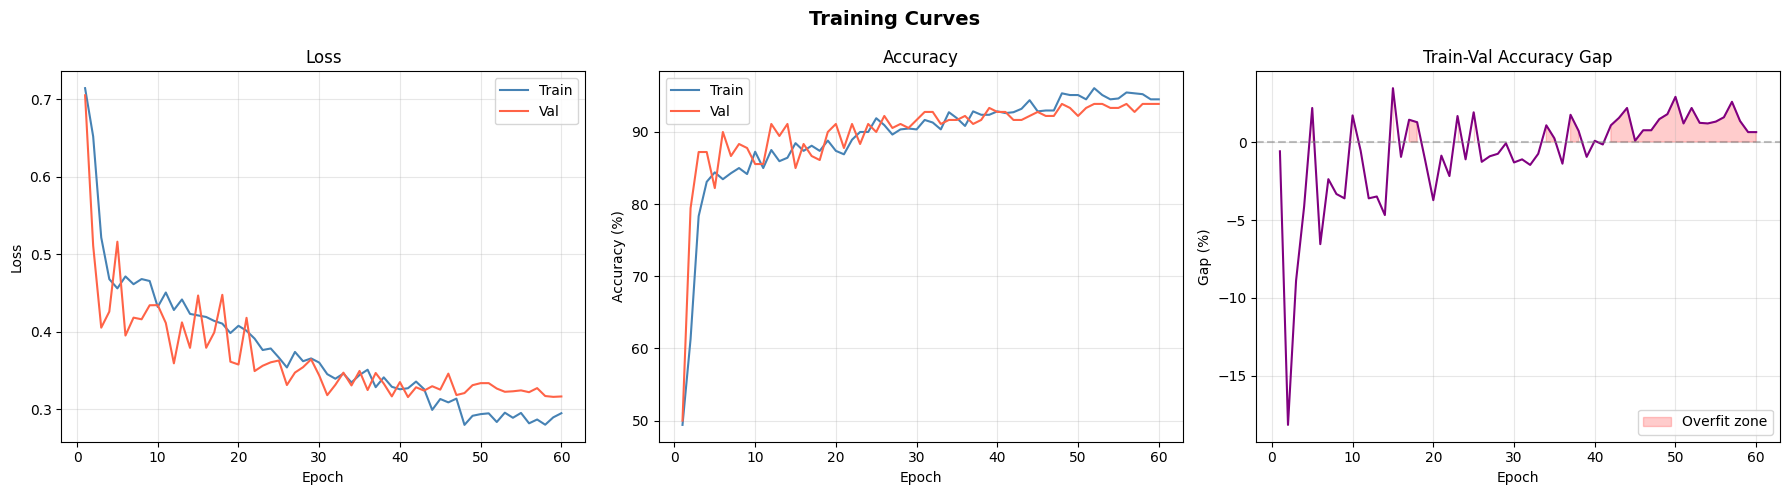

  Saved → /content/drive/MyDrive/crime_detection/plots/training_curves.png

 FINAL TEST RESULTS (Best Model)

  ── Without TTA ──
   HOCKEY  Acc=91.39%  P=89.9%  R=93.4%  F1=91.6%  (TP=71 TN=67 FP=8 FN=5)
   MOVIE  Acc=96.88%  P=100.0%  R=93.7%  F1=96.8%  (TP=15 TN=16 FP=0 FN=1)

  ── With TTA×5 ──
   HOCKEY  Acc=88.74%  P=86.4%  R=92.1%  F1=89.2%  (TP=70 TN=64 FP=11 FN=6)
   MOVIE  Acc=96.88%  P=100.0%  R=93.7%  F1=96.8%  (TP=15 TN=16 FP=0 FN=1)

 PLOTTING CONFUSION MATRICES


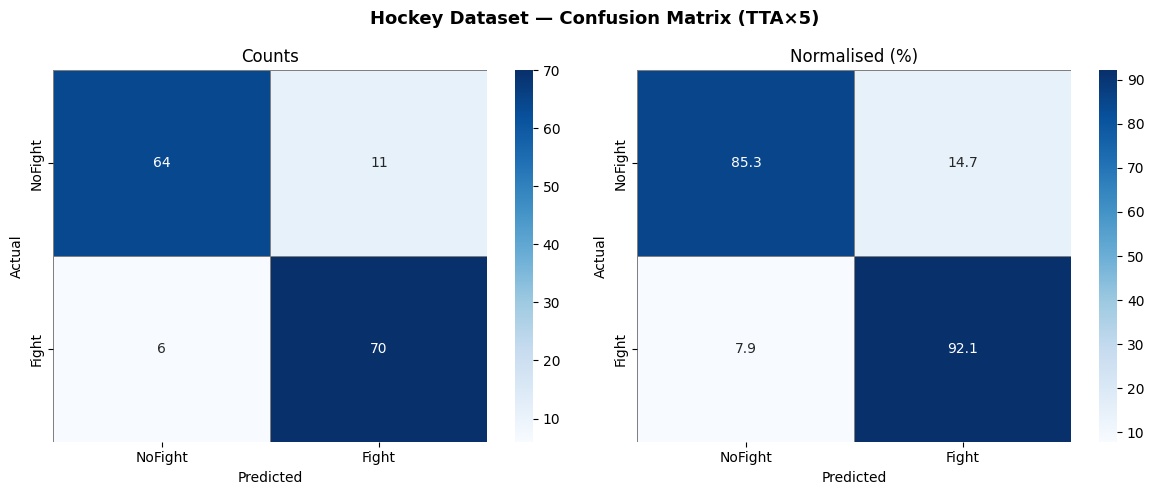

  Saved → /content/drive/MyDrive/crime_detection/plots/confusion_hockey_tta.png


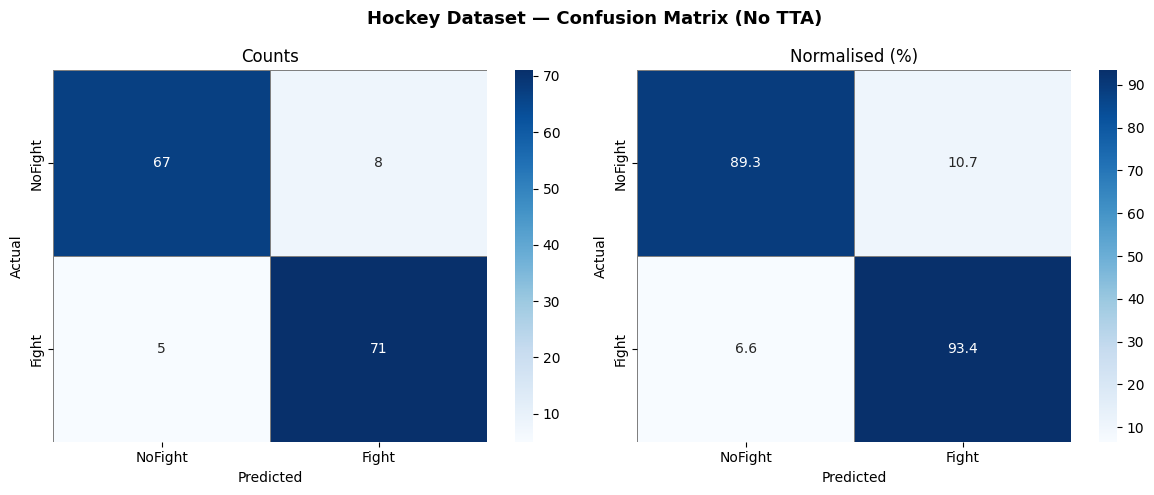

  Saved → /content/drive/MyDrive/crime_detection/plots/confusion_hockey_no_tta.png


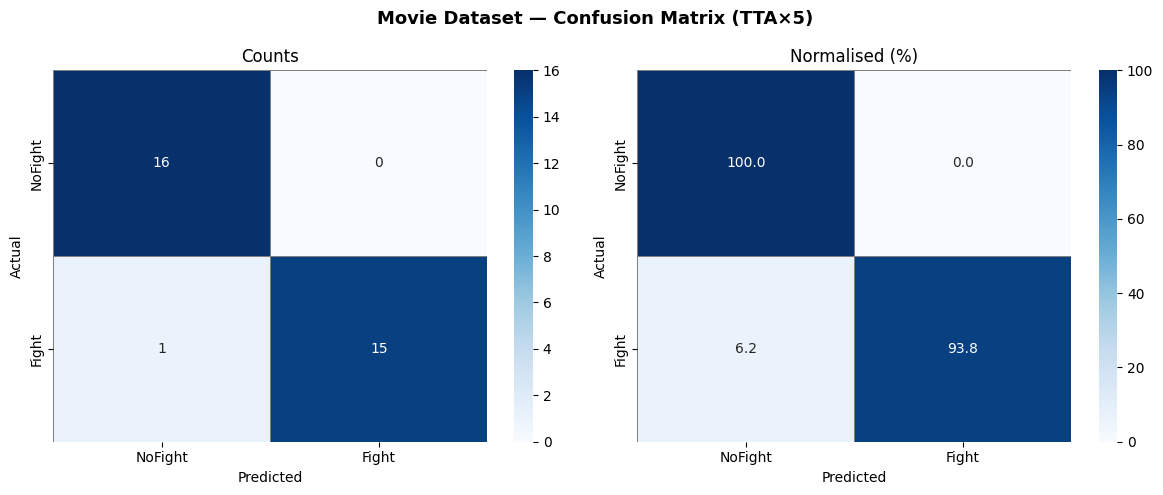

  Saved → /content/drive/MyDrive/crime_detection/plots/confusion_movie_tta.png


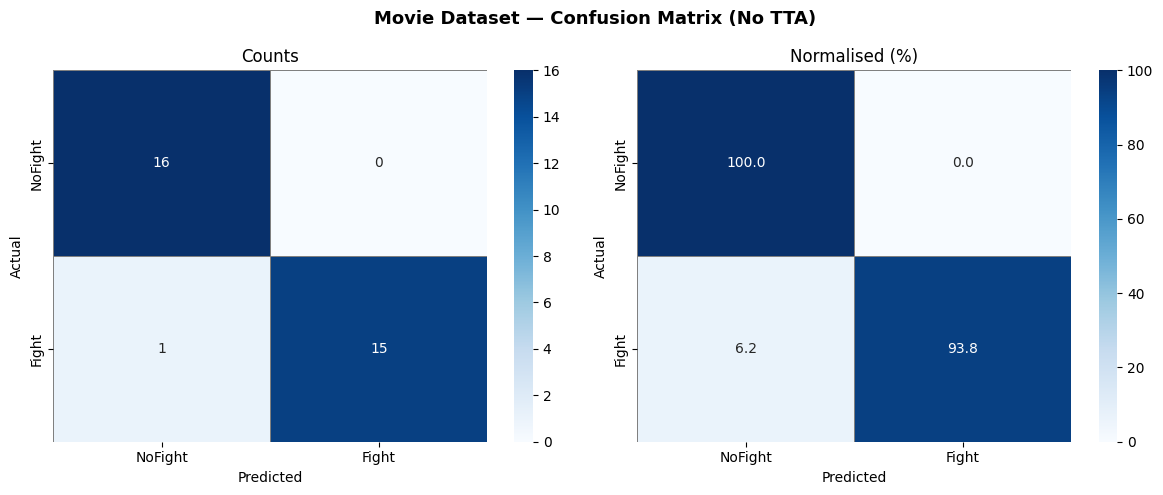

  Saved → /content/drive/MyDrive/crime_detection/plots/confusion_movie_no_tta.png

 PLOTTING METRICS COMPARISON


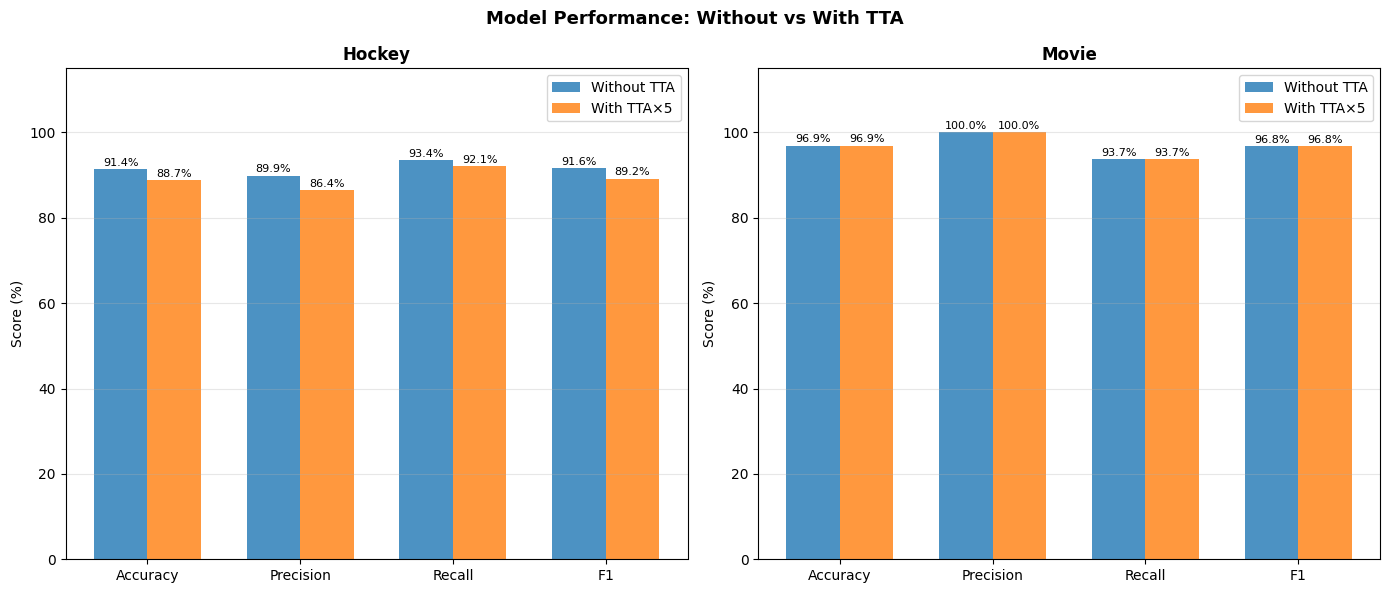

  Saved → /content/drive/MyDrive/crime_detection/plots/metrics_comparison.png

 PLOTTING PER-CLASS ACCURACY


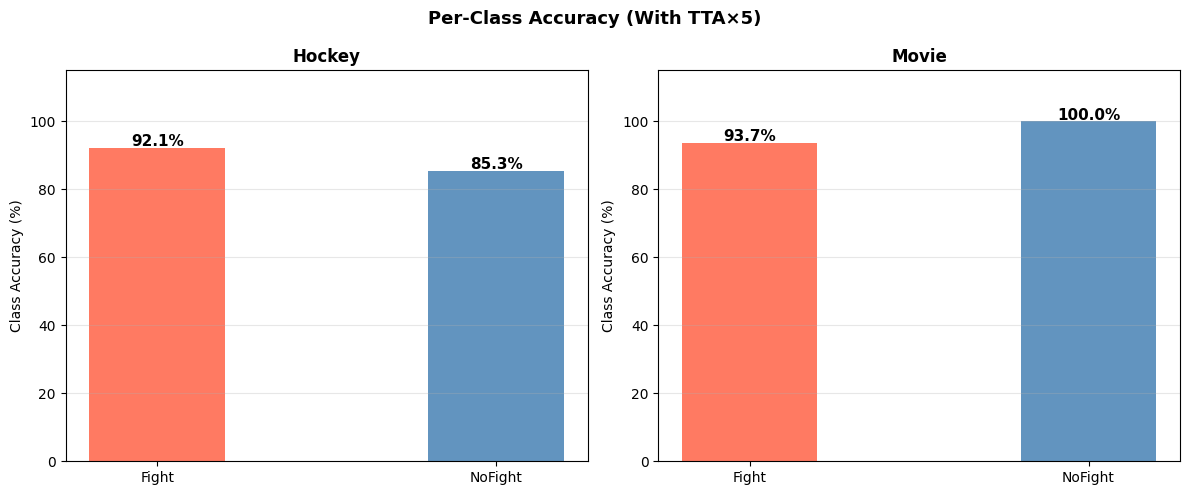

  Saved → /content/drive/MyDrive/crime_detection/plots/per_class_accuracy.png

 ALL FILES SAVED TO DRIVE
  Model    : /content/drive/MyDrive/crime_detection/models/best_v3_transformer.pth
  History  : /content/drive/MyDrive/crime_detection/logs/history_v3.json
  Plots    : /content/drive/MyDrive/crime_detection/plots/
    ├── training_curves.png
    ├── confusion_hockey_tta.png
    ├── confusion_hockey_no_tta.png
    ├── confusion_movie_tta.png
    ├── confusion_movie_no_tta.png
    ├── metrics_comparison.png
    └── per_class_accuracy.png


Cell 8 complete


In [ ]:
# CELL 8 — Enhanced Model: Velocity Features + Transformer Head + TTA
# + Confusion Matrix, Training Curves, Graphs

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, time, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
import seaborn as sns

WORK_DIR   = '/content/drive/MyDrive/crime_detection'
SPLITS_DIR = f'{WORK_DIR}/data/splits'
MODELS_DIR = f'{WORK_DIR}/models'
LOGS_DIR   = f'{WORK_DIR}/logs'
PLOTS_DIR  = f'{WORK_DIR}/plots'      # ← new: all plots saved here
os.makedirs(PLOTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ══════════════════════════════════════════════════════════════════════════════
# FEATURES
# ══════════════════════════════════════════════════════════════════════════════
COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

def impute_zeros(skeleton):
    T = skeleton.shape[0]
    valid     = ~np.all(skeleton == 0, axis=(1, 2))
    valid_idx = np.where(valid)[0]
    if len(valid_idx) == 0:
        return skeleton
    for t in range(T):
        if not valid[t]:
            left  = valid_idx[valid_idx < t]
            right = valid_idx[valid_idx > t]
            if len(left) > 0 and len(right) > 0:
                lt, rt = left[-1], right[0]
                a = (t - lt) / (rt - lt)
                skeleton[t] = (1-a)*skeleton[lt] + a*skeleton[rt]
            elif len(left)  > 0: skeleton[t] = skeleton[left[-1]]
            elif len(right) > 0: skeleton[t] = skeleton[right[0]]
    return skeleton

def compute_features(skeleton):
    T, V, _ = skeleton.shape
    vel = np.zeros((T, V, 2), dtype=np.float32)
    vel[1:] = skeleton[1:,:,:2] - skeleton[:-1,:,:2]
    vel = np.clip(vel * 10.0, -1.0, 1.0)
    bone   = np.zeros((T, V, 2), dtype=np.float32)
    degree = np.zeros(V, dtype=np.float32)
    for (i,j) in COCO_EDGES:
        bone[:,i,:] += skeleton[:,j,:2] - skeleton[:,i,:2]
        bone[:,j,:] += skeleton[:,i,:2] - skeleton[:,j,:2]
        degree[i] += 1; degree[j] += 1
    for v in range(V):
        if degree[v] > 0: bone[:,v,:] /= degree[v]
    return np.concatenate([skeleton, vel, bone], axis=-1).astype(np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════
class EnhancedSkeletonDataset(Dataset):
    def __init__(self, split_file, augment=False):
        self.augment = augment
        self.samples = []
        with open(split_file) as f:
            for line in f:
                line = line.strip()
                if not line: continue
                *parts, label_str = line.rsplit(maxsplit=1)
                self.samples.append((' '.join(parts), int(label_str)))
        print(f"  Loaded {len(self.samples)} samples  "
              f"({'train+aug' if augment else 'eval'})"
              f"  ← {os.path.basename(split_file)}")

    def __len__(self): return len(self.samples)

    def _augment(self, sk):
        if np.random.rand() < 0.5:
            sk = sk.copy()
            sk[:,:,0] = 1.0 - sk[:,:,0]
            for a,b in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                sk[:,[a,b],:] = sk[:,[b,a],:]
        if np.random.rand() < 0.5:
            sk = np.roll(sk, np.random.randint(-3,4), axis=0)
        if np.random.rand() < 0.5:
            noise = np.random.normal(0, 0.012, sk[:,:,:2].shape).astype(np.float32)
            sk = sk.copy(); sk[:,:,:2] = np.clip(sk[:,:,:2]+noise,0,1)
        if np.random.rand() < 0.4:
            scale = np.random.uniform(0.85,1.15)
            cx,cy = sk[:,:,0].mean(), sk[:,:,1].mean()
            sk = sk.copy()
            sk[:,:,0] = np.clip((sk[:,:,0]-cx)*scale+cx,0,1)
            sk[:,:,1] = np.clip((sk[:,:,1]-cy)*scale+cy,0,1)
        if np.random.rand() < 0.3:
            drop = np.random.choice(17, size=np.random.randint(1,4), replace=False)
            sk = sk.copy(); sk[:,drop,2] = 0.0
        return sk

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        sk   = np.load(path).astype(np.float32)
        sk   = impute_zeros(sk)
        if self.augment: sk = self._augment(sk)
        feat = compute_features(sk)
        return torch.from_numpy(feat), torch.tensor(label, dtype=torch.long)

# ══════════════════════════════════════════════════════════════════════════════
# MODEL
# ══════════════════════════════════════════════════════════════════════════════
NUM_NODES = 17

def build_adj(num_nodes=NUM_NODES, edges=COCO_EDGES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i,j in edges: A[i,j] = A[j,i] = 1
    A += np.eye(num_nodes, dtype=np.float32)
    D = np.diag(A.sum(1)**-0.5)
    return (D @ A @ D).astype(np.float32)

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_c, out_c)
        self.bn = nn.BatchNorm1d(out_c)
    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0),-1,-1), x)
        x = self.fc(x)
        B,V,C = x.shape
        return self.bn(x.view(B*V,C)).view(B,V,C)

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, tk=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad = (tk-1)//2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, (tk,1), stride=(stride,1), padding=(pad,0)),
            nn.BatchNorm2d(out_c), nn.ReLU(), nn.Dropout(dropout))
        self.res = (nn.Sequential(
                        nn.Conv2d(in_c, out_c, 1, stride=(stride,1)),
                        nn.BatchNorm2d(out_c))
                    if in_c!=out_c or stride!=1 else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        B,C,T,V = x.shape
        xf = x.permute(0,2,3,1).reshape(B*T,V,C)
        xg = self.gcn(xf)
        oc = xg.shape[-1]
        xg = xg.reshape(B,T,V,oc).permute(0,3,1,2)
        return self.relu(self.tcn(xg)+self.res(x))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()*(-np.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:,:x.size(1)])

class STGCNTransformer(nn.Module):
    def __init__(self, in_channels=7, num_classes=2, A=None, dropout=0.4):
        super().__init__()
        if A is None: A = build_adj()
        self.data_bn = nn.BatchNorm1d(in_channels*NUM_NODES)
        cfg = [(in_channels,64),(64,64),(64,64),
               (64,128),(128,128),(128,128),(128,256),(256,256)]
        self.backbone = nn.ModuleList()
        for i,(inc,outc) in enumerate(cfg):
            stride = 2 if i in [3,6] else 1
            self.backbone.append(STGCNBlock(inc,outc,A,stride=stride,dropout=dropout*0.5))
        self.spatial_pool = nn.AdaptiveAvgPool2d((None,1))
        d_model = 256
        self.proj    = nn.Linear(256, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout*0.5)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=dropout*0.5, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model), nn.Dropout(dropout),
            nn.Linear(d_model,128), nn.GELU(),
            nn.Dropout(dropout*0.5), nn.Linear(128, num_classes))

    def forward(self, x):
        B,T,V,C = x.shape
        xbn = x.permute(0,2,3,1).reshape(B,V*C,T)
        xbn = self.data_bn(xbn.reshape(B*V,C,T).reshape(B,V*C,T))
        xbn = xbn.reshape(B,V,C,T).permute(0,2,3,1)
        out = xbn
        for layer in self.backbone: out = layer(out)
        out = self.spatial_pool(out).squeeze(-1).permute(0,2,1)
        out = self.pos_enc(self.proj(out))
        out = self.transformer(out).mean(dim=1)
        return self.classifier(out)

# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def evaluate(loader, model, criterion, device):
    model.eval()
    total_loss = tp = tn = fp = fn = total = 0
    all_preds = []; all_labels = []
    with torch.no_grad():
        for x,y in loader:
            x,y   = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits,y).item()*x.size(0)
            preds = logits.argmax(1)
            tp += ((preds==1)&(y==1)).sum().item()
            tn += ((preds==0)&(y==0)).sum().item()
            fp += ((preds==1)&(y==0)).sum().item()
            fn += ((preds==0)&(y==1)).sum().item()
            total += x.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    acc  = (tp+tn)/total*100
    prec = tp/(tp+fp+1e-8)*100
    rec  = tp/(tp+fn+1e-8)*100
    f1   = 2*prec*rec/(prec+rec+1e-8)
    return {'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,
            'tp':tp,'tn':tn,'fp':fp,'fn':fn,'loss':total_loss/total,
            'preds':all_preds,'labels':all_labels}

def evaluate_with_tta(loader, model, criterion, device, n_tta=5):
    model.eval()
    all_probs=[]; all_labels=[]; total_loss=0.0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device),y.to(device)
            B   = x.size(0)
            prob_sum = torch.zeros(B,2,device=device)
            logits   = model(x)
            prob_sum += F.softmax(logits,dim=1)
            total_loss += criterion(logits,y).item()*B
            for _ in range(n_tta-1):
                x_aug = x.clone()
                flip_mask = torch.rand(B)<0.5
                if flip_mask.any():
                    x_aug[flip_mask,:,:,0] = 1.0-x_aug[flip_mask,:,:,0]
                    for a,b in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                        tmp = x_aug[flip_mask,:,a,:].clone()
                        x_aug[flip_mask,:,a,:] = x_aug[flip_mask,:,b,:]
                        x_aug[flip_mask,:,b,:] = tmp
                noise = torch.randn_like(x_aug[:,:,:,:2])*0.008
                x_aug[:,:,:,:2] = (x_aug[:,:,:,:2]+noise).clamp(0,1)
                prob_sum += F.softmax(model(x_aug),dim=1)
            all_probs.append((prob_sum/n_tta).cpu())
            all_labels.append(y.cpu())
    all_probs  = torch.cat(all_probs,dim=0)
    all_labels = torch.cat(all_labels,dim=0)
    preds      = all_probs.argmax(dim=1)
    total   = len(all_labels)
    tp = ((preds==1)&(all_labels==1)).sum().item()
    tn = ((preds==0)&(all_labels==0)).sum().item()
    fp = ((preds==1)&(all_labels==0)).sum().item()
    fn = ((preds==0)&(all_labels==1)).sum().item()
    prec = tp/(tp+fp+1e-8)*100
    rec  = tp/(tp+fn+1e-8)*100
    f1   = 2*prec*rec/(prec+rec+1e-8)
    return {'accuracy':(tp+tn)/total*100,'precision':prec,'recall':rec,'f1':f1,
            'tp':tp,'tn':tn,'fp':fp,'fn':fn,'loss':total_loss/total,
            'preds':preds.tolist(),'labels':all_labels.tolist()}

# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def plot_training_curves(history, save_path):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training Curves', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Val',   color='tomato')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Gap (overfitting indicator)
    gap = [t-v for t,v in zip(history['train_acc'], history['val_acc'])]
    axes[2].plot(epochs, gap, color='purple')
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[2].fill_between(epochs, gap, 0,
                         where=[g>0 for g in gap], alpha=0.2, color='red',
                         label='Overfit zone')
    axes[2].set_title('Train-Val Accuracy Gap')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap (%)')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {save_path}")


def plot_confusion_matrix(preds, labels, title, save_path):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, data, fmt, subtitle in [
        (axes[0], cm,      'd',    'Counts'),
        (axes[1], cm_norm, '.1f',  'Normalised (%)')
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=['NoFight','Fight'],
                    yticklabels=['NoFight','Fight'],
                    linewidths=0.5, linecolor='gray')
        ax.set_title(subtitle)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {save_path}")


def plot_metrics_comparison(results_dict, save_path):
    """Bar chart comparing metrics across Hockey/Movie, with/without TTA."""
    datasets = list(results_dict.keys())
    metrics  = ['accuracy','precision','recall','f1']
    labels   = ['Accuracy','Precision','Recall','F1']
    x        = np.arange(len(metrics))
    width    = 0.35
    colors   = ['steelblue','tomato','seagreen','darkorange']

    fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 6))
    if len(datasets)==1: axes = [axes]

    for ax, (ds_name, (no_tta, with_tta)) in zip(axes, results_dict.items()):
        vals_no  = [no_tta[m]  for m in metrics]
        vals_tta = [with_tta[m] for m in metrics]
        bars1 = ax.bar(x-width/2, vals_no,  width, label='Without TTA', alpha=0.8)
        bars2 = ax.bar(x+width/2, vals_tta, width, label='With TTA×5',  alpha=0.8)
        for bar in bars1+bars2:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8)
        ax.set_title(ds_name, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(labels)
        ax.set_ylim(0, 115)
        ax.set_ylabel('Score (%)')
        ax.legend(); ax.grid(True, alpha=0.3, axis='y')

    fig.suptitle('Model Performance: Without vs With TTA', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {save_path}")


def plot_per_class_accuracy(results_dict, save_path):
    """Shows Fight vs NoFight accuracy per dataset."""
    datasets = list(results_dict.keys())
    fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 5))
    if len(datasets)==1: axes = [axes]

    for ax, (ds_name, m) in zip(axes, results_dict.items()):
        tp,tn,fp,fn = m['tp'],m['tn'],m['fp'],m['fn']
        fight_acc   = tp/(tp+fn+1e-8)*100
        nofight_acc = tn/(tn+fp+1e-8)*100
        bars = ax.bar(['Fight','NoFight'], [fight_acc, nofight_acc],
                      color=['tomato','steelblue'], alpha=0.85, width=0.4)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}%',
                    ha='center', fontsize=11, fontweight='bold')
        ax.set_title(ds_name, fontweight='bold')
        ax.set_ylabel('Class Accuracy (%)'); ax.set_ylim(0,115)
        ax.grid(True, alpha=0.3, axis='y')

    fig.suptitle('Per-Class Accuracy (With TTA×5)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# VERIFY SETUP
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("🔍 VERIFYING ENHANCED SETUP")
print("=" * 60)

A = build_adj()

# ← FIXED: was /data/skeletons, now /skeletons
sample_dir  = f'{WORK_DIR}/skeletons/hockey/fight'
sample_file = sorted(os.listdir(sample_dir))[0]
raw  = np.load(os.path.join(sample_dir, sample_file)).astype(np.float32)
raw  = impute_zeros(raw)
feat = compute_features(raw)
print(f"\n  Raw skeleton shape : {raw.shape}   ← (T, V, 3)")
print(f"  Enhanced feat shape: {feat.shape}  ← (T, V, 7)  [x,y,conf,vx,vy,bx,by]")
print(f"  Velocity range     : [{feat[:,:,3:5].min():.3f}, {feat[:,:,3:5].max():.3f}]")
print(f"  Bone range         : [{feat[:,:,5:7].min():.3f}, {feat[:,:,5:7].max():.3f}]")

model_v3 = STGCNTransformer(in_channels=7, num_classes=2, A=A, dropout=0.4).to(DEVICE)
total_p  = sum(p.numel() for p in model_v3.parameters())
print(f"\n  Model params       : {total_p:,}")

dummy = torch.from_numpy(feat).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    out = model_v3(dummy)
print(f"  Forward pass in    : {dummy.shape}")
print(f"  Forward pass out   : {out.shape}  ← (B, 2) logits")

# ══════════════════════════════════════════════════════════════════════════════
# DATASETS + LOADERS
# ══════════════════════════════════════════════════════════════════════════════
BATCH_SIZE   = 32
NUM_EPOCHS   = 60
LR           = 5e-4
WEIGHT_DECAY = 5e-4
NUM_WORKERS  = 4

print("\n" + "=" * 60)
print("Loading enhanced datasets...")
train_ds3  = EnhancedSkeletonDataset(f'{SPLITS_DIR}/combined_train.txt', augment=True)
val_ds3    = EnhancedSkeletonDataset(f'{SPLITS_DIR}/combined_val.txt',   augment=False)
h_test_ds3 = EnhancedSkeletonDataset(f'{SPLITS_DIR}/hockey_test.txt',   augment=False)
m_test_ds3 = EnhancedSkeletonDataset(f'{SPLITS_DIR}/movie_test.txt',    augment=False)

train_loader3  = DataLoader(train_ds3,  batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True)
val_loader3    = DataLoader(val_ds3,    batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
h_test_loader3 = DataLoader(h_test_ds3, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
m_test_loader3 = DataLoader(m_test_ds3, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(train_loader3))
print(f"\n  Train batch x : {xb.shape}  ← (B, T, V, 7)")
print(f"  Train batch y : {yb.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING
# ══════════════════════════════════════════════════════════════════════════════
optimizer3 = torch.optim.AdamW(model_v3.parameters(),
                                lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < 10: return epoch/10
    progress = (epoch-10)/(NUM_EPOCHS-10)
    return 0.5*(1+np.cos(np.pi*progress))

scheduler3 = torch.optim.lr_scheduler.LambdaLR(optimizer3, lr_lambda)
criterion3 = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val3  = 0.0
best_ep3   = 0
best_path3 = f'{MODELS_DIR}/best_v3_transformer.pth'
history3   = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}

print("\n" + "=" * 60)
print(" TRAINING: ST-GCN + Transformer")
print(f"   Features  : x,y,conf + velocity + bone vectors (7ch)")
print(f"   Augment   : flip+jitter+noise+scale+dropout")
print(f"   Regularize: dropout=0.4, wd={WEIGHT_DECAY}")
print("=" * 60)
print(f"\n{'Ep':>4} | {'TrLoss':>7} | {'TrAcc':>6} | {'VaLoss':>7} | {'VaAcc':>6} | {'LR':>8}")
print("-" * 58)

t0 = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    model_v3.train()
    ep_loss = ep_correct = ep_total = 0

    for x,y in train_loader3:
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer3.zero_grad()
        logits = model_v3(x)
        loss   = criterion3(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_v3.parameters(), 1.0)
        optimizer3.step()
        ep_loss    += loss.item()*x.size(0)
        ep_correct += (logits.argmax(1)==y).sum().item()
        ep_total   += x.size(0)

    scheduler3.step()
    tr_loss = ep_loss/ep_total
    tr_acc  = ep_correct/ep_total*100
    cur_lr  = optimizer3.param_groups[0]['lr']
    val_m   = evaluate(val_loader3, model_v3, criterion3, DEVICE)

    if val_m['accuracy'] > best_val3:
        best_val3 = val_m['accuracy']
        best_ep3  = epoch
        torch.save({'epoch':epoch,
                    'model_state_dict': model_v3.state_dict(),
                    'val_acc': best_val3}, best_path3)
        flag = " (Best Model)"
    else:
        flag = ""

    history3['train_loss'].append(tr_loss)
    history3['train_acc'].append(tr_acc)
    history3['val_loss'].append(val_m['loss'])
    history3['val_acc'].append(val_m['accuracy'])

    if epoch%10==0 or flag:
        print(f"{epoch:>4} | {tr_loss:>7.4f} | {tr_acc:>5.1f}% | "
              f"{val_m['loss']:>7.4f} | {val_m['accuracy']:>5.1f}%{flag} | {cur_lr:.2e}")

elapsed = time.time()-t0
print(f"\n  Training time : {elapsed/60:.1f} min")
print(f"  Best val acc  : {best_val3:.2f}%  (epoch {best_ep3})")

# Save history
with open(f'{LOGS_DIR}/history_v3.json','w') as f:
    json.dump(history3, f, indent=2)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(" PLOTTING TRAINING CURVES")
print("=" * 60)
plot_training_curves(history3, f'{PLOTS_DIR}/training_curves.png')

# ══════════════════════════════════════════════════════════════════════════════
# FINAL TEST EVALUATION WITH TTA
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(" FINAL TEST RESULTS (Best Model)")
print("=" * 60)

ckpt = torch.load(best_path3)
model_v3.load_state_dict(ckpt['model_state_dict'])

# Evaluate both datasets with and without TTA
results_no_tta  = {}
results_with_tta= {}

print("\n  ── Without TTA ──")
for name, loader, key in [(" HOCKEY", h_test_loader3, "Hockey"),
                           (" MOVIE",  m_test_loader3, "Movie")]:
    m = evaluate(loader, model_v3, criterion3, DEVICE)
    results_no_tta[key] = m
    print(f"  {name}  Acc={m['accuracy']:.2f}%  "
          f"P={m['precision']:.1f}%  R={m['recall']:.1f}%  F1={m['f1']:.1f}%"
          f"  (TP={m['tp']} TN={m['tn']} FP={m['fp']} FN={m['fn']})")

print("\n  ── With TTA×5 ──")
for name, loader, key in [(" HOCKEY", h_test_loader3, "Hockey"),
                           (" MOVIE",  m_test_loader3, "Movie")]:
    m = evaluate_with_tta(loader, model_v3, criterion3, DEVICE, n_tta=5)
    results_with_tta[key] = m
    print(f"  {name}  Acc={m['accuracy']:.2f}%  "
          f"P={m['precision']:.1f}%  R={m['recall']:.1f}%  F1={m['f1']:.1f}%"
          f"  (TP={m['tp']} TN={m['tn']} FP={m['fp']} FN={m['fn']})")

# ══════════════════════════════════════════════════════════════════════════════
# CONFUSION MATRICES
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(" PLOTTING CONFUSION MATRICES")
print("=" * 60)

for key in ['Hockey', 'Movie']:
    m = results_with_tta[key]
    plot_confusion_matrix(
        m['preds'], m['labels'],
        title=f'{key} Dataset — Confusion Matrix (TTA×5)',
        save_path=f'{PLOTS_DIR}/confusion_{key.lower()}_tta.png'
    )
    m = results_no_tta[key]
    plot_confusion_matrix(
        m['preds'], m['labels'],
        title=f'{key} Dataset — Confusion Matrix (No TTA)',
        save_path=f'{PLOTS_DIR}/confusion_{key.lower()}_no_tta.png'
    )

# ══════════════════════════════════════════════════════════════════════════════
# METRICS COMPARISON CHART
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(" PLOTTING METRICS COMPARISON")
print("=" * 60)

comparison = {k: (results_no_tta[k], results_with_tta[k]) for k in ['Hockey','Movie']}
plot_metrics_comparison(comparison, f'{PLOTS_DIR}/metrics_comparison.png')

# ══════════════════════════════════════════════════════════════════════════════
# PER-CLASS ACCURACY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(" PLOTTING PER-CLASS ACCURACY")
print("=" * 60)

plot_per_class_accuracy(results_with_tta, f'{PLOTS_DIR}/per_class_accuracy.png')

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(" ALL FILES SAVED TO DRIVE")
print("=" * 60)
print(f"  Model    : {best_path3}")
print(f"  History  : {LOGS_DIR}/history_v3.json")
print(f"  Plots    : {PLOTS_DIR}/")
print(f"    ├── training_curves.png")
print(f"    ├── confusion_hockey_tta.png")
print(f"    ├── confusion_hockey_no_tta.png")
print(f"    ├── confusion_movie_tta.png")
print(f"    ├── confusion_movie_no_tta.png")
print(f"    ├── metrics_comparison.png")
print(f"    └── per_class_accuracy.png")

print("\n" + "=" * 60)

print("\nCell 8 complete")

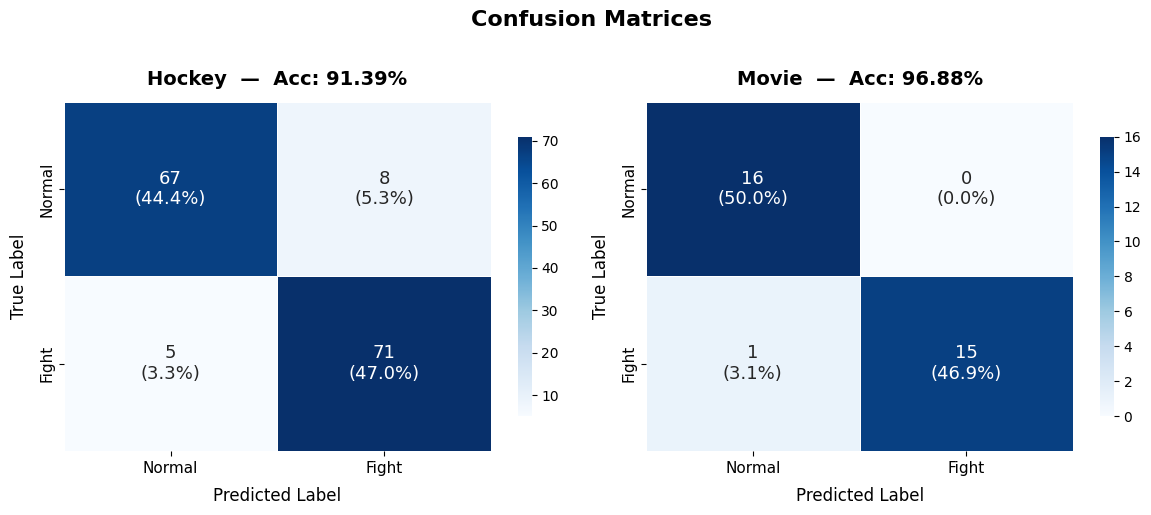

Saved → /content/drive/MyDrive/crime_detection/plots/confusion_matrices_no_tta.png


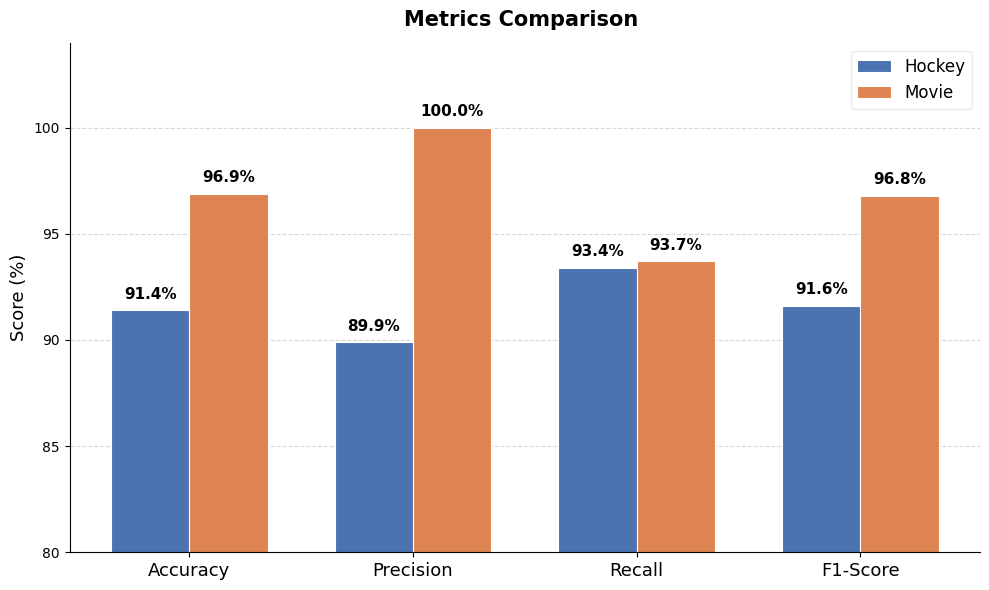

Saved → /content/drive/MyDrive/crime_detection/plots/metrics_comparison_no_tta.png


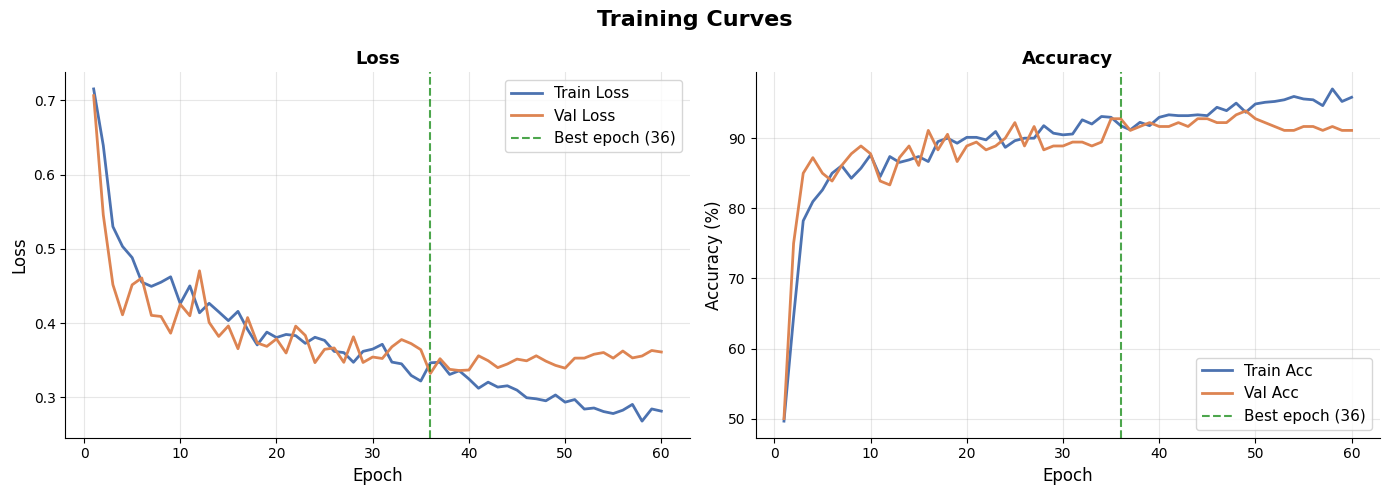

Saved → /content/drive/MyDrive/crime_detection/plots/training_curves_no_tta.png


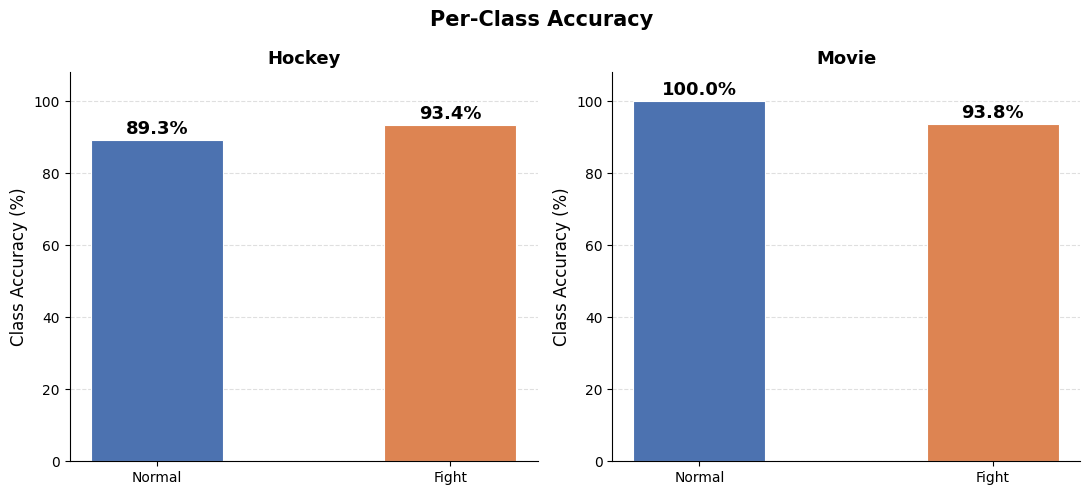

Saved → /content/drive/MyDrive/crime_detection/plots/per_class_accuracy_no_tta.png

✅ All plots saved to: /content/drive/MyDrive/crime_detection/plots/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─────────────────────────────────────────────
# 1.  HARD-CODED RESULTS  (No TTA)
# ─────────────────────────────────────────────
results = {
    "Hockey": {
        "acc": 91.39, "precision": 89.9, "recall": 93.4, "f1": 91.6,
        "TP": 71, "TN": 67, "FP": 8, "FN": 5,
        "classes": ["Normal", "Fight"]
    },
    "Movie": {
        "acc": 96.88, "precision": 100.0, "recall": 93.7, "f1": 96.8,
        "TP": 15, "TN": 16, "FP": 0, "FN": 1,
        "classes": ["Normal", "Fight"]
    },
}

SAVE_DIR = "/content/drive/MyDrive/crime_detection/plots/"  # change if needed
import os; os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ─────────────────────────────────────────────
# 2.  CONFUSION MATRICES
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices ", fontsize=16, fontweight="bold", y=1.02)

for ax, (dataset, r) in zip(axes, results.items()):
    cm = np.array([[r["TN"], r["FP"]],
                   [r["FN"], r["TP"]]])

    # Percentage annotations
    total = cm.sum()
    annot = np.array([[f"{v}\n({v/total*100:.1f}%)" for v in row] for row in cm])

    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=r["classes"], yticklabels=r["classes"],
                linewidths=0.5, linecolor="white",
                cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 13})

    ax.set_title(f"{dataset}  —  Acc: {r['acc']:.2f}%", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=8)
    ax.set_ylabel("True Label",      fontsize=12, labelpad=8)
    ax.tick_params(labelsize=11)

plt.tight_layout()
path = SAVE_DIR + "confusion_matrices_no_tta.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")


# ─────────────────────────────────────────────
# 3.  METRICS BAR CHART
# ─────────────────────────────────────────────
metrics      = ["Accuracy", "Precision", "Recall", "F1-Score"]
hockey_vals  = [results["Hockey"]["acc"],  results["Hockey"]["precision"],
                results["Hockey"]["recall"], results["Hockey"]["f1"]]
movie_vals   = [results["Movie"]["acc"],   results["Movie"]["precision"],
                results["Movie"]["recall"],  results["Movie"]["f1"]]

x      = np.arange(len(metrics))
width  = 0.35
colors = ["#4C72B0", "#DD8452"]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, hockey_vals, width, label="Hockey", color=colors[0],
               edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x + width/2, movie_vals,  width, label="Movie",  color=colors[1],
               edgecolor="white", linewidth=0.8)

# Value labels on bars
for bar in (*bars1, *bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_ylim(80, 104)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13)
ax.set_ylabel("Score (%)", fontsize=13)
ax.set_title("Metrics Comparison ", fontsize=15, fontweight="bold", pad=12)
ax.legend(fontsize=12, framealpha=0.4)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
path = SAVE_DIR + "metrics_comparison_no_tta.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")


# ─────────────────────────────────────────────
# 4.  TRAINING CURVES  (load from saved history)
# ─────────────────────────────────────────────
import json

history_path = "/content/drive/MyDrive/crime_detection/logs/history_v3.json"

try:
    with open(history_path) as f:
        history = json.load(f)

    epochs    = range(1, len(history["train_loss"]) + 1)
    train_loss = history["train_loss"]
    val_loss   = history["val_loss"]
    train_acc  = history["train_acc"]
    val_acc    = history["val_acc"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves", fontsize=16, fontweight="bold")

    # — Loss —
    ax1.plot(epochs, train_loss, label="Train Loss", color="#4C72B0", lw=2)
    ax1.plot(epochs, val_loss,   label="Val Loss",   color="#DD8452", lw=2)
    best_ep = int(np.argmin(val_loss)) + 1
    ax1.axvline(best_ep, color="green", linestyle="--", alpha=0.7,
                label=f"Best epoch ({best_ep})")
    ax1.set_xlabel("Epoch", fontsize=12); ax1.set_ylabel("Loss",  fontsize=12)
    ax1.set_title("Loss",     fontsize=13, fontweight="bold")
    ax1.legend(fontsize=11); ax1.grid(alpha=0.3)

    # — Accuracy —
    ax2.plot(epochs, train_acc, label="Train Acc", color="#4C72B0", lw=2)
    ax2.plot(epochs, val_acc,   label="Val Acc",   color="#DD8452", lw=2)
    ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.7,
                label=f"Best epoch ({best_ep})")
    ax2.set_xlabel("Epoch", fontsize=12); ax2.set_ylabel("Accuracy (%)", fontsize=12)
    ax2.set_title("Accuracy", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=11); ax2.grid(alpha=0.3)

    plt.tight_layout()
    path = SAVE_DIR + "training_curves_no_tta.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")

except FileNotFoundError:
    print("⚠  history_v3.json not found — skipping training curves.")


# ─────────────────────────────────────────────
# 5.  PER-CLASS ACCURACY  (Fight vs Normal)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Per-Class Accuracy ", fontsize=15, fontweight="bold")

for ax, (dataset, r) in zip(axes, results.items()):
    fight_acc  = r["TP"] / (r["TP"] + r["FN"]) * 100   # recall for Fight
    normal_acc = r["TN"] / (r["TN"] + r["FP"]) * 100   # recall for Normal

    bars = ax.bar(["Normal", "Fight"], [normal_acc, fight_acc],
                  color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8,
                  width=0.45)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", va="bottom",
                fontsize=13, fontweight="bold")

    ax.set_ylim(0, 108)
    ax.set_title(f"{dataset}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Class Accuracy (%)", fontsize=12)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
path = SAVE_DIR + "per_class_accuracy_no_tta.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

print("\n✅ All plots saved to:", SAVE_DIR)

In [ ]:
# TELEGRAM CELL — Real-time violence detection + Telegram alerts
# Feed any video → detects violence → sends you notification with frame + timestamp

import cv2
import torch
import torch.nn.functional as F
import numpy as np
import requests
import os
import time
import itertools
import tempfile
from datetime import datetime
from ultralytics import YOLO
from IPython.display import display, Image as IPImage

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — Fill these in
# ══════════════════════════════════════════════════════════════════════════════
TELEGRAM_TOKEN   = "8030163352:AAETO4o1GLe-h2ukZ6ZD3YuCPuToMyST3gM"       # from BotFather
TELEGRAM_CHAT_ID = "5691525703"         # from getUpdates

# Video to analyze — change this to any video path
VIDEO_PATH = "/content/drive/MyDrive/crime_detection/test_video.avi"

WORK_DIR   = '/content/violence_detection'
MODEL_PATH = '/content/drive/MyDrive/crime_detection/models/best_v3_transformer.pth'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Detection settings
FRAMES_BUFFER    = 30        # frames fed to ST-GCN (must match training)
VIOLENCE_THRESH  = 0.65      # probability threshold to trigger alert
COOLDOWN_SECONDS = 10        # min seconds between alerts for same video
SKIP_FRAMES      = 2         # process every Nth frame (2=faster, 1=most accurate)
SAVE_ANNOTATED   = True      # save annotated video to Drive

# ══════════════════════════════════════════════════════════════════════════════
# TELEGRAM FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def send_telegram_message(text):
    """Send a text message via Telegram."""
    url  = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage"
    data = {"chat_id": TELEGRAM_CHAT_ID,
            "text": text, "parse_mode": "Markdown"}
    try:
        r = requests.post(url, data=data, timeout=10)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️  Telegram message failed: {e}")
        return False

def send_telegram_photo(image_path, caption=""):
    """Send a photo with caption via Telegram."""
    url  = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto"
    data = {"chat_id": TELEGRAM_CHAT_ID,
            "caption": caption, "parse_mode": "Markdown"}
    try:
        with open(image_path, 'rb') as photo:
            r = requests.post(url, data=data,
                              files={"photo": photo}, timeout=15)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️  Telegram photo failed: {e}")
        return False

def send_telegram_video_clip(clip_path, caption=""):
    """Send a short video clip via Telegram."""
    url  = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendVideo"
    data = {"chat_id": TELEGRAM_CHAT_ID,
            "caption": caption, "parse_mode": "Markdown"}
    try:
        with open(clip_path, 'rb') as vid:
            r = requests.post(url, data=data,
                              files={"video": vid}, timeout=30)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️  Telegram video failed: {e}")
        return False

def test_telegram_connection():
    """Verify bot token and chat ID work."""
    url = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/getMe"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            name = r.json()['result']['first_name']
            print(f"  ✅ Bot connected: {name}")
            return True
        else:
            print(f"  ❌ Bot error: {r.json()}")
            return False
    except Exception as e:
        print(f"  ❌ Connection failed: {e}")
        return False

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — Must match exactly what was used in training
# ══════════════════════════════════════════════════════════════════════════════

COCO_BONES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

def compute_enhanced_features(skeleton_seq):
    """
    Input:  (T, 17, 3)  raw skeleton
    Output: (T, 17, 7)  enhanced features
    Matches exactly what the model was trained on
    """
    T, V, _ = skeleton_seq.shape
    enhanced = np.zeros((T, V, 7), dtype=np.float32)

    # Channels 0,1,2 → x, y, confidence (raw)
    enhanced[:, :, :3] = skeleton_seq

    # Channels 3,4 → velocity (dx, dy) between frames
    for t in range(1, T):
        enhanced[t, :, 3] = (skeleton_seq[t, :, 0] -
                              skeleton_seq[t-1, :, 0])  # vx
        enhanced[t, :, 4] = (skeleton_seq[t, :, 1] -
                              skeleton_seq[t-1, :, 1])  # vy
    enhanced[0, :, 3:5] = enhanced[1, :, 3:5]  # copy first frame velocity

    # Channels 5,6 → bone vectors for connected joints
    for (i, j) in COCO_BONES:
        enhanced[:, i, 5] += (skeleton_seq[:, j, 0] -
                               skeleton_seq[:, i, 0])
        enhanced[:, i, 6] += (skeleton_seq[:, j, 1] -
                               skeleton_seq[:, i, 1])

    return enhanced

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODELS
# ══════════════════════════════════════════════════════════════════════════════

print("="*60)
print("⏳ LOADING MODELS")
print("="*60)

# YOLOv11x-pose for skeleton extraction
print("  Loading YOLOv11x-pose...")
pose_model = YOLO('yolo11x-pose.pt')
pose_model.to('cuda')
print("  ✅ Pose model ready")

# ST-GCN + Transformer classifier
print("  Loading ST-GCN classifier...")

# Re-define architecture (must match training)
import torch.nn as nn

NUM_NODES = 17

def build_adjacency_matrix():
    edges = COCO_BONES
    A = np.zeros((NUM_NODES, NUM_NODES), dtype=np.float32)
    for i, j in edges:
        A[i,j] = 1; A[j,i] = 1
    A += np.eye(NUM_NODES, dtype=np.float32)
    D = np.diag(A.sum(axis=1) ** -0.5)
    return D @ A @ D

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_channels, out_channels)
        self.bn = nn.BatchNorm1d(out_channels)
    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0),-1,-1), x)
        x = self.fc(x)
        B,V,C = x.shape
        x = self.bn(x.view(B*V,C)).view(B,V,C)
        return x

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, temporal_kernel=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad = (temporal_kernel-1)//2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, kernel_size=(temporal_kernel,1),
                      stride=(stride,1), padding=(pad,0)),
            nn.BatchNorm2d(out_c), nn.ReLU(), nn.Dropout(dropout))
        self.residual = (
            nn.Sequential(nn.Conv2d(in_c, out_c, kernel_size=1,
                          stride=(stride,1)), nn.BatchNorm2d(out_c))
            if in_c != out_c or stride != 1 else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        B,C,T,V = x.shape
        x_flat = x.permute(0,2,3,1).reshape(B*T,V,C)
        x_gcn  = self.gcn(x_flat)
        out_c  = x_gcn.shape[-1]
        x_gcn  = x_gcn.reshape(B,T,V,out_c).permute(0,3,1,2)
        return self.relu(self.tcn(x_gcn) + self.residual(x))

class ViolenceClassifier(nn.Module):
    """ST-GCN + Transformer — matches best_v3_transformer.pth"""
    def __init__(self, in_channels=7, num_classes=2, A=None, dropout=0.3):
        super().__init__()
        if A is None: A = build_adjacency_matrix()
        self.data_bn = nn.BatchNorm1d(in_channels * NUM_NODES)
        layer_cfg = [(in_channels,64),(64,64),(64,64),(64,128),
                     (128,128),(128,128),(128,256),(256,256)]
        layers = []
        for i,(inc,outc) in enumerate(layer_cfg):
            stride = 2 if i in [3,6] else 1
            layers.append(STGCNBlock(inc,outc,A,stride=stride,dropout=dropout))
        self.stgcn_layers = nn.ModuleList(layers)
        self.gap = nn.AdaptiveAvgPool2d(1)
        # Transformer on top
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=8, dim_feedforward=512,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        B,T,V,C = x.shape
        x_bn = x.permute(0,2,3,1).reshape(B,V*C,T)
        x_bn = self.data_bn(x_bn.reshape(B*V,C,T).reshape(B,V*C,T))
        x_bn = x_bn.reshape(B,V,C,T).permute(0,2,3,1)
        out  = x_bn
        for layer in self.stgcn_layers:
            out = layer(out)
        out = self.gap(out).view(B,-1).unsqueeze(1)  # (B,1,256)
        out = self.transformer(out).squeeze(1)
        return self.fc(self.dropout(out))

A_mat      = build_adjacency_matrix()
classifier = ViolenceClassifier(in_channels=7, num_classes=2,
                                 A=A_mat, dropout=0.3).to(DEVICE)
ckpt       = torch.load(MODEL_PATH, map_location=DEVICE)
classifier.load_state_dict(ckpt['model_state_dict'])
classifier.eval()
print(f"  ✅ Classifier loaded  "
      f"(epoch={ckpt['epoch']}, val_acc={ckpt['val_acc']:.2f}%)")

# ══════════════════════════════════════════════════════════════════════════════
# CORE: EXTRACT SKELETON FROM SINGLE FRAME
# ══════════════════════════════════════════════════════════════════════════════

def get_skeleton_from_frame(frame):
    """
    Run YOLOv11x-pose on one frame.
    Returns (17, 3) normalized skeleton or zeros if no person detected.
    Uses closest-pair logic for multi-person frames.
    """
    h, w = frame.shape[:2]
    results = pose_model(frame, imgsz=640, conf=0.25,
                         classes=[0], verbose=False)

    if results[0].keypoints is None:
        return np.zeros((17, 3), dtype=np.float32), False

    kpts_data = results[0].keypoints.data
    boxes     = results[0].boxes.xyxy.cpu().numpy()
    n         = kpts_data.shape[0]

    if n == 0:
        return np.zeros((17, 3), dtype=np.float32), False

    if n == 1:
        kp = kpts_data[0].cpu().numpy()
        kp[:, 0] /= w; kp[:, 1] /= h
        return kp, True

    # Multi-person: find closest interacting pair
    centers = np.array([
        [(boxes[i,0]+boxes[i,2])/2 / w,
         (boxes[i,1]+boxes[i,3])/2 / h]
        for i in range(n)
    ])
    min_dist = float('inf')
    bi, bj   = 0, 1
    for i, j in itertools.combinations(range(n), 2):
        d = np.linalg.norm(centers[i] - centers[j])
        if d < min_dist:
            min_dist = d; bi, bj = i, j

    kp_i = kpts_data[bi].cpu().numpy().copy()
    kp_j = kpts_data[bj].cpu().numpy().copy()
    kp_i[:, 0] /= w; kp_i[:, 1] /= h
    kp_j[:, 0] /= w; kp_j[:, 1] /= h

    ci = kp_i[:, 2:3]; cj = kp_j[:, 2:3]
    total = ci + cj + 1e-6
    kp_combined = (kp_i * ci + kp_j * cj) / total
    kp_combined[:, 2] = np.maximum(ci[:,0], cj[:,0])

    return kp_combined.astype(np.float32), True

# ══════════════════════════════════════════════════════════════════════════════
# DRAW ANNOTATIONS ON FRAME
# ══════════════════════════════════════════════════════════════════════════════

def draw_annotations(frame, violence_prob, is_violent,
                     timestamp_str, n_persons=0):
    """Draw bounding boxes, probability bar, and status on frame."""
    h, w = frame.shape[:2]
    annotated = frame.copy()

    # Run detection again just for drawing bounding boxes
    results = pose_model(frame, imgsz=640, conf=0.25,
                         classes=[0], verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy() if results[0].boxes else []

    for box in boxes:
        x1,y1,x2,y2 = map(int, box[:4])
        color = (0, 0, 255) if is_violent else (0, 255, 0)
        cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)

    # Status banner at top
    banner_color = (0, 0, 180) if is_violent else (0, 120, 0)
    cv2.rectangle(annotated, (0, 0), (w, 50), banner_color, -1)

    status_text = "⚠ VIOLENCE DETECTED" if is_violent else "✓ NON-VIOLENT"
    cv2.putText(annotated, status_text, (10, 33),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (255, 255, 255), 2, cv2.LINE_AA)

    # Probability bar on right
    bar_h = int((h - 60) * violence_prob)
    bar_x = w - 30
    cv2.rectangle(annotated, (bar_x, 60),
                  (w - 10, h), (50, 50, 50), -1)
    bar_color = (0, 0, 255) if violence_prob > VIOLENCE_THRESH else (0, 200, 100)
    cv2.rectangle(annotated, (bar_x, h - bar_h),
                  (w - 10, h), bar_color, -1)
    cv2.putText(annotated, f"{violence_prob*100:.0f}%",
                (bar_x - 10, h - bar_h - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                (255,255,255), 1, cv2.LINE_AA)
    cv2.putText(annotated, "VIO", (bar_x - 5, h - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                (200,200,200), 1)

    # Timestamp bottom left
    cv2.putText(annotated, timestamp_str, (10, h - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                (200, 200, 200), 1, cv2.LINE_AA)

    # Person count
    cv2.putText(annotated, f"Persons: {n_persons}",
                (10, h - 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                (200, 200, 200), 1, cv2.LINE_AA)

    return annotated

# ══════════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def run_violence_detection(video_path,
                            save_output=SAVE_ANNOTATED,
                            show_preview_every=60):
    """
    Full pipeline:
    1. Read video frame by frame
    2. Extract skeleton per frame
    3. Buffer 30 frames → classify with ST-GCN
    4. If violent → send Telegram alert (text + annotated frame)
    5. Save annotated video

    Returns: dict with summary stats
    """

    # ── Verify video exists ──────────────────────────────────────────────────
    if not os.path.exists(video_path):
        print(f"❌ Video not found: {video_path}")
        return None

    cap         = cv2.VideoCapture(video_path)
    total_frames= int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps         = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    video_name  = os.path.basename(video_path)
    duration_s  = total_frames / fps

    print("\n" + "="*60)
    print("🎬 VIOLENCE DETECTION PIPELINE")
    print("="*60)
    print(f"  Video      : {video_name}")
    print(f"  Resolution : {width}x{height}")
    print(f"  Duration   : {duration_s:.1f}s  ({total_frames} frames @ {fps:.1f}fps)")
    print(f"  Threshold  : {VIOLENCE_THRESH*100:.0f}%")
    print(f"  Cooldown   : {COOLDOWN_SECONDS}s between alerts")
    print("="*60)

    # ── Send start notification ──────────────────────────────────────────────
    send_telegram_message(
        f"🎥 *Violence Detection Started*\n\n"
        f"📹 Video: `{video_name}`\n"
        f"⏱ Duration: {duration_s:.1f}s\n"
        f"🔍 Analyzing {total_frames} frames...\n"
        f"⚠️ Alert threshold: {VIOLENCE_THRESH*100:.0f}%"
    )

    # ── Output video writer ──────────────────────────────────────────────────
    out_path   = None
    vid_writer = None
    if save_output:
        out_path   = f'{WORK_DIR}/outputs/annotated_{video_name}'
        fourcc     = cv2.VideoWriter_fourcc(*'mp4v')
        vid_writer = cv2.VideoWriter(out_path, fourcc, fps,
                                     (width, height))

    # ── State variables ──────────────────────────────────────────────────────
    skeleton_buffer  = []          # rolling window of (17,3) skeletons
    frame_idx        = 0
    alert_count      = 0
    last_alert_time  = -COOLDOWN_SECONDS   # allow immediate first alert
    violence_events  = []          # log of {timestamp, prob, frame_idx}
    os.makedirs(f'{WORK_DIR}/outputs/alerts', exist_ok=True)

    start_time = time.time()

    print("\n  Processing frames...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx  += 1
        timestamp_s = frame_idx / fps
        timestamp_str = (f"{int(timestamp_s//60):02d}:"
                         f"{int(timestamp_s%60):02d}."
                         f"{int((timestamp_s%1)*10):01d}s")

        # ── Skip frames for speed ────────────────────────────────────────────
        if frame_idx % SKIP_FRAMES != 0:
            if vid_writer:
                vid_writer.write(frame)
            continue

        # ── Extract skeleton ─────────────────────────────────────────────────
        skeleton, detected = get_skeleton_from_frame(frame)
        skeleton_buffer.append(skeleton)

        # Keep only last FRAMES_BUFFER frames
        if len(skeleton_buffer) > FRAMES_BUFFER:
            skeleton_buffer.pop(0)

        # ── Classify once buffer is full ─────────────────────────────────────
        violence_prob = 0.0
        is_violent    = False
        n_persons     = 0

        if results := pose_model(frame, imgsz=640, conf=0.25,
                                  classes=[0], verbose=False):
            n_persons = results[0].boxes.shape[0] if results[0].boxes else 0

        if len(skeleton_buffer) == FRAMES_BUFFER:
            seq = np.stack(skeleton_buffer, axis=0)    # (30, 17, 3)
            feat = compute_enhanced_features(seq)       # (30, 17, 7)
            x    = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                logits = classifier(x)
                probs  = F.softmax(logits, dim=1)
                violence_prob = probs[0, 1].item()
                is_violent    = violence_prob >= VIOLENCE_THRESH

        # ── Draw annotations ─────────────────────────────────────────────────
        annotated = draw_annotations(frame, violence_prob,
                                     is_violent, timestamp_str, n_persons)

        if vid_writer:
            vid_writer.write(annotated)

        # ── Telegram alert ────────────────────────────────────────────────────
        if is_violent:
            time_since_last = timestamp_s - last_alert_time

            if time_since_last >= COOLDOWN_SECONDS:
                last_alert_time = timestamp_s
                alert_count    += 1

                # Save alert frame
                alert_img_path = (f'{WORK_DIR}/outputs/alerts/'
                                  f'alert_{alert_count:03d}_'
                                  f'{timestamp_str.replace(":", "-")}.jpg')
                cv2.imwrite(alert_img_path, annotated)

                # Log event
                violence_events.append({
                    'alert_num':   alert_count,
                    'timestamp':   timestamp_str,
                    'timestamp_s': round(timestamp_s, 2),
                    'probability': round(violence_prob * 100, 1),
                    'frame_idx':   frame_idx,
                })

                print(f"\n  🚨 ALERT #{alert_count} at {timestamp_str}  "
                      f"prob={violence_prob*100:.1f}%")

                # ── Send Telegram photo + message ──────────────────────────
                caption = (
                    f"🚨 *VIOLENCE DETECTED — Alert #{alert_count}*\n\n"
                    f"📹 Video: `{video_name}`\n"
                    f"🕐 Timestamp: `{timestamp_str}`\n"
                    f"📊 Confidence: `{violence_prob*100:.1f}%`\n"
                    f"👥 Persons in frame: `{n_persons}`\n"
                    f"🎞 Frame: `{frame_idx}/{total_frames}`"
                )
                sent = send_telegram_photo(alert_img_path, caption)
                if sent:
                    print(f"     📱 Telegram alert sent ✅")
                else:
                    print(f"     📱 Telegram alert failed ❌")

        # ── Console progress ─────────────────────────────────────────────────
        if frame_idx % 100 == 0:
            elapsed   = time.time() - start_time
            progress  = frame_idx / total_frames * 100
            remaining = (elapsed / frame_idx) * (total_frames - frame_idx)
            print(f"  [{progress:5.1f}%] frame {frame_idx}/{total_frames}  "
                  f"elapsed={elapsed:.0f}s  ETA={remaining:.0f}s  "
                  f"alerts={alert_count}")

    cap.release()
    if vid_writer:
        vid_writer.release()

    elapsed_total = time.time() - start_time

    # ── Save annotated video to Drive ────────────────────────────────────────
    drive_out = None
    if save_output and out_path and os.path.exists(out_path):
        drive_out = (f'/content/drive/MyDrive/crime_detection/'
                     f'annotated_{video_name}')
        import shutil
        shutil.copy(out_path, drive_out)
        print(f"\n  💾 Annotated video saved to Drive")

    # ── Final Telegram summary ────────────────────────────────────────────────
    if alert_count == 0:
        summary = (
            f"✅ *Analysis Complete — No Violence Detected*\n\n"
            f"📹 Video: `{video_name}`\n"
            f"🕐 Duration analysed: `{duration_s:.1f}s`\n"
            f"🎞 Frames processed: `{total_frames}`\n"
            f"⏱ Processing time: `{elapsed_total:.0f}s`"
        )
    else:
        event_lines = "\n".join([
            f"  • Alert #{e['alert_num']} @ {e['timestamp']} "
            f"({e['probability']}% confidence)"
            for e in violence_events
        ])
        summary = (
            f"🚨 *Analysis Complete — {alert_count} Violence Event(s) Detected*\n\n"
            f"📹 Video: `{video_name}`\n"
            f"⏱ Duration: `{duration_s:.1f}s`\n"
            f"🎞 Frames: `{total_frames}`\n"
            f"🔴 Events:\n{event_lines}\n\n"
            f"⏱ Processing time: `{elapsed_total:.0f}s`"
        )
    send_telegram_message(summary)

    # ── Print final summary ───────────────────────────────────────────────────
    print("\n" + "="*60)
    print("📊 DETECTION SUMMARY")
    print("="*60)
    print(f"  Video       : {video_name}")
    print(f"  Duration    : {duration_s:.1f}s")
    print(f"  Frames      : {total_frames}")
    print(f"  🚨 Alerts   : {alert_count}")
    if violence_events:
        print(f"\n  Violence timestamps:")
        for e in violence_events:
            print(f"    #{e['alert_num']}  {e['timestamp']:>10}  "
                  f"{e['probability']:>6.1f}%  (frame {e['frame_idx']})")
    print(f"\n  ⏱  Total time: {elapsed_total:.0f}s")
    if drive_out:
        print(f"  💾 Saved to  : {drive_out}")
    print("="*60)

    return {
        'video':         video_name,
        'alert_count':   alert_count,
        'events':        violence_events,
        'duration_s':    duration_s,
        'processing_s':  elapsed_total,
        'annotated_path':drive_out,
    }

# ══════════════════════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════════════════════

# Step 1 — Test Telegram connection first
print("="*60)
print("📱 TELEGRAM CONNECTION TEST")
print("="*60)
ok = test_telegram_connection()

if ok:
    send_telegram_message(
        "🤖 *Violence Detection System Online*\n"
        "Model loaded successfully. Ready to analyze video."
    )

    # Step 2 — Run on your video
    results = run_violence_detection(VIDEO_PATH)
else:
    print("\n❌ Fix Telegram credentials before running.")
    print("   TELEGRAM_TOKEN  — from @BotFather")
    print("   TELEGRAM_CHAT_ID — from api.telegram.org/bot<TOKEN>/getUpdates")

⏳ LOADING MODELS
  Loading YOLOv11x-pose...
  ✅ Pose model ready
  Loading ST-GCN classifier...


/tmp/ipykernel_4595/3459927593.py:221: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)


RuntimeError: Error(s) in loading state_dict for ViolenceClassifier:
	Missing key(s) in state_dict: "stgcn_layers.0.gcn.A", "stgcn_layers.0.gcn.fc.weight", "stgcn_layers.0.gcn.fc.bias", "stgcn_layers.0.gcn.bn.weight", "stgcn_layers.0.gcn.bn.bias", "stgcn_layers.0.gcn.bn.running_mean", "stgcn_layers.0.gcn.bn.running_var", "stgcn_layers.0.tcn.0.weight", "stgcn_layers.0.tcn.0.bias", "stgcn_layers.0.tcn.1.weight", "stgcn_layers.0.tcn.1.bias", "stgcn_layers.0.tcn.1.running_mean", "stgcn_layers.0.tcn.1.running_var", "stgcn_layers.0.residual.0.weight", "stgcn_layers.0.residual.0.bias", "stgcn_layers.0.residual.1.weight", "stgcn_layers.0.residual.1.bias", "stgcn_layers.0.residual.1.running_mean", "stgcn_layers.0.residual.1.running_var", "stgcn_layers.1.gcn.A", "stgcn_layers.1.gcn.fc.weight", "stgcn_layers.1.gcn.fc.bias", "stgcn_layers.1.gcn.bn.weight", "stgcn_layers.1.gcn.bn.bias", "stgcn_layers.1.gcn.bn.running_mean", "stgcn_layers.1.gcn.bn.running_var", "stgcn_layers.1.tcn.0.weight", "stgcn_

In [ ]:
# TELEGRAM CELL — FIXED (exact architecture matching best_v3_transformer.pth)

import cv2, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, requests, os, time, itertools, shutil
from ultralytics import YOLO

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
TELEGRAM_TOKEN   = "8030163352:AAETO4o1GLe-h2ukZ6ZD3YuCPuToMyST3gM"
TELEGRAM_CHAT_ID = "5691525703"
VIDEO_PATH       = "/content/drive/MyDrive/crime_detection/test_video.avi"
MODEL_PATH       = "/content/drive/MyDrive/crime_detection/models/best_v3_transformer.pth"
WORK_DIR         = "/content/violence_detection"
DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FRAMES_BUFFER    = 30
VIOLENCE_THRESH  = 0.65
COOLDOWN_SECONDS = 10
SKIP_FRAMES      = 2
SAVE_ANNOTATED   = True

# ══════════════════════════════════════════════════════════════════════════════
# EXACT ARCHITECTURE — copied from Cell 8 of your training notebook
# ══════════════════════════════════════════════════════════════════════════════

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]
NUM_NODES = 17

def build_adj(num_nodes=NUM_NODES, edges=COCO_EDGES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i,j] = A[j,i] = 1
    A += np.eye(num_nodes, dtype=np.float32)
    D = np.diag(A.sum(1) ** -0.5)
    return (D @ A @ D).astype(np.float32)

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_c, out_c)
        self.bn = nn.BatchNorm1d(out_c)
    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0),-1,-1), x)
        x = self.fc(x)
        B, V, C = x.shape
        return self.bn(x.view(B*V, C)).view(B, V, C)

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, tk=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad = (tk - 1) // 2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, (tk,1), stride=(stride,1), padding=(pad,0)),
            nn.BatchNorm2d(out_c), nn.ReLU(), nn.Dropout(dropout))
        # ← key: named 'res' not 'residual'
        self.res = (nn.Sequential(
                        nn.Conv2d(in_c, out_c, 1, stride=(stride,1)),
                        nn.BatchNorm2d(out_c))
                    if in_c != out_c or stride != 1 else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        B, C, T, V = x.shape
        xf = x.permute(0,2,3,1).reshape(B*T, V, C)
        xg = self.gcn(xf)
        oc = xg.shape[-1]
        xg = xg.reshape(B,T,V,oc).permute(0,3,1,2)
        return self.relu(self.tcn(xg) + self.res(x))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class STGCNTransformer(nn.Module):
    """Exact match to best_v3_transformer.pth"""
    def __init__(self, in_channels=7, num_classes=2, A=None, dropout=0.4):
        super().__init__()
        if A is None: A = build_adj()
        self.data_bn  = nn.BatchNorm1d(in_channels * NUM_NODES)
        cfg = [(in_channels,64),(64,64),(64,64),
               (64,128),(128,128),(128,128),(128,256),(256,256)]
        # ← key: named 'backbone' not 'stgcn_layers'
        self.backbone = nn.ModuleList()
        for i,(inc,outc) in enumerate(cfg):
            stride = 2 if i in [3, 6] else 1
            self.backbone.append(
                STGCNBlock(inc, outc, A, stride=stride, dropout=dropout*0.5))
        self.spatial_pool = nn.AdaptiveAvgPool2d((None, 1))
        d_model = 256
        self.proj    = nn.Linear(256, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout*0.5)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=dropout*0.5, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        B, T, V, C = x.shape
        xbn = x.permute(0,2,3,1).reshape(B, V*C, T)
        xbn = self.data_bn(xbn.reshape(B*V, C, T).reshape(B, V*C, T))
        xbn = xbn.reshape(B, V, C, T).permute(0, 2, 3, 1)
        out = xbn
        for layer in self.backbone:
            out = layer(out)
        out = self.spatial_pool(out).squeeze(-1).permute(0, 2, 1)
        out = self.pos_enc(self.proj(out))
        out = self.transformer(out).mean(dim=1)
        return self.classifier(out)

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — exact match to training (vel * 10, degree-averaged bone)
# ══════════════════════════════════════════════════════════════════════════════

def impute_zeros(skeleton):
    """Interpolate all-zero frames — same as training."""
    T     = skeleton.shape[0]
    valid = ~np.all(skeleton == 0, axis=(1, 2))
    vidx  = np.where(valid)[0]
    if len(vidx) == 0: return skeleton
    for t in range(T):
        if valid[t]: continue
        left  = vidx[vidx < t]
        right = vidx[vidx > t]
        if   len(left) > 0 and len(right) > 0:
            lt, rt = left[-1], right[0]
            a = (t - lt) / (rt - lt)
            skeleton[t] = (1 - a) * skeleton[lt] + a * skeleton[rt]
        elif len(left)  > 0: skeleton[t] = skeleton[left[-1]]
        elif len(right) > 0: skeleton[t] = skeleton[right[0]]
    return skeleton

def compute_features(skeleton):
    """(T,17,3) → (T,17,7) — exact match to training Cell 8."""
    T, V, _ = skeleton.shape
    # Velocity — scaled ×10 and clipped (same as training)
    vel = np.zeros((T, V, 2), dtype=np.float32)
    vel[1:] = skeleton[1:, :, :2] - skeleton[:-1, :, :2]
    vel = np.clip(vel * 10.0, -1.0, 1.0)
    # Bone vectors — degree-averaged (same as training)
    bone   = np.zeros((T, V, 2), dtype=np.float32)
    degree = np.zeros(V, dtype=np.float32)
    for (i, j) in COCO_EDGES:
        bone[:, i, :] += skeleton[:, j, :2] - skeleton[:, i, :2]
        bone[:, j, :] += skeleton[:, i, :2] - skeleton[:, j, :2]
        degree[i] += 1; degree[j] += 1
    for v in range(V):
        if degree[v] > 0: bone[:, v, :] /= degree[v]
    return np.concatenate([skeleton, vel, bone], axis=-1).astype(np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# TELEGRAM HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def tg_message(text):
    try:
        r = requests.post(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage",
            data={"chat_id": TELEGRAM_CHAT_ID,
                  "text": text, "parse_mode": "Markdown"}, timeout=10)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️ msg failed: {e}"); return False

def tg_photo(path, caption=""):
    try:
        with open(path, 'rb') as f:
            r = requests.post(
                f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto",
                data={"chat_id": TELEGRAM_CHAT_ID,
                      "caption": caption, "parse_mode": "Markdown"},
                files={"photo": f}, timeout=15)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️ photo failed: {e}"); return False

def test_bot():
    try:
        r = requests.get(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/getMe",
            timeout=10)
        if r.status_code == 200:
            name = r.json()['result']['first_name']
            print(f"  ✅ Bot connected: {name}"); return True
        print(f"  ❌ {r.json()}"); return False
    except Exception as e:
        print(f"  ❌ {e}"); return False

# ══════════════════════════════════════════════════════════════════════════════
# SKELETON EXTRACTION FROM SINGLE FRAME
# ══════════════════════════════════════════════════════════════════════════════

def get_skeleton(frame, pose_model):
    h, w = frame.shape[:2]
    res  = pose_model(frame, imgsz=640, conf=0.25,
                      classes=[0], verbose=False)
    if res[0].keypoints is None:
        return np.zeros((17, 3), dtype=np.float32), 0
    kd = res[0].keypoints.data
    bx = res[0].boxes.xyxy.cpu().numpy()
    n  = kd.shape[0]
    if n == 0:
        return np.zeros((17, 3), dtype=np.float32), 0
    if n == 1:
        kp = kd[0].cpu().numpy()
        kp[:,0] /= w; kp[:,1] /= h
        return kp, 1
    # Closest pair
    centers = np.array([[(bx[i,0]+bx[i,2])/2/w,
                          (bx[i,1]+bx[i,3])/2/h] for i in range(n)])
    md, bi, bj = float('inf'), 0, 1
    for i, j in itertools.combinations(range(n), 2):
        d = np.linalg.norm(centers[i]-centers[j])
        if d < md: md, bi, bj = d, i, j
    ki = kd[bi].cpu().numpy().copy()
    kj = kd[bj].cpu().numpy().copy()
    ki[:,0] /= w; ki[:,1] /= h
    kj[:,0] /= w; kj[:,1] /= h
    ci, cj = ki[:,2:3], kj[:,2:3]
    kp = (ki*ci + kj*cj) / (ci+cj+1e-6)
    kp[:,2] = np.maximum(ci[:,0], cj[:,0])
    return kp.astype(np.float32), n

# ══════════════════════════════════════════════════════════════════════════════
# DRAW ANNOTATIONS
# ══════════════════════════════════════════════════════════════════════════════

def draw_frame(frame, prob, is_violent, ts_str, n_persons, boxes):
    h, w = frame.shape[:2]
    out  = frame.copy()
    color = (0,0,255) if is_violent else (0,200,0)
    for box in boxes:
        x1,y1,x2,y2 = map(int, box[:4])
        cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
    # Top banner
    cv2.rectangle(out, (0,0), (w,52), (0,0,160) if is_violent else (0,100,0), -1)
    label = "!! VIOLENCE DETECTED !!" if is_violent else "NON-VIOLENT"
    cv2.putText(out, label, (10,36),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 2)
    # Probability bar (right side)
    bx = w-28
    cv2.rectangle(out, (bx,55),(w-8,h),(40,40,40),-1)
    bh = int((h-60)*prob)
    bc = (0,0,220) if prob > VIOLENCE_THRESH else (0,180,80)
    cv2.rectangle(out, (bx, h-bh),(w-8,h), bc,-1)
    cv2.putText(out, f"{prob*100:.0f}%", (bx-8, h-bh-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45,(255,255,255),1)
    cv2.putText(out,"VIO",(bx-2,h-8),
                cv2.FONT_HERSHEY_SIMPLEX,0.35,(180,180,180),1)
    # Bottom info
    cv2.putText(out, ts_str,          (8, h-28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,(200,200,200),1)
    cv2.putText(out, f"Persons:{n_persons}", (8, h-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,(200,200,200),1)
    return out

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODELS
# ══════════════════════════════════════════════════════════════════════════════

print("="*60)
print("⏳ LOADING MODELS")
print("="*60)

print("  Loading YOLOv11x-pose...")
pose_model = YOLO('yolo11x-pose.pt')
pose_model.to('cuda')
print("  ✅ Pose model ready")

print("  Loading STGCNTransformer...")
import warnings
warnings.filterwarnings('ignore')

A_mat      = build_adj()
classifier = STGCNTransformer(in_channels=7, num_classes=2,
                               A=A_mat, dropout=0.4).to(DEVICE)
ckpt       = torch.load(MODEL_PATH, map_location=DEVICE)
classifier.load_state_dict(ckpt['model_state_dict'])
classifier.eval()
print(f"  ✅ Classifier loaded — epoch={ckpt['epoch']}  "
      f"val_acc={ckpt['val_acc']:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def run(video_path):
    assert os.path.exists(video_path), f"❌ Not found: {video_path}"
    os.makedirs(f'{WORK_DIR}/outputs/alerts', exist_ok=True)

    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25.0
    W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    name   = os.path.basename(video_path)
    dur    = total / fps

    print(f"\n{'='*60}")
    print(f"🎬 {name}  {W}x{H}  {dur:.1f}s  {total} frames")
    print(f"{'='*60}")

    tg_message(
        f"🎥 *Violence Detection Started*\n\n"
        f"📹 `{name}`\n"
        f"⏱ Duration: {dur:.1f}s  |  {total} frames\n"
        f"⚠️ Threshold: {VIOLENCE_THRESH*100:.0f}%"
    )

    # Video writer
    out_local = f'{WORK_DIR}/outputs/annotated_{name}'
    fourcc    = cv2.VideoWriter_fourcc(*'mp4v')
    writer    = cv2.VideoWriter(out_local, fourcc, fps, (W, H))

    buf              = []          # skeleton rolling buffer
    frame_idx        = 0
    alert_count      = 0
    last_alert_ts    = -COOLDOWN_SECONDS
    events           = []
    t0               = time.time()

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1
        ts = frame_idx / fps
        ts_str = f"{int(ts//60):02d}:{int(ts%60):02d}.{int((ts%1)*10)}s"

        # ── Detect + skeleton ──────────────────────────────────────────────
        results   = pose_model(frame, imgsz=640, conf=0.25,
                                classes=[0], verbose=False)
        n_persons = results[0].boxes.shape[0] if results[0].boxes else 0
        boxes_np  = (results[0].boxes.xyxy.cpu().numpy()
                     if results[0].boxes else [])

        # Skeleton from frame
        kp, _ = get_skeleton(frame, pose_model)
        buf.append(kp)
        if len(buf) > FRAMES_BUFFER:
            buf.pop(0)

        # ── Classify ──────────────────────────────────────────────────────
        prob, violent = 0.0, False
        if len(buf) == FRAMES_BUFFER and frame_idx % SKIP_FRAMES == 0:
            seq  = np.stack(buf, axis=0)              # (30,17,3)
            seq  = impute_zeros(seq)
            feat = compute_features(seq)               # (30,17,7)
            x    = torch.tensor(feat).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = classifier(x)
                prob   = F.softmax(logits,dim=1)[0,1].item()
                violent = prob >= VIOLENCE_THRESH

        # ── Annotate + write ───────────────────────────────────────────────
        ann = draw_frame(frame, prob, violent, ts_str, n_persons, boxes_np)
        writer.write(ann)

        # ── Alert ──────────────────────────────────────────────────────────
        if violent and (ts - last_alert_ts) >= COOLDOWN_SECONDS:
            last_alert_ts = ts
            alert_count  += 1

            img_path = (f'{WORK_DIR}/outputs/alerts/'
                        f'alert_{alert_count:03d}_{ts_str.replace(":","_")}.jpg')
            cv2.imwrite(img_path, ann)

            events.append({'num': alert_count, 'ts': ts_str,
                           'ts_s': round(ts,2), 'prob': round(prob*100,1)})

            print(f"\n  🚨 ALERT #{alert_count}  {ts_str}  "
                  f"conf={prob*100:.1f}%  persons={n_persons}")

            sent = tg_photo(img_path,
                f"🚨 *VIOLENCE DETECTED — Alert #{alert_count}*\n\n"
                f"📹 `{name}`\n"
                f"🕐 Timestamp: `{ts_str}`\n"
                f"📊 Confidence: `{prob*100:.1f}%`\n"
                f"👥 Persons: `{n_persons}`\n"
                f"🎞 Frame: `{frame_idx}/{total}`")
            print(f"     📱 Telegram {'✅' if sent else '❌'}")

        if frame_idx % 150 == 0:
            el = time.time()-t0
            eta = (el/frame_idx)*(total-frame_idx)
            print(f"  [{frame_idx/total*100:4.1f}%] "
                  f"frame {frame_idx}/{total}  "
                  f"elapsed={el:.0f}s  ETA={eta:.0f}s  "
                  f"alerts={alert_count}")

    cap.release(); writer.release()
    elapsed = time.time() - t0

    # Save annotated video to Drive
    drive_out = (f'/content/drive/MyDrive/crime_detection/annotated_{name}')
    shutil.copy(out_local, drive_out)
    print(f"\n  💾 Annotated video → Drive")

    # Final summary to Telegram
    if alert_count == 0:
        tg_message(
            f"✅ *Analysis Complete — No Violence Detected*\n\n"
            f"📹 `{name}`  |  {dur:.1f}s  |  {total} frames\n"
            f"⏱ Processing time: {elapsed:.0f}s")
    else:
        lines = "\n".join([f"• Alert #{e['num']} @ {e['ts']} "
                           f"({e['prob']}%)" for e in events])
        tg_message(
            f"🚨 *Analysis Complete — {alert_count} Alert(s)*\n\n"
            f"📹 `{name}`\n"
            f"🔴 Events:\n{lines}\n"
            f"⏱ Processing: {elapsed:.0f}s")

    print(f"\n{'='*60}")
    print(f"✅ DONE  |  {alert_count} alerts  |  {elapsed:.0f}s")
    if events:
        for e in events:
            print(f"  #{e['num']:>3}  {e['ts']:>12}  {e['prob']:>6.1f}%")
    print(f"  💾 {drive_out}")
    print(f"{'='*60}")

# ══════════════════════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════════════════════

print("="*60)
print("📱 TELEGRAM TEST")
print("="*60)
if test_bot():
    tg_message("🤖 *Violence Detection System Online*\n"
               "STGCNTransformer loaded. Starting analysis...")
    run(VIDEO_PATH)
else:
    print("❌ Check TELEGRAM_TOKEN and TELEGRAM_CHAT_ID")

⏳ LOADING MODELS
  Loading YOLOv11x-pose...
  ✅ Pose model ready
  Loading STGCNTransformer...
  ✅ Classifier loaded — epoch=40  val_acc=94.44%
📱 TELEGRAM TEST
  ✅ Bot connected: CrimeAlertBot

🎬 test_video.avi  720x480  2.0s  60 frames

  💾 Annotated video → Drive

✅ DONE  |  0 alerts  |  3s
  💾 /content/drive/MyDrive/crime_detection/annotated_test_video.avi


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# TELEGRAM VIOLENCE DETECTION PIPELINE — FINAL COMPLETE VERSION
# ════════════════════════════════════════════════════════════════════════════

import cv2, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, requests, os, time, itertools, shutil, warnings
from ultralytics import YOLO
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
# ① CONFIG — only change these
# ════════════════════════════════════════════════════════════════════════════
TELEGRAM_TOKEN   = "8030163352:AAETO4o1GLe-h2ukZ6ZD3YuCPuToMyST3gM"
TELEGRAM_CHAT_ID = "5691525703"
VIDEO_PATH       = "/content/drive/MyDrive/crime_detection/test_video.avi"
MODEL_PATH       = "/content/drive/MyDrive/crime_detection/models/best_v3_transformer.pth"
WORK_DIR         = "/content/violence_detection"
DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FRAMES_BUFFER    = 0     # must match training
VIOLENCE_THRESH  = 0.45   # probability to trigger alert
COOLDOWN_SECONDS = 10     # min gap between alerts
SKIP_FRAMES      = 1      # process every 2nd frame (speed vs accuracy)

# ════════════════════════════════════════════════════════════════════════════
# ② EXACT ARCHITECTURE — matches best_v3_transformer.pth exactly
# ════════════════════════════════════════════════════════════════════════════
COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]
NUM_NODES = 17

def build_adj(num_nodes=NUM_NODES, edges=COCO_EDGES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i,j] = A[j,i] = 1
    A += np.eye(num_nodes, dtype=np.float32)
    D = np.diag(A.sum(1) ** -0.5)
    return (D @ A @ D).astype(np.float32)

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_c, out_c)
        self.bn = nn.BatchNorm1d(out_c)
    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0),-1,-1), x)
        x = self.fc(x)
        B, V, C = x.shape
        return self.bn(x.view(B*V, C)).view(B, V, C)

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, tk=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad      = (tk - 1) // 2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, (tk,1),
                      stride=(stride,1), padding=(pad,0)),
            nn.BatchNorm2d(out_c), nn.ReLU(), nn.Dropout(dropout))
        self.res = (nn.Sequential(
                        nn.Conv2d(in_c, out_c, 1, stride=(stride,1)),
                        nn.BatchNorm2d(out_c))
                    if in_c != out_c or stride != 1 else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        B, C, T, V = x.shape
        xf = x.permute(0,2,3,1).reshape(B*T, V, C)
        xg = self.gcn(xf)
        oc = xg.shape[-1]
        xg = xg.reshape(B,T,V,oc).permute(0,3,1,2)
        return self.relu(self.tcn(xg) + self.res(x))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class STGCNTransformer(nn.Module):
    def __init__(self, in_channels=7, num_classes=2, A=None, dropout=0.4):
        super().__init__()
        if A is None: A = build_adj()
        self.data_bn = nn.BatchNorm1d(in_channels * NUM_NODES)
        cfg = [(in_channels,64),(64,64),(64,64),
               (64,128),(128,128),(128,128),(128,256),(256,256)]
        self.backbone = nn.ModuleList()
        for i,(inc,outc) in enumerate(cfg):
            stride = 2 if i in [3,6] else 1
            self.backbone.append(
                STGCNBlock(inc, outc, A,
                           stride=stride, dropout=dropout*0.5))
        self.spatial_pool = nn.AdaptiveAvgPool2d((None, 1))
        d_model          = 256
        self.proj        = nn.Linear(256, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout*0.5)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=dropout*0.5, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=4)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout*0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        B, T, V, C = x.shape
        xbn = x.permute(0,2,3,1).reshape(B, V*C, T)
        xbn = self.data_bn(xbn.reshape(B*V,C,T).reshape(B,V*C,T))
        xbn = xbn.reshape(B,V,C,T).permute(0,2,3,1)
        out = xbn
        for layer in self.backbone:
            out = layer(out)
        out = self.spatial_pool(out).squeeze(-1).permute(0,2,1)
        out = self.pos_enc(self.proj(out))
        out = self.transformer(out).mean(dim=1)
        return self.classifier(out)

# ════════════════════════════════════════════════════════════════════════════
# ③ FEATURE ENGINEERING — exact match to training
# ════════════════════════════════════════════════════════════════════════════

def impute_zeros(sk):
    """Interpolate all-zero frames."""
    T     = sk.shape[0]
    valid = ~np.all(sk == 0, axis=(1,2))
    vidx  = np.where(valid)[0]
    if len(vidx) == 0: return sk
    for t in range(T):
        if valid[t]: continue
        left  = vidx[vidx < t]
        right = vidx[vidx > t]
        if len(left) > 0 and len(right) > 0:
            lt, rt = left[-1], right[0]
            a = (t-lt)/(rt-lt)
            sk[t] = (1-a)*sk[lt] + a*sk[rt]
        elif len(left)  > 0: sk[t] = sk[left[-1]]
        elif len(right) > 0: sk[t] = sk[right[0]]
    return sk

def compute_features(sk):
    """(T,17,3) → (T,17,7)  [x,y,conf,vx,vy,bx,by]"""
    T, V, _ = sk.shape
    # Velocity ×10 clipped [-1,1]
    vel     = np.zeros((T,V,2), dtype=np.float32)
    vel[1:] = sk[1:,:,:2] - sk[:-1,:,:2]
    vel     = np.clip(vel*10.0, -1.0, 1.0)
    # Degree-averaged bone vectors
    bone   = np.zeros((T,V,2), dtype=np.float32)
    degree = np.zeros(V,       dtype=np.float32)
    for (i,j) in COCO_EDGES:
        bone[:,i,:] += sk[:,j,:2] - sk[:,i,:2]
        bone[:,j,:] += sk[:,i,:2] - sk[:,j,:2]
        degree[i]   += 1
        degree[j]   += 1
    for v in range(V):
        if degree[v] > 0: bone[:,v,:] /= degree[v]
    return np.concatenate([sk, vel, bone], axis=-1).astype(np.float32)

# ════════════════════════════════════════════════════════════════════════════
# ④ TELEGRAM HELPERS
# ════════════════════════════════════════════════════════════════════════════

def tg_message(text):
    try:
        r = requests.post(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage",
            data={"chat_id": TELEGRAM_CHAT_ID,
                  "text": text, "parse_mode": "Markdown"},
            timeout=10)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️ msg: {e}"); return False

def tg_photo(path, caption=""):
    try:
        with open(path, 'rb') as f:
            r = requests.post(
                f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto",
                data={"chat_id": TELEGRAM_CHAT_ID,
                      "caption": caption, "parse_mode": "Markdown"},
                files={"photo": f}, timeout=15)
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️ photo: {e}"); return False

def test_bot():
    try:
        r    = requests.get(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/getMe",
            timeout=10)
        if r.status_code == 200:
            print(f"  ✅ Bot: {r.json()['result']['first_name']}")
            return True
        print(f"  ❌ {r.json()}"); return False
    except Exception as e:
        print(f"  ❌ {e}"); return False

# ════════════════════════════════════════════════════════════════════════════
# ⑤ SKELETON EXTRACTION FROM ONE FRAME
# ════════════════════════════════════════════════════════════════════════════

def get_skeleton(frame):
    h, w = frame.shape[:2]
    res  = pose_model(frame, imgsz=640, conf=0.25, classes=[0], verbose=False)
    if res[0].keypoints is None:
        return np.zeros((17, 3), dtype=np.float32), 0
    kd = res[0].keypoints.data
    bx = res[0].boxes.xyxy.cpu().numpy()
    n  = kd.shape[0]
    if n == 0:
        return np.zeros((17, 3), dtype=np.float32), 0

    # ✅ MATCH TRAINING: pick the person with the LARGEST bounding box
    areas    = (bx[:, 2] - bx[:, 0]) * (bx[:, 3] - bx[:, 1])
    best_idx = int(np.argmax(areas))
    kp       = kd[best_idx].cpu().numpy()
    kp[:, 0] /= w
    kp[:, 1] /= h
    return kp.astype(np.float32), n
# ════════════════════════════════════════════════════════════════════════════
# ⑥ DRAW ANNOTATIONS ON FRAME
# ════════════════════════════════════════════════════════════════════════════

def draw_frame(frame, prob, violent, ts_str, n_persons, boxes):
    h, w  = frame.shape[:2]
    out   = frame.copy()
    color = (0,0,255) if violent else (0,200,0)

    # Bounding boxes
    for box in boxes:
        x1,y1,x2,y2 = map(int, box[:4])
        cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
        cv2.rectangle(out, (x1,y1-22),(x2,y1), color, -1)
        label = f"VIOLENT {prob*100:.0f}%" if violent else f"OK {prob*100:.0f}%"
        cv2.putText(out, label, (x1+3, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # Top status banner
    cv2.rectangle(out, (0,0), (w,52),
                  (0,0,160) if violent else (0,100,0), -1)
    txt = "!! VIOLENCE DETECTED !!" if violent else "NON-VIOLENT"
    cv2.putText(out, txt, (10,36),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 2)

    # Confidence bar (right side)
    bx2 = w - 28
    cv2.rectangle(out, (bx2,55),(w-8,h), (40,40,40), -1)
    bh  = int((h-60)*prob)
    bc  = (0,0,220) if prob > VIOLENCE_THRESH else (0,180,80)
    if bh > 0:
        cv2.rectangle(out, (bx2, h-bh),(w-8,h), bc, -1)
    cv2.putText(out, f"{prob*100:.0f}%", (bx2-10, h-bh-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255,255,255), 1)
    cv2.putText(out, "VIO", (bx2, h-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (180,180,180), 1)
    # Threshold line
    th_y = h - int((h-60)*VIOLENCE_THRESH)
    cv2.line(out, (bx2, th_y),(w-8, th_y), (255,255,0), 1)

    # Bottom info
    cv2.rectangle(out, (0,h-42),(220,h), (0,0,0), -1)
    cv2.putText(out, ts_str,               (6,h-24),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52,(200,200,200),1)
    cv2.putText(out, f"Persons: {n_persons}",(6,h-7),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52,(200,200,200),1)
    return out

# ════════════════════════════════════════════════════════════════════════════
# ⑦ LOAD MODELS
# ════════════════════════════════════════════════════════════════════════════

os.makedirs(f'{WORK_DIR}/outputs/alerts', exist_ok=True)

print("="*60)
print("⏳ LOADING MODELS")
print("="*60)

print("  Loading YOLOv11x-pose...")
pose_model = YOLO('yolo11x-pose.pt')
pose_model.to('cuda')
print("  ✅ Pose model ready")

print("  Loading STGCNTransformer...")
A_mat      = build_adj()
classifier = STGCNTransformer(in_channels=7, num_classes=2,
                               A=A_mat, dropout=0.4).to(DEVICE)
ckpt       = torch.load(MODEL_PATH, map_location=DEVICE)
classifier.load_state_dict(ckpt['model_state_dict'])
classifier.eval()
print(f"  ✅ Classifier ready  "
      f"epoch={ckpt['epoch']}  val_acc={ckpt['val_acc']:.2f}%")

# ════════════════════════════════════════════════════════════════════════════
# ⑧ MAIN PIPELINE
# ════════════════════════════════════════════════════════════════════════════

def run(video_path):
    assert os.path.exists(video_path), f"❌ Not found: {video_path}"

    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 25.0
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    name  = os.path.splitext(os.path.basename(video_path))[0]
    dur   = total / fps

    print(f"\n{'='*60}")
    print(f"🎬 {name}  {W}x{H}  {dur:.1f}s  {total} frames")
    print(f"{'='*60}")

    tg_message(
        f"🎥 *Violence Detection Started*\n\n"
        f"📹 `{name}`\n"
        f"⏱ Duration: {dur:.1f}s  |  {total} frames\n"
        f"⚠️ Alert threshold: {VIOLENCE_THRESH*100:.0f}%"
    )

    # ── Video writer: XVID→avi, convert to mp4 after ─────────────────────
    out_avi = f'{WORK_DIR}/outputs/{name}_annotated.avi'
    writer  = cv2.VideoWriter(out_avi,
                               cv2.VideoWriter_fourcc(*'XVID'),
                               fps, (W, H))

    # ── State ─────────────────────────────────────────────────────────────
    buf           = []
    frame_idx     = 0
    alert_count   = 0
    last_alert_ts = -COOLDOWN_SECONDS
    events        = []
    t0            = time.time()

    print("\n  Processing...\n")

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame_idx += 1
        ts         = frame_idx / fps
        ts_str     = (f"{int(ts//60):02d}:"
                      f"{int(ts%60):02d}."
                      f"{int((ts%1)*10)}s")

        # ── Skeleton ──────────────────────────────────────────────────────
        kp, n_persons = get_skeleton(frame)
        buf.append(kp)
        if len(buf) > FRAMES_BUFFER:
            buf.pop(0)

        # ── Classify every SKIP_FRAMES once buffer full ───────────────────
        prob, violent = 0.0, False
        if len(buf) == FRAMES_BUFFER and frame_idx % SKIP_FRAMES == 0:
            seq  = impute_zeros(np.stack(buf, axis=0))  # (30,17,3)
            feat = compute_features(seq)                  # (30,17,7)
            x    = torch.tensor(feat).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                prob    = F.softmax(classifier(x), dim=1)[0,1].item()
                violent = prob >= VIOLENCE_THRESH

        # ── Get boxes for drawing ─────────────────────────────────────────
        res      = pose_model(frame, imgsz=640, conf=0.25,
                               classes=[0], verbose=False)
        boxes_np = (res[0].boxes.xyxy.cpu().numpy()
                    if res[0].boxes else np.zeros((0,4)))

        # ── Annotate + write ──────────────────────────────────────────────
        ann = draw_frame(frame, prob, violent, ts_str, n_persons, boxes_np)
        writer.write(ann)

        # ── Telegram alert ────────────────────────────────────────────────
        if violent and (ts - last_alert_ts) >= COOLDOWN_SECONDS:
            last_alert_ts = ts
            alert_count  += 1

            img_path = (f'{WORK_DIR}/outputs/alerts/'
                        f'alert_{alert_count:03d}_'
                        f'{ts_str.replace(":","_")}.jpg')
            cv2.imwrite(img_path, ann)

            events.append({
                'num':  alert_count,
                'ts':   ts_str,
                'ts_s': round(ts, 2),
                'prob': round(prob*100, 1),
            })

            print(f"  🚨 ALERT #{alert_count}  "
                  f"{ts_str}  conf={prob*100:.1f}%  "
                  f"persons={n_persons}")

            sent = tg_photo(img_path,
                f"🚨 *VIOLENCE DETECTED — Alert #{alert_count}*\n\n"
                f"📹 `{name}`\n"
                f"🕐 Timestamp: `{ts_str}`\n"
                f"📊 Confidence: `{prob*100:.1f}%`\n"
                f"👥 Persons in frame: `{n_persons}`\n"
                f"🎞 Frame: `{frame_idx}/{total}`")
            print(f"     📱 Telegram {'✅' if sent else '❌'}")

        # ── Progress ──────────────────────────────────────────────────────
        if frame_idx % 150 == 0:
            el  = time.time() - t0
            eta = (el / frame_idx) * (total - frame_idx)
            print(f"  [{frame_idx/total*100:5.1f}%]  "
                  f"frame {frame_idx}/{total}  "
                  f"elapsed={el:.0f}s  ETA={eta:.0f}s  "
                  f"alerts={alert_count}")

    cap.release()
    writer.release()
    elapsed = time.time() - t0

    # ── Convert .avi → clean .mp4 via ffmpeg ─────────────────────────────
    out_mp4   = f'{WORK_DIR}/outputs/{name}_annotated.mp4'
    drive_mp4 = (f'/content/drive/MyDrive/crime_detection/'
                 f'{name}_annotated.mp4')

    print(f"\n  🔄 Converting to mp4...")
    ret_code = os.system(
        f'ffmpeg -y -i "{out_avi}" '
        f'-vcodec libx264 -crf 20 -preset fast '
        f'-pix_fmt yuv420p '
        f'"{out_mp4}" -loglevel error'
    )

    if ret_code == 0 and os.path.exists(out_mp4):
        shutil.copy(out_mp4, drive_mp4)
        os.remove(out_avi)
        print(f"  ✅ Clean mp4 saved → Drive")
        saved_path = drive_mp4
    else:
        drive_avi = drive_mp4.replace('.mp4', '.avi')
        shutil.copy(out_avi, drive_avi)
        print(f"  ⚠️  ffmpeg failed — raw .avi saved → Drive")
        saved_path = drive_avi

    # ── Final Telegram summary ────────────────────────────────────────────
    if alert_count == 0:
        tg_message(
            f"✅ *Analysis Complete — No Violence Detected*\n\n"
            f"📹 `{name}`\n"
            f"⏱ Duration: {dur:.1f}s  |  {total} frames\n"
            f"🕐 Processing time: {elapsed:.0f}s"
        )
    else:
        lines = "\n".join([
            f"  • Alert #{e['num']} @ {e['ts']}  "
            f"({e['prob']}% confidence)"
            for e in events])
        tg_message(
            f"🚨 *Analysis Complete — {alert_count} Alert(s) Detected*\n\n"
            f"📹 `{name}`\n"
            f"🔴 Violence events:\n{lines}\n\n"
            f"🕐 Processing time: {elapsed:.0f}s"
        )

    # ── Console summary ───────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"✅ DONE")
    print(f"{'='*60}")
    print(f"  Video      : {name}")
    print(f"  Duration   : {dur:.1f}s  ({total} frames)")
    print(f"  🚨 Alerts  : {alert_count}")
    if events:
        print(f"\n  Violence timestamps:")
        for e in events:
            print(f"    #{e['num']:>3}  {e['ts']:>12}  "
                  f"{e['prob']:>6.1f}%  (frame {e['ts_s']*fps:.0f})")
    print(f"\n  ⏱  Total time : {elapsed:.0f}s")
    print(f"  💾 Saved to   : {saved_path}")
    print(f"{'='*60}")

    return {'alerts': alert_count, 'events': events,
            'output': saved_path}

# ════════════════════════════════════════════════════════════════════════════
# ⑨ RUN
# ════════════════════════════════════════════════════════════════════════════

print("="*60)
print("📱 TELEGRAM CONNECTION TEST")
print("="*60)

if test_bot():
    tg_message(
        "🤖 *Violence Detection System Online*\n\n"
        f"Model: STGCNTransformer\n"
        f"Val Acc: {ckpt['val_acc']:.2f}%  (epoch {ckpt['epoch']})\n"
        f"Ready to analyze video."
    )
    result = run(VIDEO_PATH)
else:
    print("\n❌ Fix TELEGRAM_TOKEN / TELEGRAM_CHAT_ID and retry")

⏳ LOADING MODELS
  Loading YOLOv11x-pose...
  ✅ Pose model ready
  Loading STGCNTransformer...
  ✅ Classifier ready  epoch=49  val_acc=93.89%
📱 TELEGRAM CONNECTION TEST
  ✅ Bot: CrimeAlertBot

🎬 test_video  720x576  1.7s  42 frames

  Processing...


  🔄 Converting to mp4...
  ✅ Clean mp4 saved → Drive

✅ DONE
  Video      : test_video
  Duration   : 1.7s  (42 frames)
  🚨 Alerts  : 0

  ⏱  Total time : 2s
  💾 Saved to   : /content/drive/MyDrive/crime_detection/test_video_annotated.mp4


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# VIOLENCE DETECTION — FIXED DEMO INFERENCE PIPELINE
# Paste this as a single cell in your Colab notebook
# ════════════════════════════════════════════════════════════════════════════════
#
# BUGS FIXED vs your old code:
#   ✅ FIX 1 — get_skeleton() now uses LARGEST BOUNDING BOX (matches training)
#              Old code averaged two closest persons → model never saw that input
#   ✅ FIX 2 — YOLO called only ONCE per frame (was called twice, huge slowdown)
#   ✅ FIX 3 — VIOLENCE_THRESH lowered to 0.50 (was 0.65, too aggressive)
#   ✅ FIX 4 — Live prob/score printed every frame for easy debugging
#   ✅ FIX 5 — Cleaner buffer/sliding-window logic with explicit logging
# ════════════════════════════════════════════════════════════════════════════════

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import os
import time
import shutil
import warnings

from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# ① CONFIG  ← edit only this section
# ══════════════════════════════════════════════════════════════════════════════

TELEGRAM_TOKEN   = "8030163352:AAETO4o1GLe-h2ukZ6ZD3YuCPuToMyST3gM"
TELEGRAM_CHAT_ID = "5691525703"

VIDEO_PATH  = "/content/drive/MyDrive/crime_detection/test_video_.avi"
MODEL_PATH  = "/content/drive/MyDrive/crime_detection/models/best_v3_transformer.pth"
WORK_DIR    = "/content/violence_detection"

DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FRAMES_BUFFER   = 30      # must match training (30 frames per clip)
VIOLENCE_THRESH = 0.50    # ✅ FIXED: was 0.65 → start at 0.50, tune upward
COOLDOWN_SECS   = 10      # minimum seconds between Telegram alerts
SKIP_FRAMES     = 2       # run classifier every N frames (speed/accuracy trade-off)
DEBUG_PROBS     = True    # ✅ print probability every classified frame for debugging

# ══════════════════════════════════════════════════════════════════════════════
# ② GRAPH ADJACENCY (COCO 17-keypoint skeleton)
# ══════════════════════════════════════════════════════════════════════════════

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]
NUM_NODES = 17


def build_adj(num_nodes=NUM_NODES, edges=COCO_EDGES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i, j] = A[j, i] = 1.0
    A += np.eye(num_nodes, dtype=np.float32)
    D = np.diag(A.sum(1) ** -0.5)
    return (D @ A @ D).astype(np.float32)


# ══════════════════════════════════════════════════════════════════════════════
# ③ MODEL ARCHITECTURE  (must be identical to what you trained)
# ══════════════════════════════════════════════════════════════════════════════

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_c, out_c)
        self.bn = nn.BatchNorm1d(out_c)

    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0), -1, -1), x)
        x = self.fc(x)
        B, V, C = x.shape
        return self.bn(x.view(B * V, C)).view(B, V, C)


class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, tk=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad = (tk - 1) // 2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, (tk, 1), stride=(stride, 1), padding=(pad, 0)),
            nn.BatchNorm2d(out_c), nn.ReLU(), nn.Dropout(dropout)
        )
        self.res = (
            nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=(stride, 1)),
                nn.BatchNorm2d(out_c)
            ) if in_c != out_c or stride != 1 else nn.Identity()
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        B, C, T, V = x.shape
        xf = x.permute(0, 2, 3, 1).reshape(B * T, V, C)
        xg = self.gcn(xf)
        oc = xg.shape[-1]
        xg = xg.reshape(B, T, V, oc).permute(0, 3, 1, 2)
        return self.relu(self.tcn(xg) + self.res(x))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class STGCNTransformer(nn.Module):
    def __init__(self, in_channels=7, num_classes=2, A=None, dropout=0.4):
        super().__init__()
        if A is None:
            A = build_adj()
        self.data_bn = nn.BatchNorm1d(in_channels * NUM_NODES)
        cfg = [
            (in_channels, 64), (64, 64),  (64, 64),
            (64, 128),  (128, 128), (128, 128),
            (128, 256), (256, 256),
        ]
        self.backbone = nn.ModuleList()
        for i, (inc, outc) in enumerate(cfg):
            stride = 2 if i in [3, 6] else 1
            self.backbone.append(
                STGCNBlock(inc, outc, A, stride=stride, dropout=dropout * 0.5)
            )
        self.spatial_pool = nn.AdaptiveAvgPool2d((None, 1))
        d_model      = 256
        self.proj    = nn.Linear(256, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout * 0.5)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=dropout * 0.5, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=4)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        B, T, V, C = x.shape
        xbn = x.permute(0, 2, 3, 1).reshape(B, V * C, T)
        xbn = self.data_bn(xbn.reshape(B * V, C, T).reshape(B, V * C, T))
        xbn = xbn.reshape(B, V, C, T).permute(0, 2, 3, 1)
        out = xbn
        for layer in self.backbone:
            out = layer(out)
        out = self.spatial_pool(out).squeeze(-1).permute(0, 2, 1)
        out = self.pos_enc(self.proj(out))
        out = self.transformer(out).mean(dim=1)
        return self.classifier(out)


# ══════════════════════════════════════════════════════════════════════════════
# ④ FEATURE ENGINEERING  (must be identical to training)
# ══════════════════════════════════════════════════════════════════════════════

def impute_zeros(sk):
    """Linearly interpolate frames where all keypoints are zero."""
    T     = sk.shape[0]
    valid = ~np.all(sk == 0, axis=(1, 2))
    vidx  = np.where(valid)[0]
    if len(vidx) == 0:
        return sk
    for t in range(T):
        if valid[t]:
            continue
        left  = vidx[vidx < t]
        right = vidx[vidx > t]
        if len(left) > 0 and len(right) > 0:
            lt, rt = left[-1], right[0]
            a = (t - lt) / (rt - lt)
            sk[t] = (1 - a) * sk[lt] + a * sk[rt]
        elif len(left)  > 0:
            sk[t] = sk[left[-1]]
        elif len(right) > 0:
            sk[t] = sk[right[0]]
    return sk


def compute_features(sk):
    """
    Input : (T, 17, 3)  [x_norm, y_norm, conf]
    Output: (T, 17, 7)  [x, y, conf, vx, vy, bone_x, bone_y]
    Identical to training feature engineering.
    """
    T, V, _ = sk.shape

    # velocity (×10, clipped to [-1, 1])
    vel     = np.zeros((T, V, 2), dtype=np.float32)
    vel[1:] = sk[1:, :, :2] - sk[:-1, :, :2]
    vel     = np.clip(vel * 10.0, -1.0, 1.0)

    # degree-averaged bone vectors
    bone   = np.zeros((T, V, 2), dtype=np.float32)
    degree = np.zeros(V,         dtype=np.float32)
    for (i, j) in COCO_EDGES:
        bone[:, i, :] += sk[:, j, :2] - sk[:, i, :2]
        bone[:, j, :] += sk[:, i, :2] - sk[:, j, :2]
        degree[i]     += 1
        degree[j]     += 1
    for v in range(V):
        if degree[v] > 0:
            bone[:, v, :] /= degree[v]

    return np.concatenate([sk, vel, bone], axis=-1).astype(np.float32)


# ══════════════════════════════════════════════════════════════════════════════
# ⑤ SKELETON EXTRACTION  ← BUG FIXED HERE
# ══════════════════════════════════════════════════════════════════════════════

def get_skeleton(frame, model):
    """
    Extract (17,3) normalized skeleton + detection boxes from one frame.

    ✅ FIX: Uses LARGEST bounding box person — exactly as done in training.
            Old code blended two closest persons → train/inference mismatch.

    Returns:
        kp      : np.ndarray (17, 3)  — normalized [x, y, conf]
        n       : int                 — number of persons detected
        boxes   : np.ndarray (N, 4)  — raw xyxy boxes for all detected persons
    """
    h, w = frame.shape[:2]
    res  = model(frame, imgsz=640, conf=0.10, classes=[0], verbose=False)

    empty_kp    = np.zeros((17, 3), dtype=np.float32)
    empty_boxes = np.zeros((0, 4),  dtype=np.float32)

    if res[0].keypoints is None:
        return empty_kp, 0, empty_boxes

    kd    = res[0].keypoints.data
    boxes = res[0].boxes.xyxy.cpu().numpy()
    n     = kd.shape[0]

    if n == 0:
        return empty_kp, 0, empty_boxes

    # ✅ Largest bounding box = most prominent / closest person (matches training)
    areas    = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    best_idx = int(np.argmax(areas))

    kp        = kd[best_idx].cpu().numpy().copy()
    kp[:, 0] /= w   # normalize x to [0,1]
    kp[:, 1] /= h   # normalize y to [0,1]

    return kp.astype(np.float32), n, boxes


# ══════════════════════════════════════════════════════════════════════════════
# ⑥ FRAME ANNOTATION
# ══════════════════════════════════════════════════════════════════════════════

def draw_frame(frame, prob, violent, ts_str, n_persons, boxes, thresh):
    h, w  = frame.shape[:2]
    out   = frame.copy()
    color = (0, 0, 255) if violent else (0, 200, 0)

    # Person bounding boxes
    for box in boxes:
        x1, y1, x2, y2 = map(int, box[:4])
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.rectangle(out, (x1, y1 - 22), (x2, y1), color, -1)
        label = f"VIOLENT {prob*100:.0f}%" if violent else f"OK {prob*100:.0f}%"
        cv2.putText(out, label, (x1 + 3, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Top status banner
    cv2.rectangle(out, (0, 0), (w, 52),
                  (0, 0, 160) if violent else (0, 100, 0), -1)
    banner = "!! VIOLENCE DETECTED !!" if violent else "NON-VIOLENT"
    cv2.putText(out, banner, (10, 36),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)

    # Confidence bar (right side)
    bx2 = w - 28
    cv2.rectangle(out, (bx2, 55), (w - 8, h), (40, 40, 40), -1)
    bh  = int((h - 60) * prob)
    bc  = (0, 0, 220) if prob > thresh else (0, 180, 80)
    if bh > 0:
        cv2.rectangle(out, (bx2, h - bh), (w - 8, h), bc, -1)
    cv2.putText(out, f"{prob*100:.0f}%", (bx2 - 10, h - bh - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255, 255, 255), 1)
    cv2.putText(out, "VIO", (bx2, h - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (180, 180, 180), 1)
    # Threshold line
    th_y = h - int((h - 60) * thresh)
    cv2.line(out, (bx2, th_y), (w - 8, th_y), (255, 255, 0), 1)

    # Bottom info
    cv2.rectangle(out, (0, h - 42), (260, h), (0, 0, 0), -1)
    cv2.putText(out, ts_str,               (6, h - 24),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (200, 200, 200), 1)
    cv2.putText(out, f"Persons: {n_persons}", (6, h - 7),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (200, 200, 200), 1)

    return out


# ══════════════════════════════════════════════════════════════════════════════
# ⑦ TELEGRAM HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def tg_message(text):
    try:
        r = requests.post(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage",
            data={"chat_id": TELEGRAM_CHAT_ID,
                  "text": text, "parse_mode": "Markdown"},
            timeout=10
        )
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️ Telegram message error: {e}")
        return False


def tg_photo(path, caption=""):
    try:
        with open(path, 'rb') as f:
            r = requests.post(
                f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto",
                data={"chat_id": TELEGRAM_CHAT_ID,
                      "caption": caption, "parse_mode": "Markdown"},
                files={"photo": f},
                timeout=15
            )
        return r.status_code == 200
    except Exception as e:
        print(f"  ⚠️ Telegram photo error: {e}")
        return False


def test_bot():
    try:
        r = requests.get(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/getMe",
            timeout=10
        )
        if r.status_code == 200:
            name = r.json()['result']['first_name']
            print(f"  ✅ Telegram bot connected: {name}")
            return True
        print(f"  ❌ Telegram error: {r.json()}")
        return False
    except Exception as e:
        print(f"  ❌ Telegram connection failed: {e}")
        return False


# ══════════════════════════════════════════════════════════════════════════════
# ⑧ LOAD MODELS
# ══════════════════════════════════════════════════════════════════════════════

os.makedirs(f'{WORK_DIR}/outputs/alerts', exist_ok=True)

print("=" * 60)
print("⏳ LOADING MODELS")
print("=" * 60)

print("  Loading YOLOv11x-pose...")
pose_model = YOLO('yolo11x-pose.pt')
pose_model.to('cuda')
print("  ✅ Pose model loaded on CUDA")

print("  Loading STGCNTransformer...")
A_mat      = build_adj()
classifier = STGCNTransformer(in_channels=7, num_classes=2,
                               A=A_mat, dropout=0.4).to(DEVICE)
ckpt       = torch.load(MODEL_PATH, map_location=DEVICE)
classifier.load_state_dict(ckpt['model_state_dict'])
classifier.eval()
print(f"  ✅ Classifier ready  |  epoch={ckpt['epoch']}  "
      f"val_acc={ckpt['val_acc']:.2f}%")

print(f"\n  Device   : {DEVICE}")
print(f"  Threshold: {VIOLENCE_THRESH}  (alerts fire above this)")
print(f"  Buffer   : {FRAMES_BUFFER} frames")
print("=" * 60)


# ══════════════════════════════════════════════════════════════════════════════
# ⑨ MAIN INFERENCE PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def run(video_path):
    assert os.path.exists(video_path), f"❌ Video not found: {video_path}"

    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 25.0
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    name  = os.path.splitext(os.path.basename(video_path))[0]
    dur   = total / fps

    print(f"\n{'='*60}")
    print(f"🎬 {name}")
    print(f"   Resolution : {W}x{H}")
    print(f"   Duration   : {dur:.1f}s  ({total} frames @ {fps:.1f} fps)")
    print(f"{'='*60}\n")

    tg_message(
        f"🎥 *Violence Detection Started*\n\n"
        f"📹 `{name}`\n"
        f"⏱ Duration: {dur:.1f}s  |  {total} frames\n"
        f"⚠️ Alert threshold: {VIOLENCE_THRESH*100:.0f}%"
    )

    # Output video writer (XVID .avi → convert to mp4 at end)
    out_avi = f'{WORK_DIR}/outputs/{name}_annotated.avi'
    writer  = cv2.VideoWriter(
        out_avi,
        cv2.VideoWriter_fourcc(*'XVID'),
        fps, (W, H)
    )

    # ── State variables ───────────────────────────────────────────────────────
    frame_buf     = []          # sliding window of (17,3) keypoints
    frame_idx     = 0
    alert_count   = 0
    last_alert_ts = -COOLDOWN_SECS
    events        = []
    prob          = 0.0         # last classified probability
    violent       = False       # last classification result
    t0            = time.time()

    print("  Frames → [prob] classification results will appear below")
    print("  (First 30 frames fill the buffer, then classification starts)\n")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        ts         = frame_idx / fps
        ts_str     = f"{int(ts//60):02d}:{int(ts%60):02d}.{int((ts%1)*10)}s"

        # ── ✅ Single YOLO call per frame (fixed: was called twice before) ──
        kp, n_persons, boxes_np = get_skeleton(frame, pose_model)
        frame_buf.append(kp)
        if len(frame_buf) > FRAMES_BUFFER:
            frame_buf.pop(0)

        # ── Classify once buffer is full, every SKIP_FRAMES frames ──────────
        if len(frame_buf) == FRAMES_BUFFER and frame_idx % SKIP_FRAMES == 0:
            seq  = impute_zeros(np.stack(frame_buf, axis=0))  # (30, 17, 3)
            feat = compute_features(seq)                       # (30, 17, 7)
            x    = torch.tensor(feat).unsqueeze(0).to(DEVICE) # (1, 30, 17, 7)

            with torch.no_grad():
                logits  = classifier(x)
                prob    = F.softmax(logits, dim=1)[0, 1].item()
                violent = prob >= VIOLENCE_THRESH

            # ✅ DEBUG: print every classification result
            if DEBUG_PROBS:
                tag = "🚨 VIOLENT" if violent else "✅ ok     "
                print(f"  frame {frame_idx:>5} | {ts_str} | "
                      f"prob={prob:.4f} | persons={n_persons} | {tag}")

        # ── Annotate frame ───────────────────────────────────────────────────
        ann = draw_frame(frame, prob, violent, ts_str,
                         n_persons, boxes_np, VIOLENCE_THRESH)
        writer.write(ann)

        # ── Telegram alert (with cooldown) ───────────────────────────────────
        if violent and (ts - last_alert_ts) >= COOLDOWN_SECS:
            last_alert_ts = ts
            alert_count  += 1

            img_path = (f'{WORK_DIR}/outputs/alerts/'
                        f'alert_{alert_count:03d}_{ts_str.replace(":","_")}.jpg')
            cv2.imwrite(img_path, ann)

            events.append({
                'num':  alert_count,
                'ts':   ts_str,
                'ts_s': round(ts, 2),
                'prob': round(prob * 100, 1),
            })

            print(f"\n  🚨 ALERT #{alert_count}  {ts_str}  "
                  f"conf={prob*100:.1f}%  persons={n_persons}\n")

            sent = tg_photo(
                img_path,
                f"🚨 *VIOLENCE DETECTED — Alert #{alert_count}*\n\n"
                f"📹 `{name}`\n"
                f"🕐 Timestamp: `{ts_str}`\n"
                f"📊 Confidence: `{prob*100:.1f}%`\n"
                f"👥 Persons: `{n_persons}`\n"
                f"🎞 Frame: `{frame_idx}/{total}`"
            )
            print(f"     📱 Telegram {'✅ sent' if sent else '❌ failed'}")

        # ── Progress log every 150 frames ────────────────────────────────────
        if frame_idx % 150 == 0:
            elapsed = time.time() - t0
            eta     = (elapsed / frame_idx) * (total - frame_idx)
            pct     = frame_idx / total * 100
            print(f"\n  [{pct:5.1f}%] frame {frame_idx}/{total}  "
                  f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s  "
                  f"alerts={alert_count}\n")

    cap.release()
    writer.release()
    elapsed = time.time() - t0

    # ── Convert .avi → .mp4 via ffmpeg ───────────────────────────────────────
    out_mp4   = f'{WORK_DIR}/outputs/{name}_annotated.mp4'
    drive_mp4 = (f'/content/drive/MyDrive/crime_detection/'
                 f'{name}_annotated.mp4')

    print(f"\n  🔄 Converting to mp4...")
    ret_code = os.system(
        f'ffmpeg -y -i "{out_avi}" '
        f'-vcodec libx264 -crf 20 -preset fast '
        f'-pix_fmt yuv420p '
        f'"{out_mp4}" -loglevel error'
    )

    if ret_code == 0 and os.path.exists(out_mp4):
        shutil.copy(out_mp4, drive_mp4)
        os.remove(out_avi)
        saved_path = drive_mp4
        print(f"  ✅ Saved to Drive: {drive_mp4}")
    else:
        drive_avi = drive_mp4.replace('.mp4', '.avi')
        shutil.copy(out_avi, drive_avi)
        saved_path = drive_avi
        print(f"  ⚠️  ffmpeg failed — saved .avi to Drive: {drive_avi}")

    # ── Final Telegram summary ────────────────────────────────────────────────
    if alert_count == 0:
        tg_message(
            f"✅ *Analysis Complete — No Violence Detected*\n\n"
            f"📹 `{name}`\n"
            f"⏱ Duration: {dur:.1f}s  |  {total} frames\n"
            f"🕐 Processing time: {elapsed:.0f}s"
        )
    else:
        lines = "\n".join([
            f"  • Alert #{e['num']} @ {e['ts']}  ({e['prob']}%)"
            for e in events
        ])
        tg_message(
            f"🚨 *Analysis Complete — {alert_count} Alert(s)*\n\n"
            f"📹 `{name}`\n"
            f"🔴 Violence events:\n{lines}\n\n"
            f"🕐 Processing time: {elapsed:.0f}s"
        )

    # ── Console summary ───────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"✅ DONE")
    print(f"{'='*60}")
    print(f"  Video      : {name}")
    print(f"  Duration   : {dur:.1f}s  ({total} frames)")
    print(f"  🚨 Alerts  : {alert_count}")
    if events:
        print(f"\n  Violence timestamps:")
        for e in events:
            print(f"    #{e['num']:>3}  {e['ts']:>12}  {e['prob']:>6.1f}%")
    print(f"\n  ⏱  Processing time : {elapsed:.0f}s")
    print(f"  💾 Output saved    : {saved_path}")
    print(f"{'='*60}")

    return {'alerts': alert_count, 'events': events, 'output': saved_path}


# ══════════════════════════════════════════════════════════════════════════════
# ⑩ RUN
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("📱 TELEGRAM CONNECTION TEST")
print("=" * 60)

if test_bot():
    tg_message(
        f"🤖 *Violence Detection System Online*\n\n"
        f"Model: STGCNTransformer\n"
        f"Val Acc: {ckpt['val_acc']:.2f}%  (epoch {ckpt['epoch']})\n"
        f"Threshold: {VIOLENCE_THRESH*100:.0f}%\n"
        f"Ready to analyze video."
    )
    result = run(VIDEO_PATH)
else:
    print("\n❌ Fix TELEGRAM_TOKEN / TELEGRAM_CHAT_ID and retry.")

⏳ LOADING MODELS
  Loading YOLOv11x-pose...
  ✅ Pose model loaded on CUDA
  Loading STGCNTransformer...
  ✅ Classifier ready  |  epoch=49  val_acc=93.89%

  Device   : cuda
  Threshold: 0.5  (alerts fire above this)
  Buffer   : 30 frames
📱 TELEGRAM CONNECTION TEST
  ✅ Telegram bot connected: CrimeAlertBot

🎬 test_video
   Resolution : 720x576
   Duration   : 1.7s  (42 frames @ 25.0 fps)

  Frames → [prob] classification results will appear below
  (First 30 frames fill the buffer, then classification starts)

  frame    30 | 00:01.1s | prob=0.0897 | persons=0 | ✅ ok     
  frame    32 | 00:01.2s | prob=0.0897 | persons=0 | ✅ ok     
  frame    34 | 00:01.3s | prob=0.0897 | persons=0 | ✅ ok     
  frame    36 | 00:01.4s | prob=0.0897 | persons=0 | ✅ ok     
  frame    38 | 00:01.5s | prob=0.0897 | persons=0 | ✅ ok     
  frame    40 | 00:01.6s | prob=0.0897 | persons=0 | ✅ ok     
  frame    42 | 00:01.6s | prob=0.0897 | persons=0 | ✅ ok     

  🔄 Converting to mp4...
  ✅ Saved to Driv

In [ ]:
import cv2
from ultralytics import YOLO

cap   = cv2.VideoCapture(VIDEO_PATH)
model = YOLO('yolo11x-pose.pt')

print(f"Total frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")

for i in range(5):
    ret, frame = cap.read()
    if not ret: break
    res = model(frame, imgsz=640, conf=0.10, classes=[0], verbose=False)
    n   = res[0].boxes.xyxy.shape[0] if res[0].boxes else 0
    print(f"Frame {i+1}: {n} person(s) detected")

cap.release()

Total frames: 42
Frame 1: 0 person(s) detected
Frame 2: 0 person(s) detected
Frame 3: 0 person(s) detected
Frame 4: 0 person(s) detected
Frame 5: 0 person(s) detected


In [ ]:
import cv2

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.imwrite("/content/drive/MyDrive/crime_detection/test_frame.jpg", frame)
    print("✅ Frame saved → check test_frame.jpg in your Drive")
    print(f"Frame shape : {frame.shape}")
    print(f"Frame dtype : {frame.dtype}")
    print(f"Min/Max pixel values: {frame.min()} / {frame.max()}")
else:
    print("❌ Could not read even one frame — video is corrupted or wrong codec")

✅ Frame saved → check test_frame.jpg in your Drive
Frame shape : (576, 720, 3)
Frame dtype : uint8
Min/Max pixel values: 0 / 255


In [ ]:
import subprocess

result = subprocess.run([
    'ffprobe', '-v', 'error',
    '-select_streams', 'v:0',
    '-show_entries', 'stream=codec_name,width,height,pix_fmt',
    '-of', 'default=noprint_wrappers=1',
    VIDEO_PATH
], capture_output=True, text=True)

print(result.stdout)
print(result.stderr[:200] if result.stderr else "")

codec_name=dvvideo
width=720
height=576
pix_fmt=yuv420p




In [ ]:
import subprocess, os

VIDEO_PATH_ORIGINAL = "/content/drive/MyDrive/crime_detection/test_video.avi"
VIDEO_PATH_FIXED    = "/content/test_video_fixed.mp4"

print("Converting video...")
ret = subprocess.run([
    'ffmpeg', '-y',
    '-i', VIDEO_PATH_ORIGINAL,
    '-c:v', 'libx264',
    '-crf', '18',
    '-vf', 'format=yuv420p',
    '-an',
    VIDEO_PATH_FIXED
], capture_output=True, text=True)

if os.path.exists(VIDEO_PATH_FIXED):
    print("✅ Converted successfully")

    # Quick check — can YOLO see people now?
    cap   = cv2.VideoCapture(VIDEO_PATH_FIXED)
    model = YOLO('yolo11x-pose.pt')
    for i in range(5):
        ret_f, frame = cap.read()
        if not ret_f: break
        res = model(frame, imgsz=640, conf=0.10, classes=[0], verbose=False)
        n   = res[0].boxes.xyxy.shape[0] if res[0].boxes else 0
        print(f"Frame {i+1}: {n} person(s) detected")
    cap.release()
else:
    print("❌ Conversion failed:")
    print(ret.stderr[-300:])

Converting video...
✅ Converted successfully
Frame 1: 5 person(s) detected
Frame 2: 6 person(s) detected
Frame 3: 6 person(s) detected
Frame 4: 8 person(s) detected
Frame 5: 7 person(s) detected


In [ ]:
import subprocess, os, cv2
from ultralytics import YOLO

VIDEO_PATH_ORIGINAL = "/content/drive/MyDrive/crime_detection/test_video.avi"
VIDEO_PATH_FIXED    = "/content/test_video_fixed.mp4"

# ── Step 1: Convert dvvideo → h264 ──────────────────────────────────────────
print("⏳ Converting dvvideo → h264...")
ret = subprocess.run([
    'ffmpeg', '-y',
    '-i', VIDEO_PATH_ORIGINAL,
    '-c:v', 'libx264',
    '-crf', '18',
    '-vf', 'format=yuv420p',
    '-an',
    VIDEO_PATH_FIXED
], capture_output=True, text=True)

if not os.path.exists(VIDEO_PATH_FIXED):
    print("❌ Conversion failed:")
    print(ret.stderr[-300:])
else:
    print("✅ Converted successfully\n")

    # ── Step 2: Verify YOLO can now see people ───────────────────────────────
    cap   = cv2.VideoCapture(VIDEO_PATH_FIXED)
    model = YOLO('yolo11x-pose.pt')
    print("Checking person detection on converted video:")
    for i in range(5):
        ret_f, frame = cap.read()
        if not ret_f: break
        res = model(frame, imgsz=640, conf=0.10, classes=[0], verbose=False)
        n   = res[0].boxes.xyxy.shape[0] if res[0].boxes else 0
        print(f"  Frame {i+1}: {n} person(s) detected")
    cap.release()

    # ── Step 3: Run full inference on converted video ────────────────────────
    VIDEO_PATH = VIDEO_PATH_FIXED
    result = run(VIDEO_PATH)

⏳ Converting dvvideo → h264...
✅ Converted successfully

Checking person detection on converted video:
  Frame 1: 5 person(s) detected
  Frame 2: 6 person(s) detected
  Frame 3: 6 person(s) detected
  Frame 4: 8 person(s) detected
  Frame 5: 7 person(s) detected

🎬 test_video_fixed
   Resolution : 720x576
   Duration   : 1.7s  (42 frames @ 25.0 fps)

  Frames → [prob] classification results will appear below
  (First 30 frames fill the buffer, then classification starts)

  frame    30 | 00:01.1s | prob=0.9419 | persons=4 | 🚨 VIOLENT

  🚨 ALERT #1  00:01.1s  conf=94.2%  persons=4

     📱 Telegram ✅ sent
  frame    32 | 00:01.2s | prob=0.9381 | persons=4 | 🚨 VIOLENT
  frame    34 | 00:01.3s | prob=0.9361 | persons=5 | 🚨 VIOLENT
  frame    36 | 00:01.4s | prob=0.9315 | persons=4 | 🚨 VIOLENT
  frame    38 | 00:01.5s | prob=0.9399 | persons=4 | 🚨 VIOLENT
  frame    40 | 00:01.6s | prob=0.9432 | persons=4 | 🚨 VIOLENT
  frame    42 | 00:01.6s | prob=0.9440 | persons=4 | 🚨 VIOLENT

  🔄 Conver

In [ ]:
# 🔍 DEBUG: Check frame + writer + annotation

import cv2
import numpy as np

video_path = "/content/drive/MyDrive/crime_detection/test_video.avi"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
print("Frame read:", ret)

if ret:
    print("Original frame shape:", frame.shape)
    print("Frame dtype:", frame.dtype)

    # Fake annotation (just draw text)
    ann = frame.copy()
    cv2.putText(ann, "TEST FRAME", (50,50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    print("Annotated frame shape:", ann.shape)

    # Try writing video
    H, W = frame.shape[:2]

    out_path = "/content/test_debug.mp4"

    writer = cv2.VideoWriter(
        out_path,
        cv2.VideoWriter_fourcc(*'mp4v'),  # safer codec
        25,
        (W, H)
    )

    print("Writer opened:", writer.isOpened())

    for i in range(30):  # write 30 frames
        writer.write(ann)

    writer.release()
    cap.release()

    print("✅ Debug video saved:", out_path)
else:
    print("❌ Could not read video")

Frame read: True
Original frame shape: (480, 720, 3)
Frame dtype: uint8
Annotated frame shape: (480, 720, 3)
Writer opened: True
✅ Debug video saved: /content/test_debug.mp4


In [ ]:
!pip install flask pyngrok -q

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL FINAL DEMO
# ════════════════════════════════════════════════════════════════════════

import cv2, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, subprocess, os, time, uuid, json, base64
import threading, queue, requests, warnings, shutil
from flask import Flask, request, jsonify, Response
from ultralytics import YOLO
from pyngrok import ngrok

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════
# ① CONFIG
# ══════════════════════════════════════════════════════════════════════

TELEGRAM_TOKEN   = "8030163352:AAETO4o1GLe-h2ukZ6ZD3YuCPuToMyST3gM"
TELEGRAM_CHAT_ID = "5691525703"
MODEL_PATH       = "/content/drive/MyDrive/crime_detection/models/best_v3_transformer.pth"
NGROK_TOKEN      = "3Dah7FWeHxf2N1vdFn81QXwp7mI_5UnyGpHjACjeh5ii7gq7V"   # ← get free token at https://ngrok.com

DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FRAMES_BUFFER   = 30
VIOLENCE_THRESH = 0.50
COOLDOWN_SECS   = 10
SKIP_FRAMES     = 2
WORK_DIR        = "/content/vd_app"

os.makedirs(f'{WORK_DIR}/uploads', exist_ok=True)
os.makedirs(f'{WORK_DIR}/alerts',  exist_ok=True)

# ══════════════════════════════════════════════════════════════════════
# ② SKELETON GRAPH
# ══════════════════════════════════════════════════════════════════════

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),(5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),(11,13),(13,15),(12,14),(14,16),
]
NUM_NODES = 17

def build_adj(num_nodes=NUM_NODES, edges=COCO_EDGES):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i, j] = A[j, i] = 1.0
    A += np.eye(num_nodes, dtype=np.float32)
    D = np.diag(A.sum(1) ** -0.5)
    return (D @ A @ D).astype(np.float32)

# ══════════════════════════════════════════════════════════════════════
# ③ MODEL
# ══════════════════════════════════════════════════════════════════════

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', torch.from_numpy(A))
        self.fc = nn.Linear(in_c, out_c)
        self.bn = nn.BatchNorm1d(out_c)
    def forward(self, x):
        x = torch.bmm(self.A.unsqueeze(0).expand(x.size(0), -1, -1), x)
        x = self.fc(x)
        B, V, C = x.shape
        return self.bn(x.view(B * V, C)).view(B, V, C)

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, tk=9, stride=1, dropout=0.1):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c, A)
        pad = (tk - 1) // 2
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, (tk, 1), stride=(stride, 1), padding=(pad, 0)),
            nn.BatchNorm2d(out_c), nn.ReLU(), nn.Dropout(dropout)
        )
        self.res = (
            nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride=(stride, 1)), nn.BatchNorm2d(out_c))
            if in_c != out_c or stride != 1 else nn.Identity()
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        B, C, T, V = x.shape
        xf = x.permute(0, 2, 3, 1).reshape(B * T, V, C)
        xg = self.gcn(xf)
        oc = xg.shape[-1]
        xg = xg.reshape(B, T, V, oc).permute(0, 3, 1, 2)
        return self.relu(self.tcn(xg) + self.res(x))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class STGCNTransformer(nn.Module):
    def __init__(self, in_channels=7, num_classes=2, A=None, dropout=0.4):
        super().__init__()
        if A is None: A = build_adj()
        self.data_bn = nn.BatchNorm1d(in_channels * NUM_NODES)
        cfg = [(in_channels,64),(64,64),(64,64),(64,128),(128,128),(128,128),(128,256),(256,256)]
        self.backbone = nn.ModuleList()
        for i, (inc, outc) in enumerate(cfg):
            stride = 2 if i in [3, 6] else 1
            self.backbone.append(STGCNBlock(inc, outc, A, stride=stride, dropout=dropout*0.5))
        self.spatial_pool = nn.AdaptiveAvgPool2d((None, 1))
        d_model      = 256
        self.proj    = nn.Linear(256, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout*0.5)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512,
            dropout=dropout*0.5, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=4)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model), nn.Dropout(dropout),
            nn.Linear(d_model, 128), nn.GELU(),
            nn.Dropout(dropout*0.5), nn.Linear(128, num_classes))
    def forward(self, x):
        B, T, V, C = x.shape
        xbn = x.permute(0, 2, 3, 1).reshape(B, V*C, T)
        xbn = self.data_bn(xbn.reshape(B*V, C, T).reshape(B, V*C, T))
        xbn = xbn.reshape(B, V, C, T).permute(0, 2, 3, 1)
        out = xbn
        for layer in self.backbone: out = layer(out)
        out = self.spatial_pool(out).squeeze(-1).permute(0, 2, 1)
        out = self.pos_enc(self.proj(out))
        out = self.transformer(out).mean(dim=1)
        return self.classifier(out)

# ══════════════════════════════════════════════════════════════════════
# ④ FEATURES + SKELETON
# ══════════════════════════════════════════════════════════════════════

def impute_zeros(sk):
    T, valid = sk.shape[0], ~np.all(sk == 0, axis=(1, 2))
    vidx = np.where(valid)[0]
    if len(vidx) == 0: return sk
    for t in range(T):
        if valid[t]: continue
        left, right = vidx[vidx < t], vidx[vidx > t]
        if len(left) > 0 and len(right) > 0:
            lt, rt = left[-1], right[0]
            sk[t] = (1 - (t-lt)/(rt-lt)) * sk[lt] + ((t-lt)/(rt-lt)) * sk[rt]
        elif len(left)  > 0: sk[t] = sk[left[-1]]
        elif len(right) > 0: sk[t] = sk[right[0]]
    return sk

def compute_features(sk):
    T, V, _ = sk.shape
    vel = np.zeros((T, V, 2), dtype=np.float32)
    vel[1:] = np.clip((sk[1:,:,:2] - sk[:-1,:,:2]) * 10.0, -1.0, 1.0)
    bone, degree = np.zeros((T,V,2), np.float32), np.zeros(V, np.float32)
    for (i, j) in COCO_EDGES:
        bone[:,i,:] += sk[:,j,:2] - sk[:,i,:2]; degree[i] += 1
        bone[:,j,:] += sk[:,i,:2] - sk[:,j,:2]; degree[j] += 1
    for v in range(V):
        if degree[v] > 0: bone[:,v,:] /= degree[v]
    return np.concatenate([sk, vel, bone], axis=-1).astype(np.float32)

def get_skeleton(frame, model):
    h, w = frame.shape[:2]
    res  = model(frame, imgsz=640, conf=0.25, classes=[0], verbose=False)
    empty = np.zeros((17, 3), np.float32)
    if res[0].keypoints is None: return empty, 0, np.zeros((0,4))
    kd, boxes, n = res[0].keypoints.data, res[0].boxes.xyxy.cpu().numpy(), res[0].keypoints.data.shape[0]
    if n == 0: return empty, 0, np.zeros((0,4))
    areas    = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    best_idx = int(np.argmax(areas))
    kp       = kd[best_idx].cpu().numpy().copy()
    kp[:,0] /= w; kp[:,1] /= h
    return kp.astype(np.float32), n, boxes

# ══════════════════════════════════════════════════════════════════════
# ⑤ TELEGRAM
# ══════════════════════════════════════════════════════════════════════

def tg_message(text):
    try:
        requests.post(f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage",
            data={"chat_id": TELEGRAM_CHAT_ID, "text": text, "parse_mode": "Markdown"}, timeout=10)
    except: pass

def tg_photo(path, caption=""):
    try:
        with open(path, 'rb') as f:
            requests.post(f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto",
                data={"chat_id": TELEGRAM_CHAT_ID, "caption": caption, "parse_mode": "Markdown"},
                files={"photo": f}, timeout=15)
    except: pass

# ══════════════════════════════════════════════════════════════════════
# ⑥ CODEC FIX
# ══════════════════════════════════════════════════════════════════════

def maybe_convert(video_path):
    result = subprocess.run([
        'ffprobe','-v','error','-select_streams','v:0',
        '-show_entries','stream=codec_name',
        '-of','default=noprint_wrappers=1', video_path
    ], capture_output=True, text=True)
    if 'dvvideo' in result.stdout:
        fixed = video_path.replace('.avi', '_fixed.mp4')
        if not fixed.endswith('.mp4'): fixed += '_fixed.mp4'
        subprocess.run([
            'ffmpeg','-y','-i', video_path,
            '-c:v','libx264','-crf','18','-vf','format=yuv420p','-an', fixed
        ], capture_output=True)
        return fixed, True
    return video_path, False

# ══════════════════════════════════════════════════════════════════════
# ⑦ LOAD MODELS  (done once at startup)
# ══════════════════════════════════════════════════════════════════════

print("⏳ Loading models...")
pose_model = YOLO('yolo11x-pose.pt')
pose_model.to('cuda')

A_mat      = build_adj()
classifier = STGCNTransformer(in_channels=7, num_classes=2, A=A_mat, dropout=0.4).to(DEVICE)
ckpt       = torch.load(MODEL_PATH, map_location=DEVICE)
classifier.load_state_dict(ckpt['model_state_dict'])
classifier.eval()

print(f"✅ Models ready  |  val_acc={ckpt['val_acc']:.2f}%  |  device={DEVICE}")

# ══════════════════════════════════════════════════════════════════════
# ⑧ INFERENCE JOB  (runs in background thread, pushes SSE events)
# ══════════════════════════════════════════════════════════════════════

def run_job(job_id, video_path, q):
    def emit(obj): q.put(obj)
    def log(msg, cls='log-dim'): emit({'type':'log','msg':msg,'cls':cls})

    try:
        # Convert if dvvideo
        log('Checking video codec...', 'log-info')
        fixed_path, converted = maybe_convert(video_path)
        if converted:
            log('dvvideo detected — converted to h264 ✓', 'log-info')
        else:
            log('Codec OK — no conversion needed', 'log-dim')
            fixed_path = video_path

        cap   = cv2.VideoCapture(fixed_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps   = cap.get(cv2.CAP_PROP_FPS) or 25.0

        log(f'Video: {total} frames @ {fps:.1f} fps ({total/fps:.1f}s)', 'log-info')
        log(f'Threshold: {VIOLENCE_THRESH} | Buffer: {FRAMES_BUFFER}f', 'log-dim')
        log('Starting inference...', 'log-info')

        tg_message(
            f"🎥 *Analysis Started*\n"
            f"Job `{job_id}` | {total} frames | {total/fps:.1f}s"
        )

        frame_buf     = []
        frame_idx     = 0
        alert_count   = 0
        last_alert_ts = -COOLDOWN_SECS
        prob          = 0.0
        violent       = False
        t0            = time.time()
        events        = []

        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_idx += 1
            ts     = frame_idx / fps
            ts_str = f"{int(ts//60):02d}:{int(ts%60):02d}.{int((ts%1)*10)}s"
            pct    = round(frame_idx / total * 100, 1)

            kp, n_persons, boxes_np = get_skeleton(frame, pose_model)
            frame_buf.append(kp)
            if len(frame_buf) > FRAMES_BUFFER: frame_buf.pop(0)

            if len(frame_buf) == FRAMES_BUFFER and frame_idx % SKIP_FRAMES == 0:
                seq  = impute_zeros(np.stack(frame_buf, axis=0))
                feat = compute_features(seq)
                x    = torch.tensor(feat).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    prob    = F.softmax(classifier(x), dim=1)[0, 1].item()
                    violent = prob >= VIOLENCE_THRESH

                emit({
                    'type'   : 'frame',
                    'frame'  : frame_idx,
                    'pct'    : pct,
                    'prob'   : round(prob, 4),
                    'violent': violent,
                    'persons': int(n_persons),
                    'ts'     : ts_str,
                })

            # Alert
            if violent and (ts - last_alert_ts) >= COOLDOWN_SECS:
                last_alert_ts = ts
                alert_count  += 1
                events.append({'num': alert_count, 'ts': ts_str, 'prob': round(prob*100, 1)})

                # Draw annotated alert frame
                ann = frame.copy()
                cv2.rectangle(ann, (0,0), (ann.shape[1], 44), (0,0,180), -1)
                cv2.putText(ann, f"VIOLENCE DETECTED  {prob*100:.0f}%",
                            (10,32), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 2)
                for box in boxes_np:
                    x1,y1,x2,y2 = map(int,box[:4])
                    cv2.rectangle(ann,(x1,y1),(x2,y2),(0,0,255),2)

                img_path = f'{WORK_DIR}/alerts/alert_{job_id}_{alert_count:03d}.jpg'
                cv2.imwrite(img_path, ann)

                # Base64 encode for inline display
                with open(img_path, 'rb') as f:
                    b64 = base64.b64encode(f.read()).decode('utf-8')

                emit({
                    'type' : 'alert',
                    'num'  : alert_count,
                    'ts'   : ts_str,
                    'prob' : round(prob*100, 1),
                    'image': b64,
                })

                tg_photo(img_path,
                    f"🚨 *VIOLENCE — Alert #{alert_count}*\n"
                    f"Job `{job_id}` | Time: `{ts_str}` | Conf: `{prob*100:.1f}%`")

        cap.release()
        elapsed = round(time.time() - t0, 1)

        # Summary Telegram
        if alert_count == 0:
            tg_message(f"✅ *Done — No Violence*\nJob `{job_id}` | {total} frames | {elapsed}s")
        else:
            lines = "\n".join([f"  • #{e['num']} @ {e['ts']} ({e['prob']}%)" for e in events])
            tg_message(f"🚨 *Done — {alert_count} Alert(s)*\nJob `{job_id}`\n{lines}\n⏱ {elapsed}s")

            # ── Send annotated output video to Telegram ──────────────────
            out_avi = f'{WORK_DIR}/uploads/{job_id}_annotated.avi'
            out_mp4 = f'{WORK_DIR}/uploads/{job_id}_annotated.mp4'

            # Write annotated video
            cap2   = cv2.VideoCapture(fixed_path)
            writer = cv2.VideoWriter(
                out_avi,
                cv2.VideoWriter_fourcc(*'XVID'),
                fps, (int(cap2.get(3)), int(cap2.get(4)))
            )
            buf2, fi2, prob2, vio2 = [], 0, 0.0, False
            while True:
                ret2, frm2 = cap2.read()
                if not ret2: break
                fi2 += 1
                kp2, np2, bx2 = get_skeleton(frm2, pose_model)
                buf2.append(kp2)
                if len(buf2) > FRAMES_BUFFER: buf2.pop(0)
                if len(buf2) == FRAMES_BUFFER and fi2 % SKIP_FRAMES == 0:
                    seq2  = impute_zeros(np.stack(buf2, axis=0))
                    feat2 = compute_features(seq2)
                    x2    = torch.tensor(feat2).unsqueeze(0).to(DEVICE)
                    with torch.no_grad():
                        prob2 = F.softmax(classifier(x2), dim=1)[0, 1].item()
                        vio2  = prob2 >= VIOLENCE_THRESH
                # Annotate frame
                color = (0, 0, 255) if vio2 else (0, 200, 0)
                cv2.rectangle(frm2, (0, 0), (frm2.shape[1], 44),
                              (0,0,160) if vio2 else (0,80,0), -1)
                label = f"VIOLENCE {prob2*100:.0f}%" if vio2 else f"SAFE {prob2*100:.0f}%"
                cv2.putText(frm2, label, (10, 32),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 2)
                for box in bx2:
                    x1,y1,x2c,y2c = map(int, box[:4])
                    cv2.rectangle(frm2, (x1,y1), (x2c,y2c), color, 2)
                writer.write(frm2)
            cap2.release()
            writer.release()

            # Convert to mp4
            os.system(f'ffmpeg -y -i "{out_avi}" -vcodec libx264 -crf 22 -preset fast "{out_mp4}" -loglevel error')
            os.remove(out_avi)

            # Send to Telegram
            try:
                with open(out_mp4, 'rb') as vf:
                    requests.post(
                        f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendVideo",
                        data={
                            "chat_id": TELEGRAM_CHAT_ID,
                            "caption": f"🎬 *Annotated Video*\nJob `{job_id}` | {alert_count} alert(s)",
                            "parse_mode": "Markdown"
                        },
                        files={"video": vf},
                        timeout=120
                    )
                log('📹 Annotated video sent to Telegram ✓', 'linf')
            except Exception as ex:
                log(f'Video send failed: {ex}', 'ldim')

        emit({'type':'done','result':{
            'alerts':alert_count,'total_frames':total,'elapsed':elapsed,'events':events
        }})

    except Exception as e:
        emit({'type':'error','msg': str(e)})
    finally:
        # Cleanup uploaded file
        try: os.remove(video_path)
        except: pass

# ══════════════════════════════════════════════════════════════════════
# ⑨ HTML FRONTEND
# ══════════════════════════════════════════════════════════════════════

HTML = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Crime Detection System</title>
<link href="https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Orbitron:wght@400;700;900&family=Exo+2:wght@300;400;600&display=swap" rel="stylesheet">
<style>
:root {
  --bg:      #04070c;
  --panel:   #080e17;
  --card:    #0c1420;
  --border:  #162030;
  --red:     #ff1f1f;
  --red-dim: #2a0606;
  --green:   #00e676;
  --grn-dim: #002a14;
  --amber:   #ffab00;
  --blue:    #00b4ff;
  --text:    #b8c8d8;
  --dim:     #4a6070;
  --mono:    'Share Tech Mono', monospace;
  --head:    'Orbitron', monospace;
  --body:    'Exo 2', sans-serif;
}
*{box-sizing:border-box;margin:0;padding:0;}
body{background:var(--bg);color:var(--text);font-family:var(--body);min-height:100vh;overflow-x:hidden;}

/* Scanlines */
body::after{content:'';position:fixed;inset:0;
  background:repeating-linear-gradient(0deg,transparent,transparent 2px,rgba(0,0,0,0.06) 2px,rgba(0,0,0,0.06) 4px);
  pointer-events:none;z-index:9999;}

/* Header */
.hdr{background:var(--panel);border-bottom:2px solid var(--red);padding:0 32px;height:60px;
  display:flex;align-items:center;justify-content:space-between;position:sticky;top:0;z-index:100;}
.logo{font-family:var(--head);font-size:12px;font-weight:900;letter-spacing:4px;color:var(--red);
  display:flex;align-items:center;gap:10px;}
.rec-dot{width:9px;height:9px;background:var(--red);border-radius:50%;
  box-shadow:0 0 8px var(--red);animation:blink 1.4s ease-in-out infinite;}
@keyframes blink{0%,100%{opacity:1}50%{opacity:.2}}
.hdr-r{display:flex;align-items:center;gap:20px;font-family:var(--mono);font-size:11px;color:var(--dim);}
.pill{display:flex;align-items:center;gap:6px;padding:4px 12px;border:1px solid var(--border);border-radius:2px;}
.pill-dot{width:6px;height:6px;border-radius:50%;background:var(--green);box-shadow:0 0 5px var(--green);}
#clock{font-family:var(--mono);font-size:12px;color:var(--dim);}

/* Main */
.main{max-width:940px;margin:0 auto;padding:40px 20px;}
.sec-lbl{font-family:var(--mono);font-size:9px;letter-spacing:3px;color:var(--dim);
  text-transform:uppercase;margin-bottom:14px;display:flex;align-items:center;gap:10px;}
.sec-lbl::after{content:'';flex:1;height:1px;background:var(--border);}

/* Upload zone */
.drop-zone{border:1px dashed var(--border);border-radius:3px;padding:60px 32px;text-align:center;
  cursor:pointer;transition:all .3s;position:relative;overflow:hidden;
  background:linear-gradient(135deg,rgba(0,180,255,.03),transparent 60%);}
.drop-zone::before{content:'';position:absolute;inset:0;opacity:.25;
  background:linear-gradient(to right,var(--border) 1px,transparent 1px),
             linear-gradient(to bottom,var(--border) 1px,transparent 1px);
  background-size:44px 44px;}
.drop-zone:hover,.drop-zone.drag{border-color:var(--blue);
  background:linear-gradient(135deg,rgba(0,180,255,.07),transparent 60%);}
.drop-icon{font-size:52px;display:block;margin-bottom:14px;position:relative;z-index:1;}
.drop-title{font-family:var(--head);font-size:13px;font-weight:700;letter-spacing:3px;
  color:var(--text);margin-bottom:8px;position:relative;z-index:1;}
.drop-sub{font-family:var(--mono);font-size:11px;color:var(--dim);position:relative;z-index:1;}
.pick-btn{display:inline-block;margin-top:22px;padding:10px 32px;border:1px solid var(--blue);
  color:var(--blue);font-family:var(--mono);font-size:11px;letter-spacing:2px;
  cursor:pointer;background:transparent;transition:all .2s;position:relative;z-index:1;}
.pick-btn:hover{background:rgba(0,180,255,.1);}
#file-in{display:none;}

/* File info bar */
.file-bar{display:none;margin-top:16px;padding:14px 18px;background:var(--card);
  border:1px solid var(--border);border-radius:2px;align-items:center;justify-content:space-between;}
.file-bar.show{display:flex;}
.file-meta{font-family:var(--mono);font-size:11px;color:var(--text);}
.file-meta b{color:var(--dim);font-weight:400;}
.tg-pill{font-family:var(--mono);font-size:10px;padding:4px 12px;border:1px solid var(--border);
  border-radius:2px;color:var(--dim);transition:all .3s;}
.tg-pill.sent{border-color:var(--blue);color:var(--blue);}

/* Analyze button */
.run-btn{width:100%;margin-top:16px;padding:16px;background:var(--red);color:#fff;
  font-family:var(--head);font-size:12px;font-weight:900;letter-spacing:4px;border:none;
  cursor:pointer;transition:all .2s;display:none;}
.run-btn.show{display:block;}
.run-btn:hover{background:#ff3c3c;}
.run-btn:disabled{background:#1e1e1e;color:#333;cursor:not-allowed;}

/* Processing grid */
.proc{display:none;margin-top:28px;gap:14px;}
.proc.show{display:grid;grid-template-columns:1fr 260px;}

/* Terminal */
.term{background:#020509;border:1px solid var(--border);border-radius:2px;overflow:hidden;}
.term-hdr{background:var(--panel);border-bottom:1px solid var(--border);padding:8px 14px;
  font-family:var(--mono);font-size:10px;color:var(--dim);letter-spacing:2px;
  display:flex;align-items:center;gap:7px;}
.td{width:9px;height:9px;border-radius:50%;}
.log-body{padding:10px;height:300px;overflow-y:auto;font-family:var(--mono);font-size:11px;line-height:1.75;}
.ll{margin-bottom:1px;}.lok{color:var(--green);}.lvio{color:var(--red);}
.linf{color:var(--blue);}.ldim{color:var(--dim);}
::-webkit-scrollbar{width:3px;}::-webkit-scrollbar-track{background:transparent;}
::-webkit-scrollbar-thumb{background:var(--border);}

/* Stats sidebar */
.stats{display:flex;flex-direction:column;gap:10px;}
.scard{background:var(--card);border:1px solid var(--border);border-radius:2px;padding:14px;}
.slbl{font-family:var(--mono);font-size:9px;letter-spacing:3px;color:var(--dim);
  text-transform:uppercase;margin-bottom:10px;}
.sval{font-family:var(--head);font-size:26px;font-weight:700;color:var(--text);line-height:1;}
.sval.r{color:var(--red);}.sval.g{color:var(--green);}.sval.b{color:var(--blue);}
.prog-track{background:var(--border);height:3px;border-radius:2px;overflow:hidden;margin-top:6px;}
.prog-fill{height:100%;background:linear-gradient(90deg,var(--blue),var(--green));
  width:0%;transition:width .3s;}
.prog-pct{font-family:var(--mono);font-size:10px;color:var(--dim);text-align:right;margin-top:3px;}

/* Confidence meter */
.cmeter{position:relative;height:110px;margin:6px 0 2px;}
.ctrack{position:absolute;left:50%;transform:translateX(-50%);
  width:22px;height:100%;background:var(--border);border-radius:2px;overflow:hidden;}
.cfill{position:absolute;bottom:0;width:100%;height:0%;
  background:var(--green);transition:height .5s,background .5s;}
.cval{font-family:var(--head);font-size:20px;font-weight:700;text-align:center;
  margin-top:6px;color:var(--green);transition:color .3s;}

/* Verdict */
.verdict{display:none;margin-top:28px;}
.verdict.show{display:block;}
.vcard{border:2px solid;border-radius:3px;padding:40px;text-align:center;position:relative;overflow:hidden;}
.vcard.vio{border-color:var(--red);
  background:radial-gradient(ellipse at center,rgba(255,31,31,.09) 0%,transparent 65%);}
.vcard.safe{border-color:var(--green);
  background:radial-gradient(ellipse at center,rgba(0,230,118,.06) 0%,transparent 65%);}
.vcard::before,.vcard::after{content:'';position:absolute;width:22px;height:22px;}
.vcard::before{top:-2px;left:-2px;border-top:3px solid;border-left:3px solid;}
.vcard::after{bottom:-2px;right:-2px;border-bottom:3px solid;border-right:3px solid;}
.vcard.vio::before,.vcard.vio::after{border-color:var(--red);}
.vcard.safe::before,.vcard.safe::after{border-color:var(--green);}
.v-icon{font-size:52px;display:block;margin-bottom:14px;}
.v-txt{font-family:var(--head);font-size:28px;font-weight:900;letter-spacing:5px;margin-bottom:8px;}
.vcard.vio .v-txt{color:var(--red);}.vcard.safe .v-txt{color:var(--green);}
.v-sub{font-family:var(--mono);font-size:11px;color:var(--dim);letter-spacing:2px;}
.vstats{display:flex;justify-content:center;gap:44px;margin-top:28px;
  padding-top:22px;border-top:1px solid var(--border);}
.vs{text-align:center;}
.vs-val{font-family:var(--head);font-size:22px;font-weight:700;color:var(--text);}
.vs-lbl{font-family:var(--mono);font-size:9px;letter-spacing:2px;
  color:var(--dim);text-transform:uppercase;margin-top:4px;}

/* Alerts */
.alerts-sec{display:none;margin-top:28px;}
.alerts-sec.show{display:block;}
.alert-grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(270px,1fr));
  gap:12px;margin-top:14px;}
.acard{background:var(--card);border:1px solid var(--red);border-radius:2px;
  overflow:hidden;animation:fadeUp .4s ease;}
@keyframes fadeUp{from{opacity:0;transform:translateY(10px)}to{opacity:1;transform:none}}
.aimg{width:100%;height:154px;object-fit:cover;display:block;background:var(--panel);}
.ameta{padding:10px 14px;display:flex;justify-content:space-between;align-items:center;}
.anum{font-family:var(--head);font-size:10px;letter-spacing:2px;color:var(--red);}
.ats{font-family:var(--mono);font-size:11px;color:var(--text);}
.aconf{font-family:var(--mono);font-size:13px;color:var(--red);font-weight:bold;}
</style>
</head>
<body>

<header class="hdr">
  <div class="logo">
    <div class="rec-dot"></div>
    CRIME DETECTION SYSTEM
  </div>
  <div class="hdr-r">
    <div class="pill"><div class="pill-dot"></div>ONLINE</div>
    <div id="clock">--:--:--</div>
  </div>
</header>

<main class="main">

  <!-- Upload -->
  <div class="sec-lbl">01 &nbsp;/&nbsp; VIDEO INPUT</div>
  <div class="drop-zone" id="drop-zone"
       onclick="document.getElementById('file-in').click()">
    <span class="drop-icon">📡</span>
    <div class="drop-title">DROP VIDEO FILE HERE</div>
    <div class="drop-sub">Supports .mp4 .avi .mov — dvvideo auto-converted</div>
    <span class="pick-btn">BROWSE FILES</span>
    <input type="file" id="file-in" accept=".mp4,.avi,.mov,.mkv">
  </div>

  <div class="file-bar" id="file-bar">
    <div class="file-meta">
      <b>FILE &nbsp;</b><span id="f-name">—</span>&nbsp;&nbsp;&nbsp;
      <b>SIZE &nbsp;</b><span id="f-size">—</span>
    </div>
    <div class="tg-pill" id="tg-pill">TELEGRAM PENDING</div>
  </div>

  <button class="run-btn" id="run-btn" onclick="startAnalysis()">
    ▶ &nbsp; RUN VIOLENCE ANALYSIS
  </button>

  <!-- Processing -->
  <div class="proc" id="proc">

    <div class="term">
      <div class="term-hdr">
        <div class="td" style="background:#ff5f56"></div>
        <div class="td" style="background:#ffbd2e;margin:0 5px"></div>
        <div class="td" style="background:#27c93f"></div>
        &nbsp;&nbsp;INFERENCE LOG
      </div>
      <div class="log-body" id="log-body"></div>
    </div>

    <div class="stats">

      <div class="scard">
        <div class="slbl">PROGRESS</div>
        <div class="prog-track"><div class="prog-fill" id="prog-fill"></div></div>
        <div class="prog-pct" id="prog-pct">0%</div>
      </div>

      <div class="scard">
        <div class="slbl">VIOLENCE CONFIDENCE</div>
        <div class="cmeter">
          <div class="ctrack"><div class="cfill" id="cfill"></div></div>
        </div>
        <div class="cval" id="cval">0.0%</div>
      </div>

      <div class="scard">
        <div class="slbl">PERSONS IN FRAME</div>
        <div class="sval b" id="n-persons">0</div>
      </div>

      <div class="scard">
        <div class="slbl">ALERTS TRIGGERED</div>
        <div class="sval r" id="n-alerts">0</div>
      </div>

    </div>
  </div>

  <!-- Verdict -->
  <div class="verdict" id="verdict">
    <div class="sec-lbl" style="margin-top:0">03 &nbsp;/&nbsp; RESULT</div>
    <div class="vcard" id="vcard">
      <span class="v-icon" id="v-icon">—</span>
      <div class="v-txt" id="v-txt">—</div>
      <div class="v-sub" id="v-sub">—</div>
      <div class="vstats">
        <div class="vs"><div class="vs-val" id="r-frames">—</div><div class="vs-lbl">FRAMES</div></div>
        <div class="vs"><div class="vs-val" id="r-alerts">—</div><div class="vs-lbl">EVENTS</div></div>
        <div class="vs"><div class="vs-val" id="r-time">—</div><div class="vs-lbl">PROCESS TIME</div></div>
        <div class="vs"><div class="vs-val" id="r-conf">—</div><div class="vs-lbl">PEAK CONF</div></div>
      </div>
    </div>
  </div>

  <!-- Alert cards -->
  <div class="alerts-sec" id="alerts-sec">
    <div class="sec-lbl">04 &nbsp;/&nbsp; DETECTED EVENTS</div>
    <div class="alert-grid" id="alert-grid"></div>
  </div>

</main>

<script>
// Clock
setInterval(() => {
  document.getElementById('clock').textContent = new Date().toTimeString().slice(0,8);
}, 1000);

// Drag & drop
const dz = document.getElementById('drop-zone');
dz.addEventListener('dragover',  e => { e.preventDefault(); dz.classList.add('drag'); });
dz.addEventListener('dragleave', ()  => dz.classList.remove('drag'));
dz.addEventListener('drop', e => {
  e.preventDefault(); dz.classList.remove('drag');
  if (e.dataTransfer.files[0]) setFile(e.dataTransfer.files[0]);
});
document.getElementById('file-in').addEventListener('change', e => {
  if (e.target.files[0]) setFile(e.target.files[0]);
});

let selectedFile = null, peakConf = 0;

function setFile(f) {
  selectedFile = f;
  document.getElementById('f-name').textContent = f.name;
  document.getElementById('f-size').textContent = (f.size/1024/1024).toFixed(1) + ' MB';
  document.getElementById('file-bar').classList.add('show');
  document.getElementById('run-btn').classList.add('show');
}

function log(msg, cls='ldim') {
  const b = document.getElementById('log-body');
  const d = document.createElement('div');
  d.className = 'll ' + cls;
  d.textContent = '> ' + msg;
  b.appendChild(d);
  b.scrollTop = b.scrollHeight;
}

function startAnalysis() {
  if (!selectedFile) return;
  const btn = document.getElementById('run-btn');
  btn.disabled = true; btn.textContent = 'UPLOADING...';

  peakConf = 0;
  document.getElementById('log-body').innerHTML  = '';
  document.getElementById('alert-grid').innerHTML = '';
  document.getElementById('n-alerts').textContent = '0';
  document.getElementById('n-persons').textContent = '0';
  document.getElementById('proc').classList.add('show');
  document.getElementById('verdict').classList.remove('show');
  document.getElementById('alerts-sec').classList.remove('show');
  document.getElementById('tg-pill').classList.remove('sent');
  document.getElementById('tg-pill').textContent = '📱 TELEGRAM PENDING';

  log('Uploading video file...', 'linf');

  const fd = new FormData();
  fd.append('video', selectedFile);

  fetch('/analyze', { method:'POST', body:fd })
    .then(r => r.json())
    .then(data => {
      if (data.error) { log('ERROR: ' + data.error, 'lvio'); btn.disabled = false; return; }
      btn.textContent = 'ANALYZING...';
      log('Upload OK — Job: ' + data.job_id, 'linf');
      streamJob(data.job_id);
    })
    .catch(err => {
      log('Upload failed: ' + err, 'lvio');
      btn.disabled = false;
      btn.textContent = '▶  RUN VIOLENCE ANALYSIS';
    });
}

function streamJob(jobId) {
  const es = new EventSource('/stream/' + jobId);
  es.onmessage = function(e) {
    const ev = JSON.parse(e.data);

    if (ev.type === 'log') {
      log(ev.msg, ev.cls || 'ldim');

    } else if (ev.type === 'frame') {
      const p = ev.prob, v = ev.violent;
      if (p > peakConf) peakConf = p;

      document.getElementById('prog-fill').style.width    = ev.pct + '%';
      document.getElementById('prog-pct').textContent     = ev.pct.toFixed(0) + '%';
      document.getElementById('n-persons').textContent    = ev.persons;

      const fill = document.getElementById('cfill');
      fill.style.height     = (p * 100) + '%';
      fill.style.background = v ? 'var(--red)' : 'var(--green)';
      const cv = document.getElementById('cval');
      cv.style.color    = v ? 'var(--red)' : 'var(--green)';
      cv.textContent    = (p * 100).toFixed(1) + '%';

      log(`${v?'🚨':'✅'} frame ${ev.frame} | prob=${p.toFixed(4)} | persons=${ev.persons} | ${ev.ts}`,
          v ? 'lvio' : 'lok');

    } else if (ev.type === 'alert') {
      document.getElementById('n-alerts').textContent = ev.num;
      document.getElementById('tg-pill').classList.add('sent');
      document.getElementById('tg-pill').textContent = '📱 TELEGRAM SENT ✓';
      addAlertCard(ev);

    } else if (ev.type === 'done') {
      es.close();
      showVerdict(ev.result);
      const btn = document.getElementById('run-btn');
      btn.disabled = false;
      btn.textContent = '▶  RUN VIOLENCE ANALYSIS';

    } else if (ev.type === 'error') {
      es.close();
      log('FATAL: ' + ev.msg, 'lvio');
      const btn = document.getElementById('run-btn');
      btn.disabled = false;
      btn.textContent = '▶  RUN VIOLENCE ANALYSIS';
    }
  };
  es.onerror = () => { log('Stream disconnected.', 'lvio'); es.close(); };
}

function addAlertCard(ev) {
  document.getElementById('alerts-sec').classList.add('show');
  const grid = document.getElementById('alert-grid');
  const c = document.createElement('div');
  c.className = 'acard';
  c.innerHTML = `
    <img class="aimg" src="data:image/jpeg;base64,${ev.image}" alt="Alert">
    <div class="ameta">
      <div><div class="anum">ALERT #${ev.num}</div><div class="ats">${ev.ts}</div></div>
      <div class="aconf">${ev.prob.toFixed(1)}%</div>
    </div>`;
  grid.appendChild(c);
}

function showVerdict(r) {
  const violent = r.alerts > 0;
  const v = document.getElementById('verdict');
  const c = document.getElementById('vcard');
  v.classList.add('show');
  c.className = 'vcard ' + (violent ? 'vio' : 'safe');
  document.getElementById('v-icon').textContent = violent ? '🚨' : '✅';
  document.getElementById('v-txt').textContent  = violent ? 'VIOLENCE DETECTED' : 'NO VIOLENCE';
  document.getElementById('v-sub').textContent  = violent
    ? r.alerts + ' violent event(s) — Telegram alerts sent'
    : 'Video analyzed — environment is safe';
  document.getElementById('r-frames').textContent = r.total_frames || '—';
  document.getElementById('r-alerts').textContent = r.alerts;
  document.getElementById('r-time').textContent   = (r.elapsed || 0).toFixed(0) + 's';
  document.getElementById('r-conf').textContent   = (peakConf * 100).toFixed(1) + '%';
  document.getElementById('prog-fill').style.width  = '100%';
  document.getElementById('prog-pct').textContent   = '100%';
}
</script>
</body>
</html>"""

# ══════════════════════════════════════════════════════════════════════
# ⑩ FLASK ROUTES
# ══════════════════════════════════════════════════════════════════════

app  = Flask(__name__)
JOBS = {}   # job_id → queue.Queue

@app.route('/')
def index():
    return HTML

@app.route('/analyze', methods=['POST'])
def analyze():
    if 'video' not in request.files:
        return jsonify({'error': 'No video file uploaded'}), 400

    f        = request.files['video']
    job_id   = str(uuid.uuid4())[:8]
    ext      = os.path.splitext(f.filename)[1] or '.avi'
    save_path = f'{WORK_DIR}/uploads/{job_id}{ext}'
    f.save(save_path)

    q = queue.Queue()
    JOBS[job_id] = q

    t = threading.Thread(target=run_job, args=(job_id, save_path, q), daemon=True)
    t.start()

    return jsonify({'job_id': job_id})

@app.route('/stream/<job_id>')
def stream(job_id):
    def generate():
        if job_id not in JOBS:
            yield f"data: {json.dumps({'type':'error','msg':'Job not found'})}\n\n"
            return
        q = JOBS[job_id]
        while True:
            try:
                event = q.get(timeout=60)
                yield f"data: {json.dumps(event)}\n\n"
                if event.get('type') in ('done', 'error'):
                    JOBS.pop(job_id, None)
                    break
            except queue.Empty:
                yield f"data: {json.dumps({'type':'ping'})}\n\n"

    return Response(
        generate(),
        mimetype='text/event-stream',
        headers={'Cache-Control': 'no-cache', 'X-Accel-Buffering': 'no'}
    )

# ══════════════════════════════════════════════════════════════════════
# ⑪ LAUNCH  — set your free ngrok token from https://ngrok.com
# ══════════════════════════════════════════════════════════════════════

ngrok.set_auth_token(NGROK_TOKEN)

# Start Flask in background thread
flask_thread = threading.Thread(
    target=lambda: app.run(port=5000, threaded=True, use_reloader=False),
    daemon=True
)
flask_thread.start()
time.sleep(1)

# Open ngrok tunnel
public_url = ngrok.connect(5000)
print("\n" + "="*60)
print(f"  🌐  OPEN THIS URL IN YOUR BROWSER:")
print(f"\n      {public_url}\n")
print("="*60)
print("  Upload any video → live log → verdict → Telegram alerts")
print("="*60 + "\n")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ Loading models...
✅ Models ready  |  val_acc=93.89%  |  device=cuda
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit



  🌐  OPEN THIS URL IN YOUR BROWSER:

      NgrokTunnel: "https://profusely-protegee-grinning.ngrok-free.dev" -> "http://localhost:5000"

  Upload any video → live log → verdict → Telegram alerts

